# Ookla EDA — Cambodia Fixed Broadband & Mobile/Cellular (Combined)

Same structure/methodology as the Thailand combined notebook. Shared setup (geo, province/region reference, GDP/tier context) runs once; Part 1 and Part 2 each run an independent full EDA pass over their own dataset (fixed vs mobile Ookla tiles).

**Data sources:** ADM1 boundaries from geoBoundaries (simplified); population/area/density from public sources (Wikipedia); no official province-level GDP exists (NIS Cambodia confirms sub-national GRDP still under development), so national GDP is repeated across provinces and internet_tier uses HDI-by-province (Cambodia Human Development Report 2023) as a proxy; compiled into `data/reference/cambodia_reference.csv`. GDP unit: nominal USD, 2021 (World Bank), PPP-adjusted and THB columns derived from it -- see CSV header comment.

Run All top-to-bottom to generate outputs.


### use dataset from this link

# 2023
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=1/2023-01-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=2/2023-04-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=3/2023-07-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=4/2023-10-01_performance_fixed_tiles.parquet

# 2024
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=1/2024-01-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=2/2024-04-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=3/2024-07-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=4/2024-10-01_performance_fixed_tiles.parquet

# 2025
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=1/2025-01-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=2/2025-04-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=3/2025-07-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=4/2025-10-01_performance_fixed_tiles.parquet

### or just place this in cli

```bash
TARGET_DIR="../../data/ookla/raw"
mkdir -p "$TARGET_DIR"

for year in 2023 2024 2025; do
    # Quarter 1 (Jan), Quarter 2 (Apr), Quarter 3 (Jul), Quarter 4 (Oct)
    for q in 1 2 3 4; do
        if [ "$q" -eq 1 ]; then month="01"; fi
        if [ "$q" -eq 2 ]; then month="04"; fi
        if [ "$q" -eq 3 ]; then month="07"; fi
        if [ "$q" -eq 4 ]; then month="10"; fi
        
        URL="https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=${year}/quarter=${q}/${year}-${month}-01_performance_fixed_tiles.parquet"
        echo "Downloading ${year} Q${q}..."
        curl -L "$URL" -o "$TARGET_DIR/${year}-Q${q}_performance_fixed_tiles.parquet"
    done
done
```

### alternative

```bash
aws s3 ls --no-sign-request s3://ookla-open-data/ --recursive
```

### mapping part 

using this as source ```https://github.com/teamookla/ookla-open-data/blob/master/tutorials/python/filter_by_centroids/centroids.ipynb```

In [1]:
# url = "https://raw.githubusercontent.com/apisit/thailand.json/master/thailand.json"

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### load data

In [3]:
    THAILAND_GEOJSON = '../../data/geo/cambodia_provinces.geojson'

    PROVINCE_COL = 'name' 

    perf_tiles_url = "../../data/ookla/raw/2023-Q1_performance_fixed_tiles.parquet"

    thailand_provinces_gdf = gpd.read_file(THAILAND_GEOJSON).to_crs(4326)

    # Capture the total bounds of Cambodia's boundaries for the bounding box filter
    state_bounds = thailand_provinces_gdf.total_bounds

In [4]:
metric_name = 'avg_d_kbps'

In [5]:
bbox_filters = [('tile_y', '<=', state_bounds[3]), ('tile_y', '>=', state_bounds[1]),
                ('tile_x', '<=', state_bounds[2]), ('tile_x', '>=', state_bounds[0])]

In [6]:
tiles_df = pd.read_parquet(perf_tiles_url,
                           columns=['tile_x', 'tile_y', 'tests', metric_name],
                           filters=bbox_filters
                           )

### Create GeoDataFrame from Centroids

In [7]:
tiles_gdf = gpd.GeoDataFrame(
    tiles_df, 
    geometry=gpd.points_from_xy(tiles_df.tile_x, tiles_df.tile_y), 
    crs="EPSG:4326"
).drop(columns=["tile_x", "tile_y"])

# Drop any rows where we're missing values for the metric
tiles_gdf.dropna(subset=[metric_name], inplace=True)

In [8]:
thailand_tiles_gdf = gpd.sjoin(
    tiles_gdf, 
    thailand_provinces_gdf, 
    how="inner", 
    predicate="intersects"
)[[PROVINCE_COL, 'tests', metric_name]]

In [9]:
# 3. Aggregate the Metric per Province
province_stats = (
    thailand_tiles_gdf.groupby([PROVINCE_COL])
    .apply(
        lambda x: pd.Series(
            {"avg_metric_wt": np.average(x[metric_name], weights=x["tests"])}
        ),
        include_groups=False
    )
    .reset_index()
)

# Convert from kbps to Mbps for standard readability
province_stats['avg_metric_wt_mbps'] = province_stats['avg_metric_wt'] / 1000.0

# 4. Re-merge geometries for mapping
province_data = thailand_provinces_gdf[[PROVINCE_COL, 'geometry']].merge(province_stats, on=PROVINCE_COL)

In [10]:
# 5. Split into buckets and Plot the Map
labels = ["0 to 50", "50 to 100", "100 to 200", "200 to 300", "300+"]
province_data['group'] = pd.cut(
    province_data['avg_metric_wt_mbps'],
    bins=(0, 50, 100, 200, 300, 10000),
    right=False,
    labels=labels
)

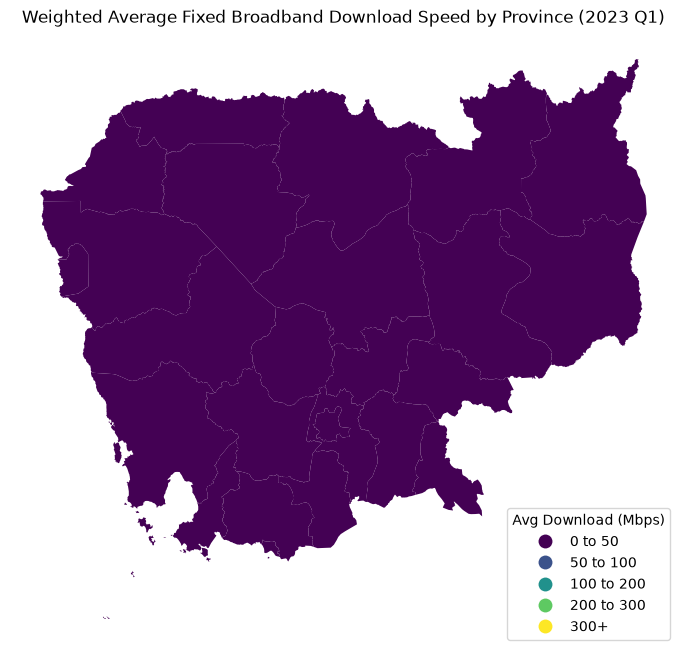

In [11]:
fig, ax = plt.subplots(1, figsize=(10, 8))
province_data.plot("group", ax=ax, legend=True, cmap="viridis", 
                   legend_kwds={'title': "Avg Download (Mbps)", 'loc': 'lower right'})

ax.set_title("Weighted Average Fixed Broadband Download Speed by Province (2023 Q1)")
ax.set_axis_off()

plt.savefig(f'../../outputs/ookla/cambodia/08_province_speed_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
import pandas as pd
import os

file_path = "../../data/ookla/raw"
files = sorted([f for f in os.listdir(file_path) if f.endswith('.parquet')])
print(f"{len(files)} files, reading first for inspection...")

# Read single file to inspect schema — avoid loading 3.7GB at once
df = pd.read_parquet(os.path.join(file_path, files[0]), engine='pyarrow')

23 files, reading first for inspection...


In [13]:
df.head() 

,quadkey,tile,tile_x,tile_y,avg_d_kbps,avg_u_kbps,avg_lat_ms,avg_lat_down_ms,avg_lat_up_ms,tests,devices
0,0022022300231020,"POLYGON((-178.4619140625 70.9847699889061, -17...",-178.4592,70.9839,87,204,578,3627.0,3312.0,1,1
1,0022133222312322,"POLYGON((-160.02685546875 70.6435894914449, -1...",-160.0241,70.6427,158237,9571,170,517.0,257.0,5,2
2,0022133222330012,"POLYGON((-160.037841796875 70.6399478155463, -...",-160.0351,70.6390,74693,28236,164,590.0,243.0,2,1
3,0022133222330023,"POLYGON((-160.043334960938 70.6363054807905, -...",-160.0406,70.6354,69368,7703,251,546.0,590.0,2,1
4,0022133222330030,"POLYGON((-160.037841796875 70.6381267305321, -...",-160.0351,70.6372,259,260,32,310.0,426.0,1,1


In [14]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 6336489 entries, 0 to 6336488
Data columns (total 11 columns):
 #   Column           Dtype  
---  ------           -----  
 0   quadkey          str    
 1   tile             str    
 2   tile_x           float64
 3   tile_y           float64
 4   avg_d_kbps       int64  
 5   avg_u_kbps       int64  
 6   avg_lat_ms       int64  
 7   avg_lat_down_ms  float64
 8   avg_lat_up_ms    float64
 9   tests            int64  
 10  devices          int64  
dtypes: float64(4), int64(5), str(2)
memory usage: 1.7 GB
None


## Province Reference Data

In [15]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

PROVINCE_REF_PATH = '../../data/reference/cambodia_reference.csv'

prov_ref = pd.read_csv(PROVINCE_REF_PATH)
prov_ref['gdp_per_capita_usd_2021'] = prov_ref['gdp_per_capita_thb_2021']  # already USD-equivalent in source data

print(f"Provinces loaded: {len(prov_ref)}")
print(f"Regions: {sorted(prov_ref['region'].unique())}")
print()
print(prov_ref[['province_en','region','pop_2024','density_per_km2','gdp_per_capita_thb_2021','internet_tier']].to_string(index=False))


Provinces loaded: 25
Regions: ['Capital', 'Center', 'East', 'North', 'Northeast', 'Northwest', 'South', 'Southeast', 'Southwest', 'West']

        province_en    region  pop_2024  density_per_km2  gdp_per_capita_thb_2021  internet_tier
    Bantey Meanchey Northwest    898484              135                199216.96              1
         Battambang Northwest   1132017               97                199216.96              2
       Kampong Cham      East   1062914              234                199216.96              4
    Kampong Chhnang    Center    604895              110                199216.96              1
       Kampong Speu Southwest    924175              132                199216.96              4
       Kampong Thom    Center    807254               58                199216.96              3
             Kampot Southwest    682987              140                199216.96              2
             Kandal    Center   1352198              425                199216.96    

### Population and GDP by Region — Summary

In [16]:
region_summary = (
    prov_ref.groupby('region')
    .agg(
        provinces=('province_en', 'count'),
        total_pop=('pop_2024', 'sum'),
        avg_density=('density_per_km2', 'mean'),
        avg_gdp_per_cap_thb=('gdp_per_capita_thb_2021', 'mean'),
        avg_gdp_per_cap_usd=('gdp_per_capita_usd_2021', 'mean'),
    )
    .sort_values('avg_gdp_per_cap_thb', ascending=False)
    .round(0)
)

region_summary['total_pop_M'] = (region_summary['total_pop'] / 1e6).round(2)
print(region_summary[['provinces','total_pop_M','avg_density','avg_gdp_per_cap_thb','avg_gdp_per_cap_usd']].to_string())


           provinces  total_pop_M  avg_density  avg_gdp_per_cap_thb  avg_gdp_per_cap_usd
region                                                                                  
Capital            1         2.35       3465.0             199217.0             199217.0
Center             3         2.76        198.0             199217.0             199217.0
East               5         3.77        143.0             199217.0             199217.0
North              2         0.52         30.0             199217.0             199217.0
Northeast          2         0.41         19.0             199217.0             199217.0
Northwest          3         3.13        113.0             199217.0             199217.0
South              3         1.38        191.0             199217.0             199217.0
Southeast          1         0.61        207.0             199217.0             199217.0
Southwest          3         1.75         95.0             199217.0             199217.0
West               2 

### GDP per Capita vs Population Density — by Region

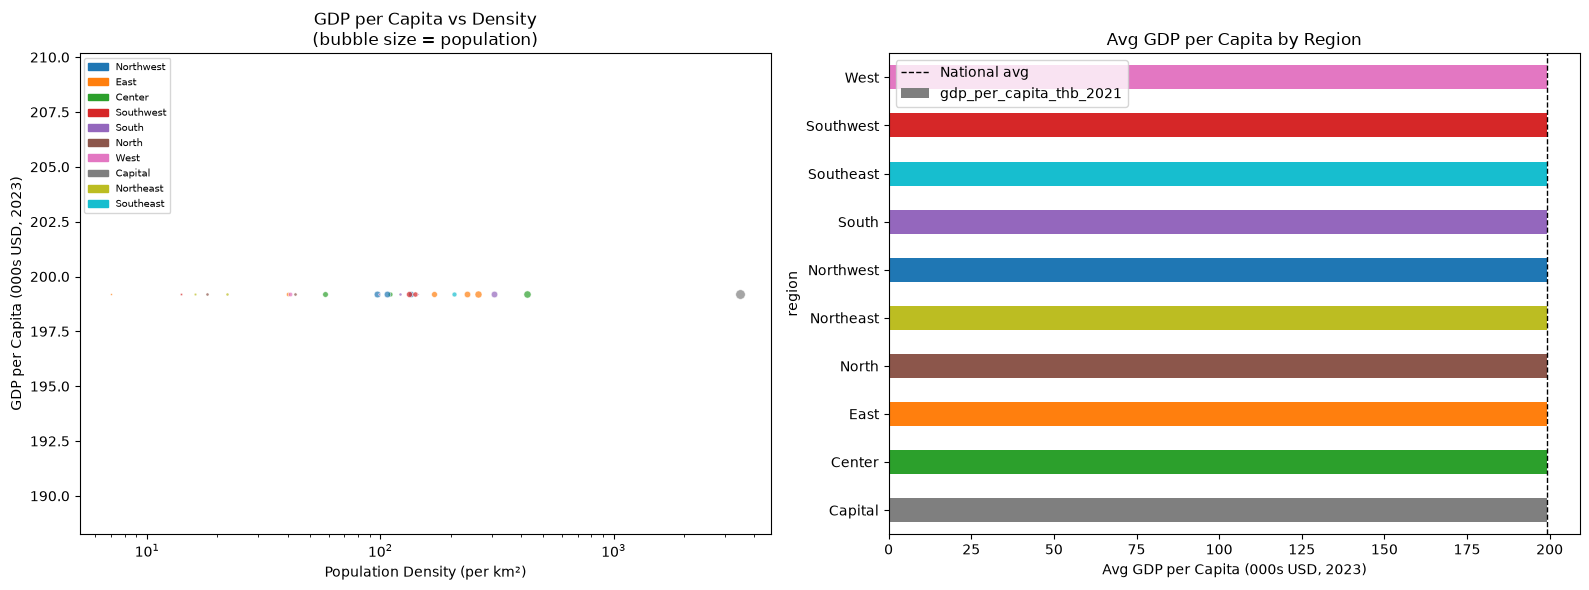

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_colors = {
    'Northwest': '#1f77b4',
    'East': '#ff7f0e',
    'Center': '#2ca02c',
    'Southwest': '#d62728',
    'South': '#9467bd',
    'North': '#8c564b',
    'West': '#e377c2',
    'Capital': '#7f7f7f',
    'Northeast': '#bcbd22',
    'Southeast': '#17becf',
}

for _, row in prov_ref.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000,
                    color=c, alpha=0.7, s=row['pop_2024'] / 50000, edgecolors='white', linewidth=0.5)
    if row['gdp_per_capita_thb_2021'] > prov_ref['gdp_per_capita_thb_2021'].quantile(0.85):
        axes[0].annotate(row['province_en'], (row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000),
                         fontsize=6.5, ha='left', va='bottom', alpha=0.9)

axes[0].set_xlabel('Population Density (per km²)')
axes[0].set_ylabel('GDP per Capita (000s USD, 2023)')
axes[0].set_title('GDP per Capita vs Density\n(bubble size = population)')
axes[0].set_xscale('log')

# Bar chart: avg GDP per region
r_gdp = prov_ref.groupby('region')['gdp_per_capita_thb_2021'].mean().sort_values(ascending=True) / 1000
colors = [region_colors.get(r, 'gray') for r in r_gdp.index]
r_gdp.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('Avg GDP per Capita (000s USD, 2023)')
axes[1].set_title('Avg GDP per Capita by Region')
axes[1].axvline(prov_ref['gdp_per_capita_thb_2021'].mean() / 1000, color='black', linestyle='--', linewidth=1, label='National avg')
axes[1].legend()

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
axes[0].legend(handles=patches, fontsize=7, loc='upper left')

plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/09_gdp_vs_density.png', dpi=150, bbox_inches='tight')
plt.show()


### Internet Tier Distribution — Assumptions Map

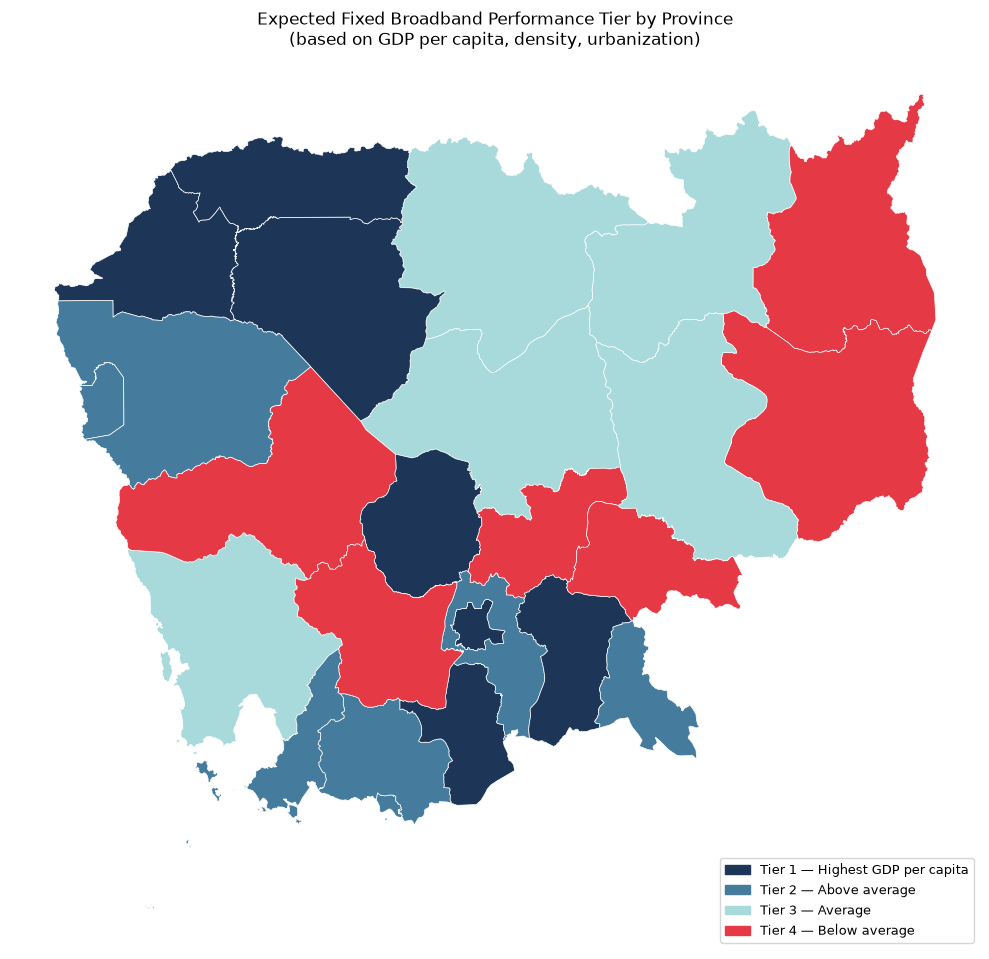

In [18]:
THAILAND_GEOJSON = '../../data/geo/cambodia_provinces.geojson'
thailand_gdf = gpd.read_file(THAILAND_GEOJSON).to_crs(4326)

# Merge — GeoJSON uses 'name' column
tier_map = prov_ref[['province_en','internet_tier','gdp_per_capita_thb_2021','region']].copy()

# Manual name alignment between GeoJSON and our CSV
name_map = {}  # no manual alignment needed: geojson 'name' already matches reference csv

geo_with_tier = thailand_gdf.merge(
    tier_map.rename(columns={'province_en': 'name'}),
    on='name', how='left'
)

missing = geo_with_tier[geo_with_tier['internet_tier'].isna()]['name'].tolist()
if missing:
    print("Unmatched provinces (need manual fix):", missing)

tier_colors = {1: '#1d3557', 2: '#457b9d', 3: '#a8dadc', 4: '#e63946'}
geo_with_tier['tier_color'] = geo_with_tier['internet_tier'].map(tier_colors)

fig, ax = plt.subplots(1, figsize=(10, 12))
geo_with_tier.plot(color=geo_with_tier['tier_color'].fillna('lightgray'), ax=ax, edgecolor='white', linewidth=0.5)

patches = [
    mpatches.Patch(color='#1d3557', label='Tier 1 — Highest GDP per capita'),
    mpatches.Patch(color='#457b9d', label='Tier 2 — Above average'),
    mpatches.Patch(color='#a8dadc', label='Tier 3 — Average'),
    mpatches.Patch(color='#e63946', label='Tier 4 — Below average'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_title('Expected Fixed Broadband Performance Tier by Province\n(based on GDP per capita, density, urbanization)', fontsize=12)
ax.set_axis_off()
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/10_tier_speed_expected.png', dpi=150, bbox_inches='tight')
plt.show()


### Top & Bottom Provinces by GDP per Capita — with Internet Tier

In [19]:
top10 = prov_ref.nlargest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]
bot10 = prov_ref.nsmallest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]

print("=== TOP 10 by GDP per Capita ===")
print(top10.to_string(index=False))
print()
print("=== BOTTOM 10 by GDP per Capita ===")
print(bot10.to_string(index=False))


=== TOP 10 by GDP per Capita ===
    province_en    region  pop_2024  gdp_per_capita_thb_2021  internet_tier
Bantey Meanchey Northwest    898484                199216.96              1
     Battambang Northwest   1132017                199216.96              2
   Kampong Cham      East   1062914                199216.96              4
Kampong Chhnang    Center    604895                199216.96              1
   Kampong Speu Southwest    924175                199216.96              4
   Kampong Thom    Center    807254                199216.96              3
         Kampot Southwest    682987                199216.96              2
         Kandal    Center   1352198                199216.96              2
            Kep     South     48772                199216.96              2
       Koh Kong Southwest    140962                199216.96              3

=== BOTTOM 10 by GDP per Capita ===
    province_en    region  pop_2024  gdp_per_capita_thb_2021  internet_tier
Bantey Meanchey No

---
# Part 1 — Fixed Broadband


## Full EDA — Ookla Fixed Broadband, Cambodia (2023 Q1 – 2025 Q4)

### 1. Load & Aggregate All Quarters

In [20]:
import glob, os, warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

DATASET_DIR = '../../data/ookla/raw'
GEOJSON     = '../../data/geo/cambodia_provinces.geojson'
PROV_REF    = '../../data/reference/cambodia_reference.csv'

# Ookla S3 filename convention: {YEAR}-{MM}-01_performance_fixed_tiles.parquet
# Q1=January(01), Q2=April(04), Q3=July(07), Q4=October(10)
Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

thailand_gdf = gpd.read_file(GEOJSON).to_crs(4326)
state_bounds = thailand_gdf.total_bounds
bbox_filters = [
    ('tile_y', '<=', state_bounds[3]), ('tile_y', '>=', state_bounds[1]),
    ('tile_x', '<=', state_bounds[2]), ('tile_x', '>=', state_bounds[0]),
]

COLS = ['tile_x','tile_y','tests','devices','avg_d_kbps','avg_u_kbps','avg_lat_ms']

records = []
files = sorted(glob.glob(os.path.join(DATASET_DIR, '*fixed_tiles*.parquet')))

for fp in files:
    fname   = os.path.basename(fp)
    year    = int(fname[:4])
    quarter = int(fname[6])
    month   = Q_TO_MONTH[quarter]
    # period_start mirrors Ookla's original filename date (first day of the quarter)
    period_start = pd.Timestamp(year=year, month=month, day=1)
    label   = f"{year}-Q{quarter}"

    raw = pd.read_parquet(fp, columns=COLS, filters=bbox_filters)

    tiles_gdf = gpd.GeoDataFrame(
        raw,
        geometry=gpd.points_from_xy(raw.tile_x, raw.tile_y),
        crs='EPSG:4326'
    ).drop(columns=['tile_x','tile_y'])

    joined = gpd.sjoin(tiles_gdf, thailand_gdf[['name','geometry']], how='inner', predicate='intersects')

    agg = (
        joined.groupby('name')
        .apply(lambda g: pd.Series({
            'avg_d_kbps_wt': np.average(g['avg_d_kbps'], weights=g['tests']),
            'avg_u_kbps_wt': np.average(g['avg_u_kbps'], weights=g['tests']),
            'avg_lat_ms_wt': np.average(g['avg_lat_ms'], weights=g['tests']),
            'total_tests'  : g['tests'].sum(),
            'total_devices': g['devices'].sum(),
            'n_tiles'      : len(g),
        }), include_groups=False)
        .reset_index()
    )
    agg['year']         = year
    agg['quarter']      = quarter
    agg['month']        = month
    agg['period_start'] = period_start   # datetime: 2023-01-01, 2023-04-01, ...
    agg['label']        = label
    records.append(agg)
    print(f"  {label} ({period_start.date()}): {len(raw):>8,} raw tiles → {len(agg)} provinces")

master = pd.concat(records, ignore_index=True)
master['avg_d_mbps'] = master['avg_d_kbps_wt'] / 1000
master['avg_u_mbps'] = master['avg_u_kbps_wt'] / 1000
master.drop(columns=['avg_d_kbps_wt','avg_u_kbps_wt'], inplace=True)

# Merge province reference
prov_ref = pd.read_csv(PROV_REF)
prov_ref['gdp_per_capita_usd'] = prov_ref['gdp_per_capita_thb_2021']  # already USD-equivalent in source data
master = master.merge(prov_ref.rename(columns={'province_en':'name'}), on='name', how='left')

print(f"\nMaster shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} → {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()}")
print(f"\nperiod_start unique values (matches Ookla filename dates):")
for d in sorted(master['period_start'].unique()):
    print(f"  {pd.Timestamp(d).date()}")


  2023-Q1 (2023-01-01):   42,148 raw tiles → 25 provinces


  2023-Q2 (2023-04-01):   41,069 raw tiles → 25 provinces


  2023-Q3 (2023-07-01):   43,257 raw tiles → 25 provinces


  2023-Q4 (2023-10-01):   44,679 raw tiles → 25 provinces


  2024-Q1 (2024-01-01):   46,723 raw tiles → 25 provinces


...

  2024-Q3 (2024-07-01):   46,778 raw tiles → 25 provinces


  2024-Q4 (2024-10-01):   48,979 raw tiles → 25 provinces


  2025-Q1 (2025-01-01):   47,294 raw tiles → 25 provinces


  2025-Q2 (2025-04-01):   51,457 raw tiles → 25 provinces


  2025-Q4 (2025-10-01):   53,763 raw tiles → 25 provinces

Master shape: (275, 22)
Date range: 2023-01-01 → 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q4']
Provinces:  25

period_start unique values (matches Ookla filename dates):
  2023-01-01
  2023-04-01
  2023-07-01
  2023-10-01
  2024-01-01
  2024-04-01
  2024-07-01
  2024-10-01
  2025-01-01
  2025-04-01
  2025-10-01


In [21]:
# Quality flag per province × quarter
# Ookla: >= 100 tests AND >= 5 tiles → sufficient spatial + sample coverage
master['is_reliable'] = (
    (master['total_tests'] >= 100) &
    (master['n_tiles'] >= 5)
)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")

Reliable province-quarters per label:
label
2023-Q1    25
2023-Q2    25
2023-Q3    25
2023-Q4    25
2024-Q1    25
2024-Q2    25
2024-Q3    25
2024-Q4    25
2025-Q1    25
2025-Q2    25
2025-Q4    25

Overall reliable: 275 / 275 (100.0%)


### 2. Data Quality — Coverage per Province

In [22]:
expected_n = len(prov_ref)
expected = expected_n * master['label'].nunique()
print(f"Expected rows: {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

# Provinces with zero coverage in any quarter
all_provinces = set(thailand_gdf['name'])
all_labels    = set(master['label'].unique())
coverage_pivot = master.pivot_table(index='name', columns='label', values='total_tests', aggfunc='sum')

missing_cells = [(p, q) for p in all_provinces for q in all_labels
                 if p not in coverage_pivot.index or pd.isna(coverage_pivot.loc[p, q])]
if missing_cells:
    print(f"\nMissing province-quarter combos ({len(missing_cells)}):")
    for p, q in missing_cells:
        print(f"  {p} — {q}")
else:
    print(f"\nAll {expected} provinces covered in every quarter.")

# Low-test provinces (< 100 tests in any quarter)
low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
if len(low_test):
    print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} cases:")
    print(low_test.to_string(index=False))
else:
    print("\nNo quarters with < 100 tests.")


Expected rows: 275 | Actual: 275 | Missing: 0

All 275 provinces covered in every quarter.

No quarters with < 100 tests.


In [23]:
# Drop unreliable province-quarters before any stats/plots use master downstream
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")

Filtered to reliable province-quarters: 275 rows kept


### 3. Speed Distribution — All Provinces, All Quarters

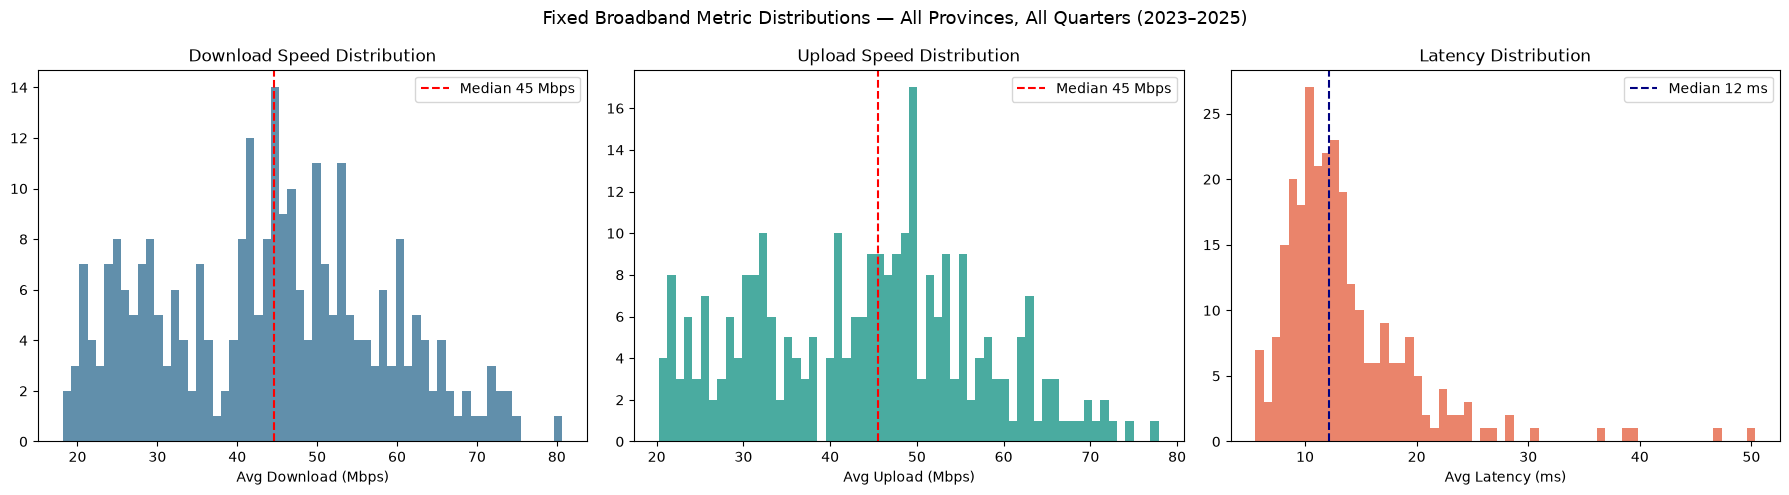

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count      275.00      275.00         275.00       275.00
mean        43.98       44.04          13.56      7903.20
std         14.10       13.10           6.05     19964.38
min         18.15       20.28           5.56       272.00
25%         32.36       32.52           9.91      1125.50
50%         44.64       45.50          12.13      2074.00
75%         53.38       52.89          15.43      5988.50
max         80.68       77.87          50.32    121078.00


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

plt.suptitle('Fixed Broadband Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))


### 4. Province Ranking — Mean Download Speed (All Quarters)

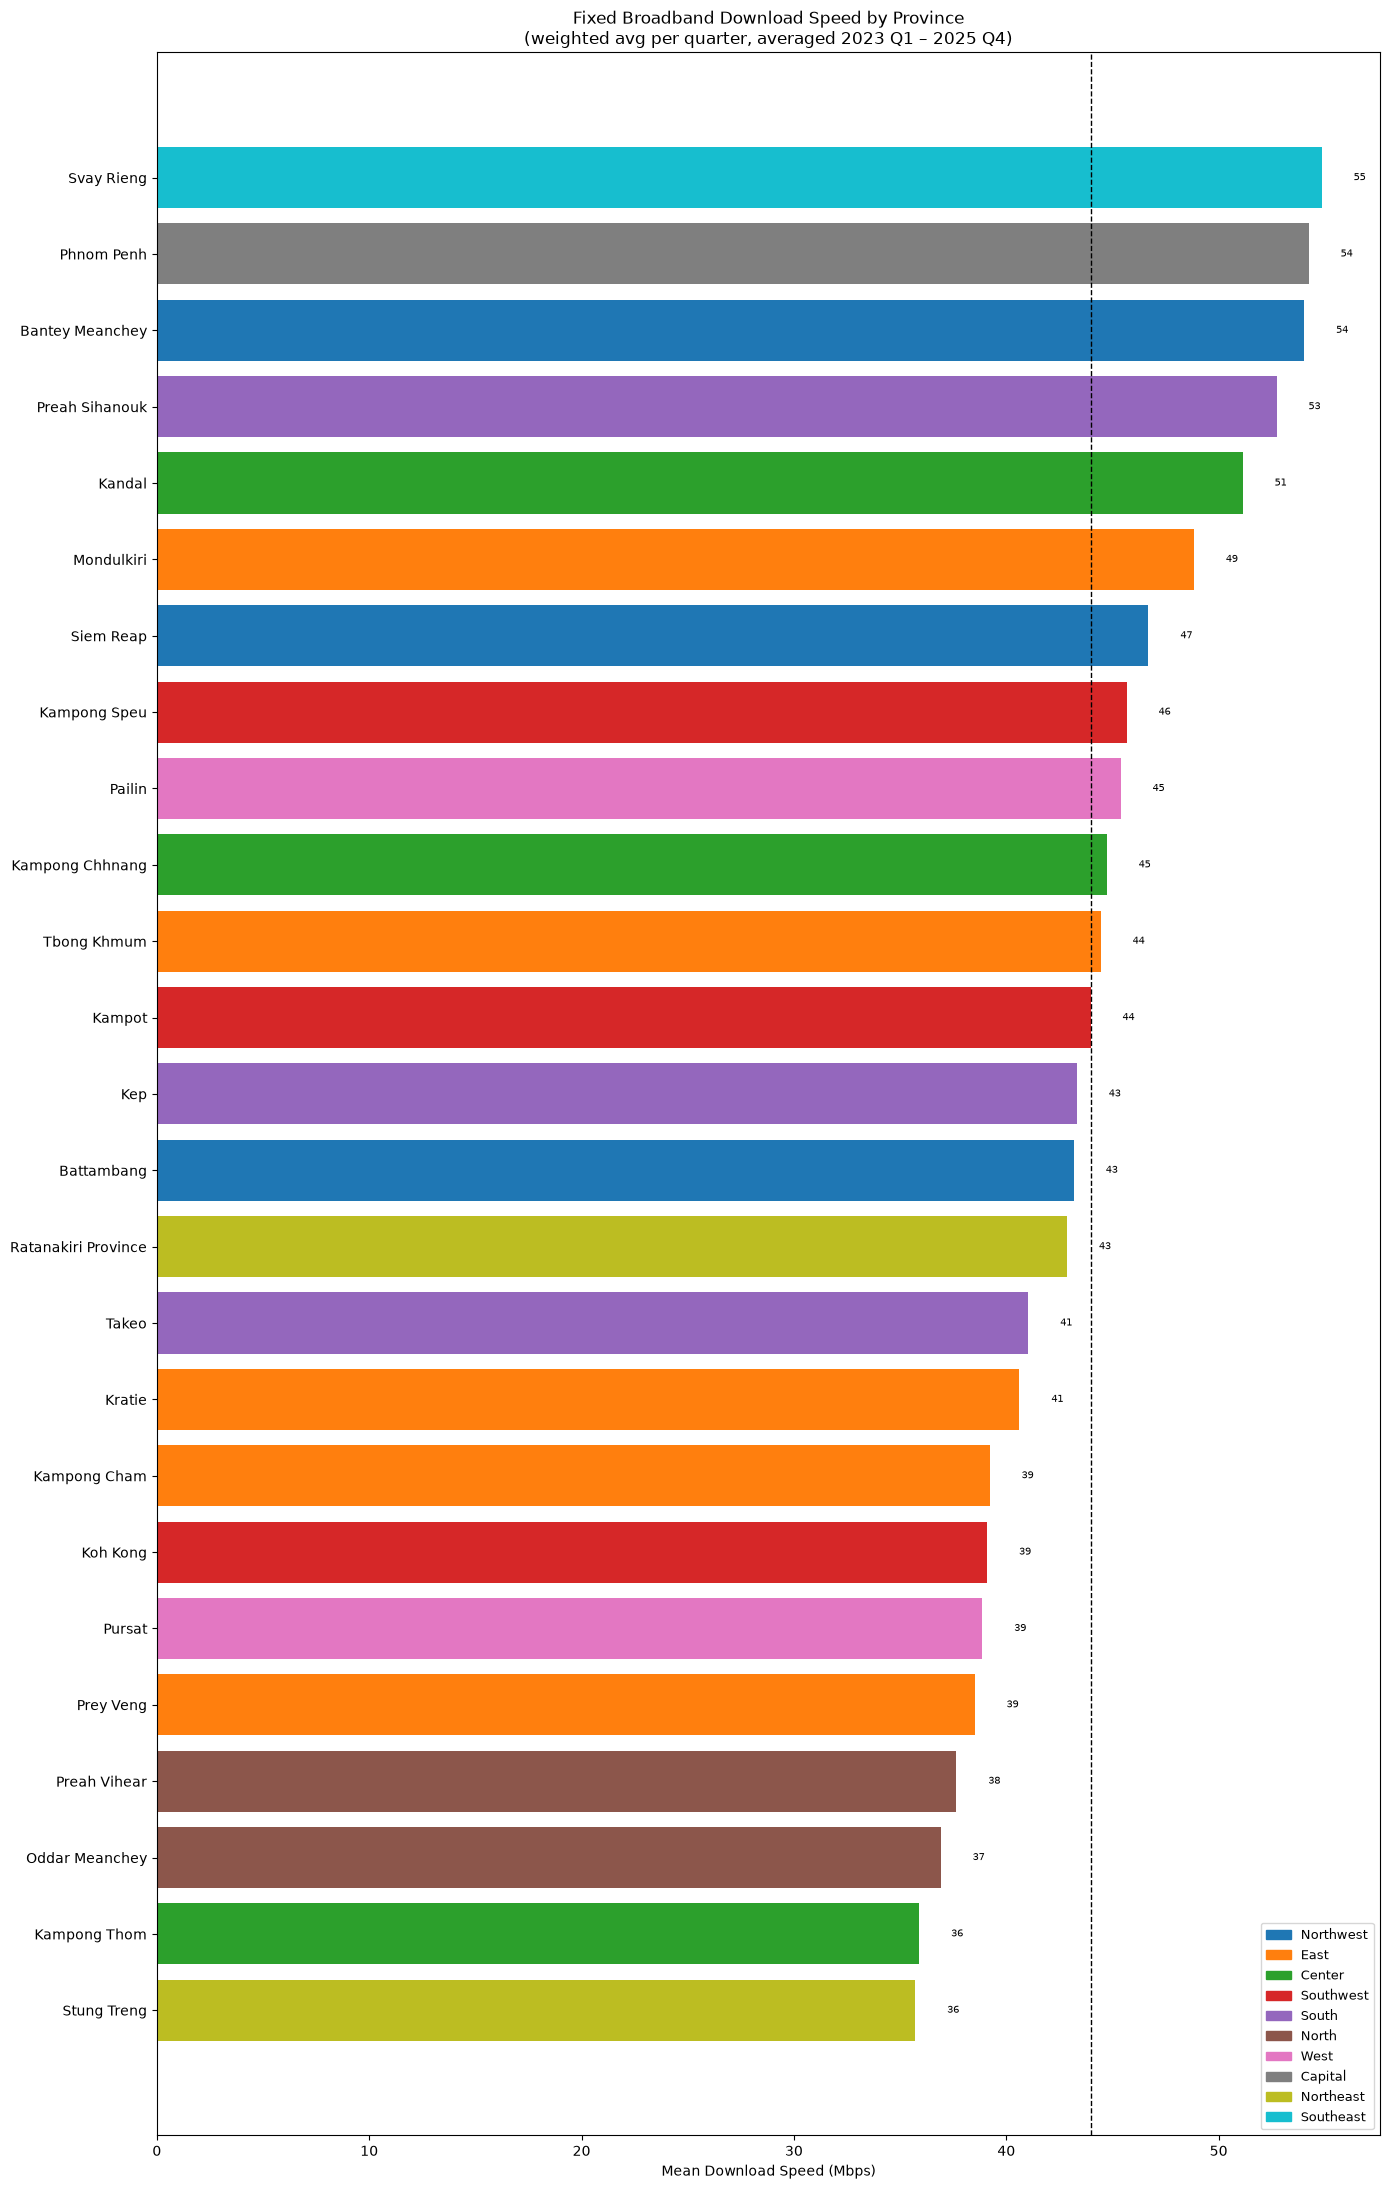

In [25]:
region_colors = {
    'Northwest': '#1f77b4',
    'East': '#ff7f0e',
    'Center': '#2ca02c',
    'Southwest': '#d62728',
    'South': '#9467bd',
    'North': '#8c564b',
    'West': '#e377c2',
    'Capital': '#7f7f7f',
    'Northeast': '#bcbd22',
    'Southeast': '#17becf',
}

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_mean['mean_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('Mean Download Speed (Mbps)')
ax.set_title('Fixed Broadband Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.5 Province Ranking — Median Download Speed (All Quarters)

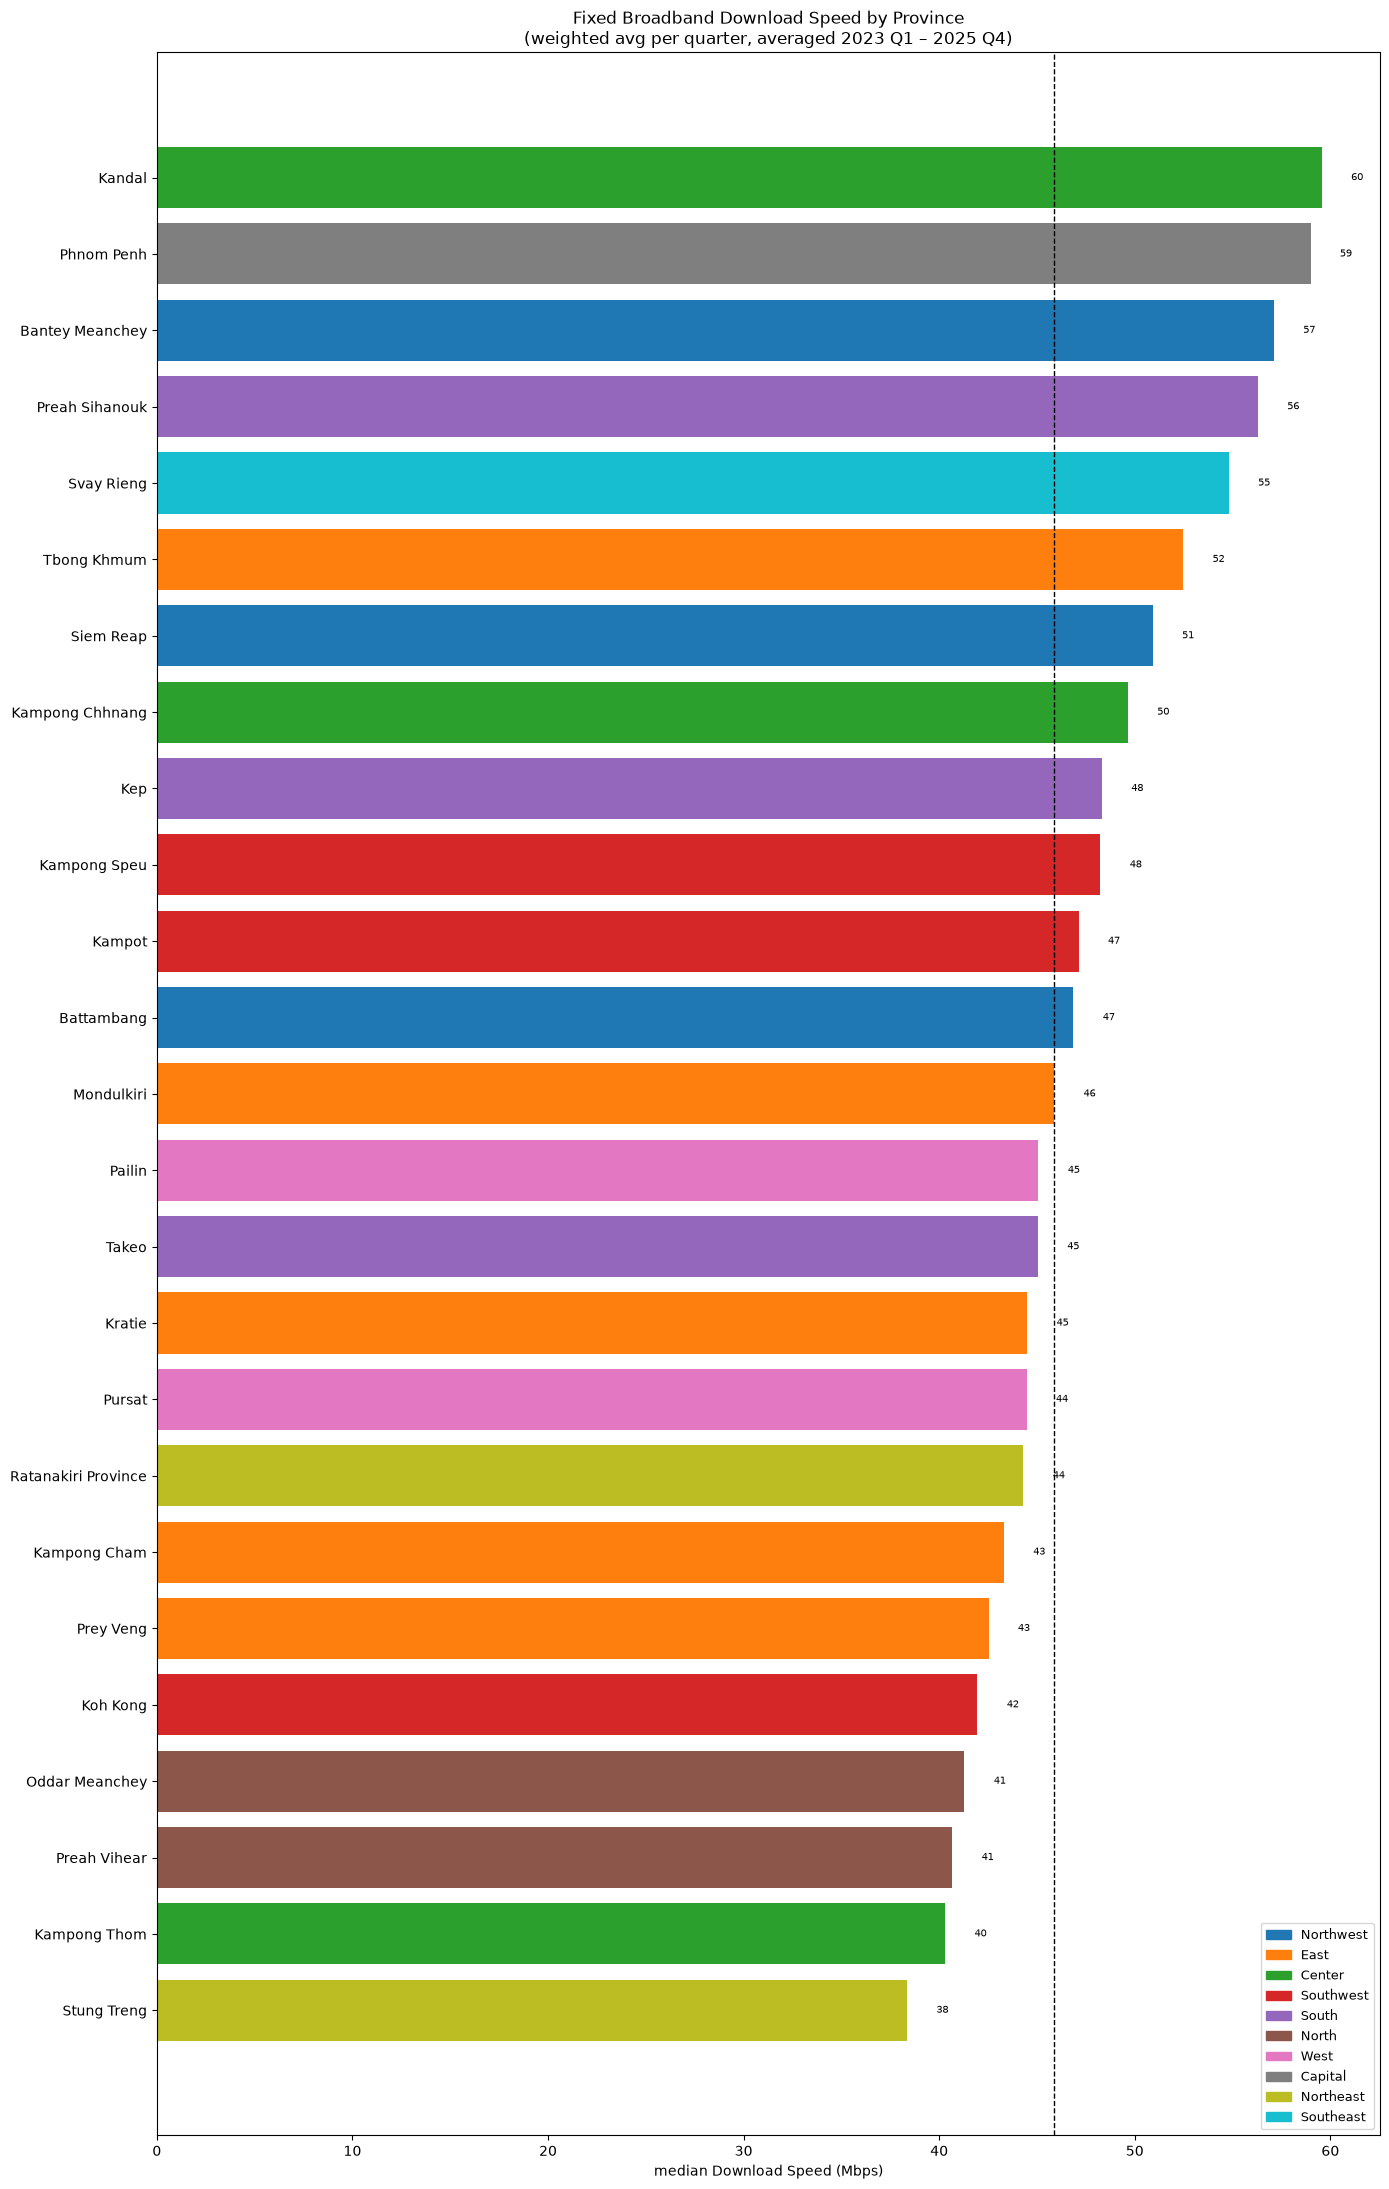

In [26]:
region_colors = {
    'Northwest': '#1f77b4',
    'East': '#ff7f0e',
    'Center': '#2ca02c',
    'Southwest': '#d62728',
    'South': '#9467bd',
    'North': '#8c564b',
    'West': '#e377c2',
    'Capital': '#7f7f7f',
    'Northeast': '#bcbd22',
    'Southeast': '#17becf',
}

prov_median = (
    master.groupby(['name','region'])
    .agg(
        median_dl=('avg_d_mbps','median'),
        median_ul=('avg_u_mbps','median'),
        median_lat=('avg_lat_ms_wt','median'),
        median_tests=('total_tests','median'),
    )
    .reset_index()
    .sort_values('median_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_median['region']]
bars = ax.barh(prov_median['name'], prov_median['median_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_median['median_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_median['median_dl'].median(), color='black', ls='--', lw=1, label=f'National median {prov_median["median_dl"].median():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('median Download Speed (Mbps)')
ax.set_title('Fixed Broadband Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/12_province_ranking_median.png', dpi=150, bbox_inches='tight')
plt.show()


### 5. Time Series — Download Speed Heatmap (Province × Quarter)

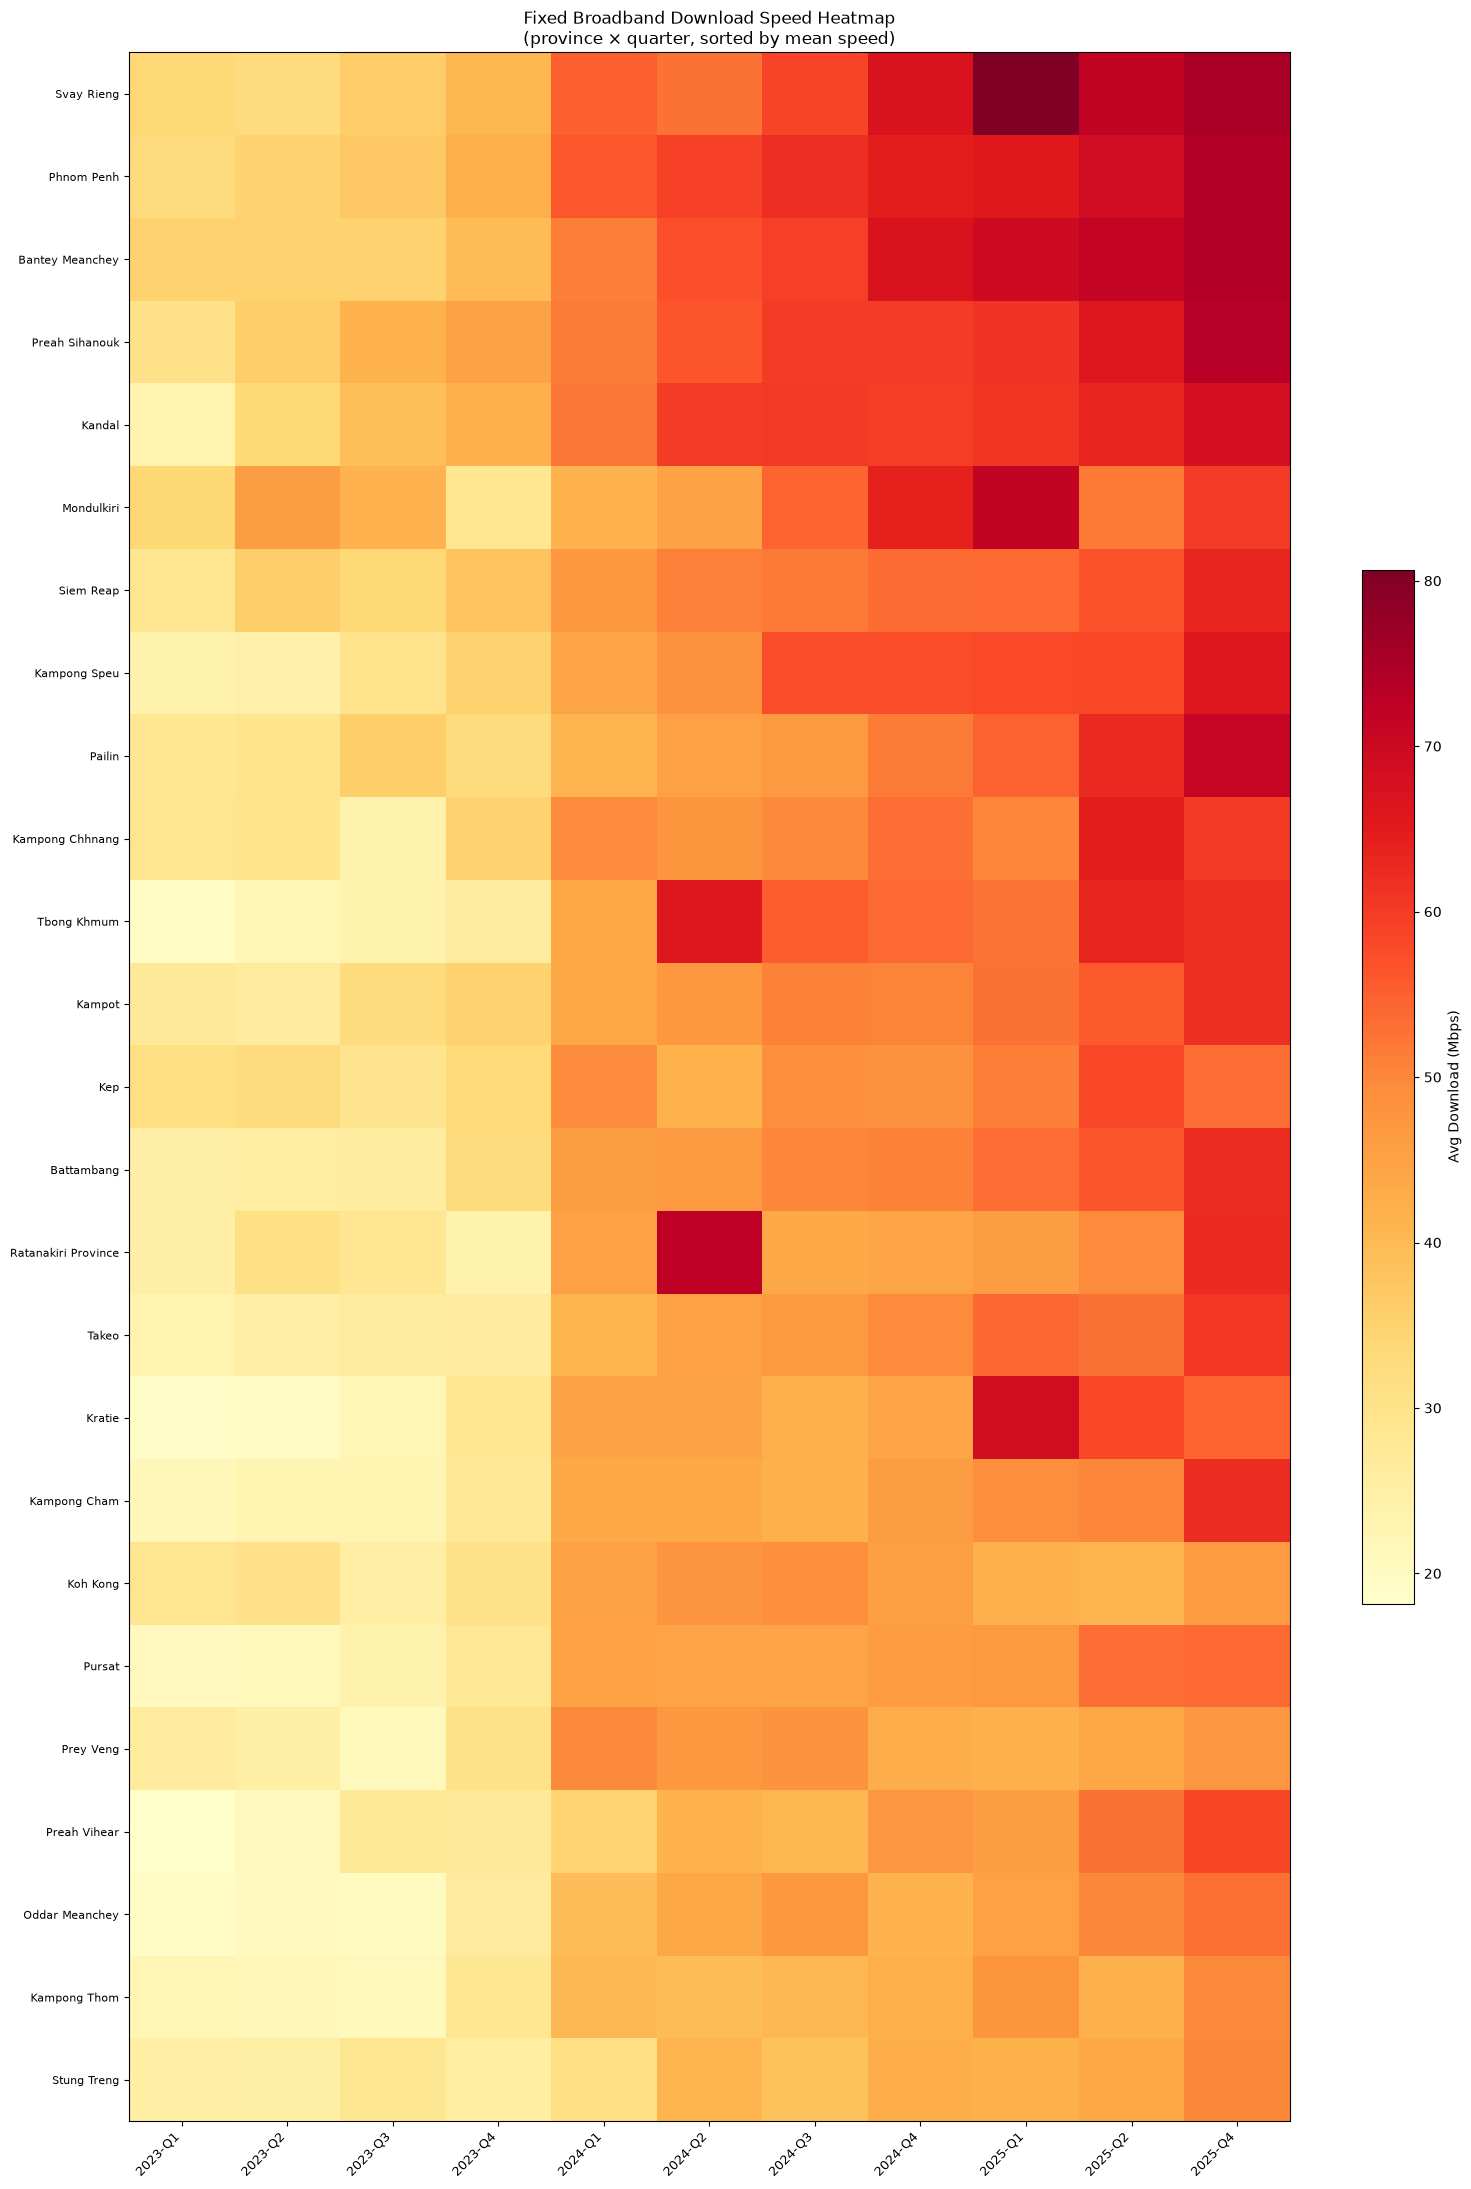

In [27]:
pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
# Format column labels as quarter strings for display
pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
# Sort by mean download speed
pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

fig, ax = plt.subplots(figsize=(16, 22))
im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)

ax.set_xticks(range(len(pivot_dl.columns)))
ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_dl.index)))
ax.set_yticklabels(pivot_dl.index, fontsize=8)
ax.set_title('Fixed Broadband Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()


### 6. Regional Comparison — Download, Upload, Latency

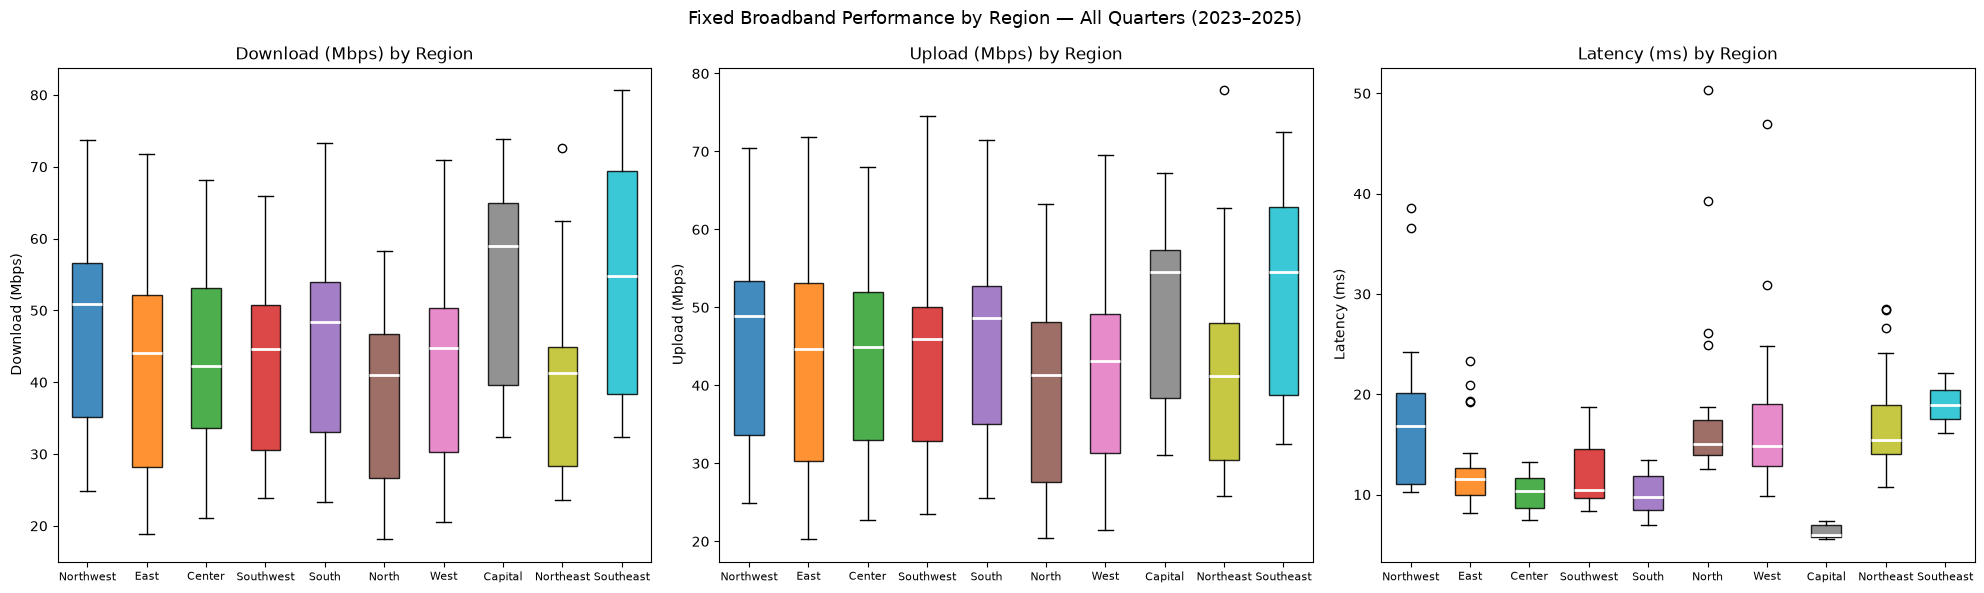

In [28]:
region_order = ['Northwest', 'East', 'Center', 'Southwest', 'South', 'North', 'West', 'Capital', 'Northeast', 'Southeast']
region_data  = [master[master['region']==r]['avg_d_mbps'].dropna().values for r in region_order]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric, label, color_key in [
    (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
    (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
    (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
]:
    data = [master[master['region']==r][metric].dropna().values for r in region_order]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2))
    for patch, region in zip(bp['boxes'], region_order):
        patch.set_facecolor(region_colors[region])
        patch.set_alpha(0.85)
    ax.set_xticklabels([r.replace(' & ',' &\n') for r in region_order], fontsize=8)
    ax.set_ylabel(label)
    ax.set_title(f'{label} by Region')

plt.suptitle('Fixed Broadband Performance by Region — All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

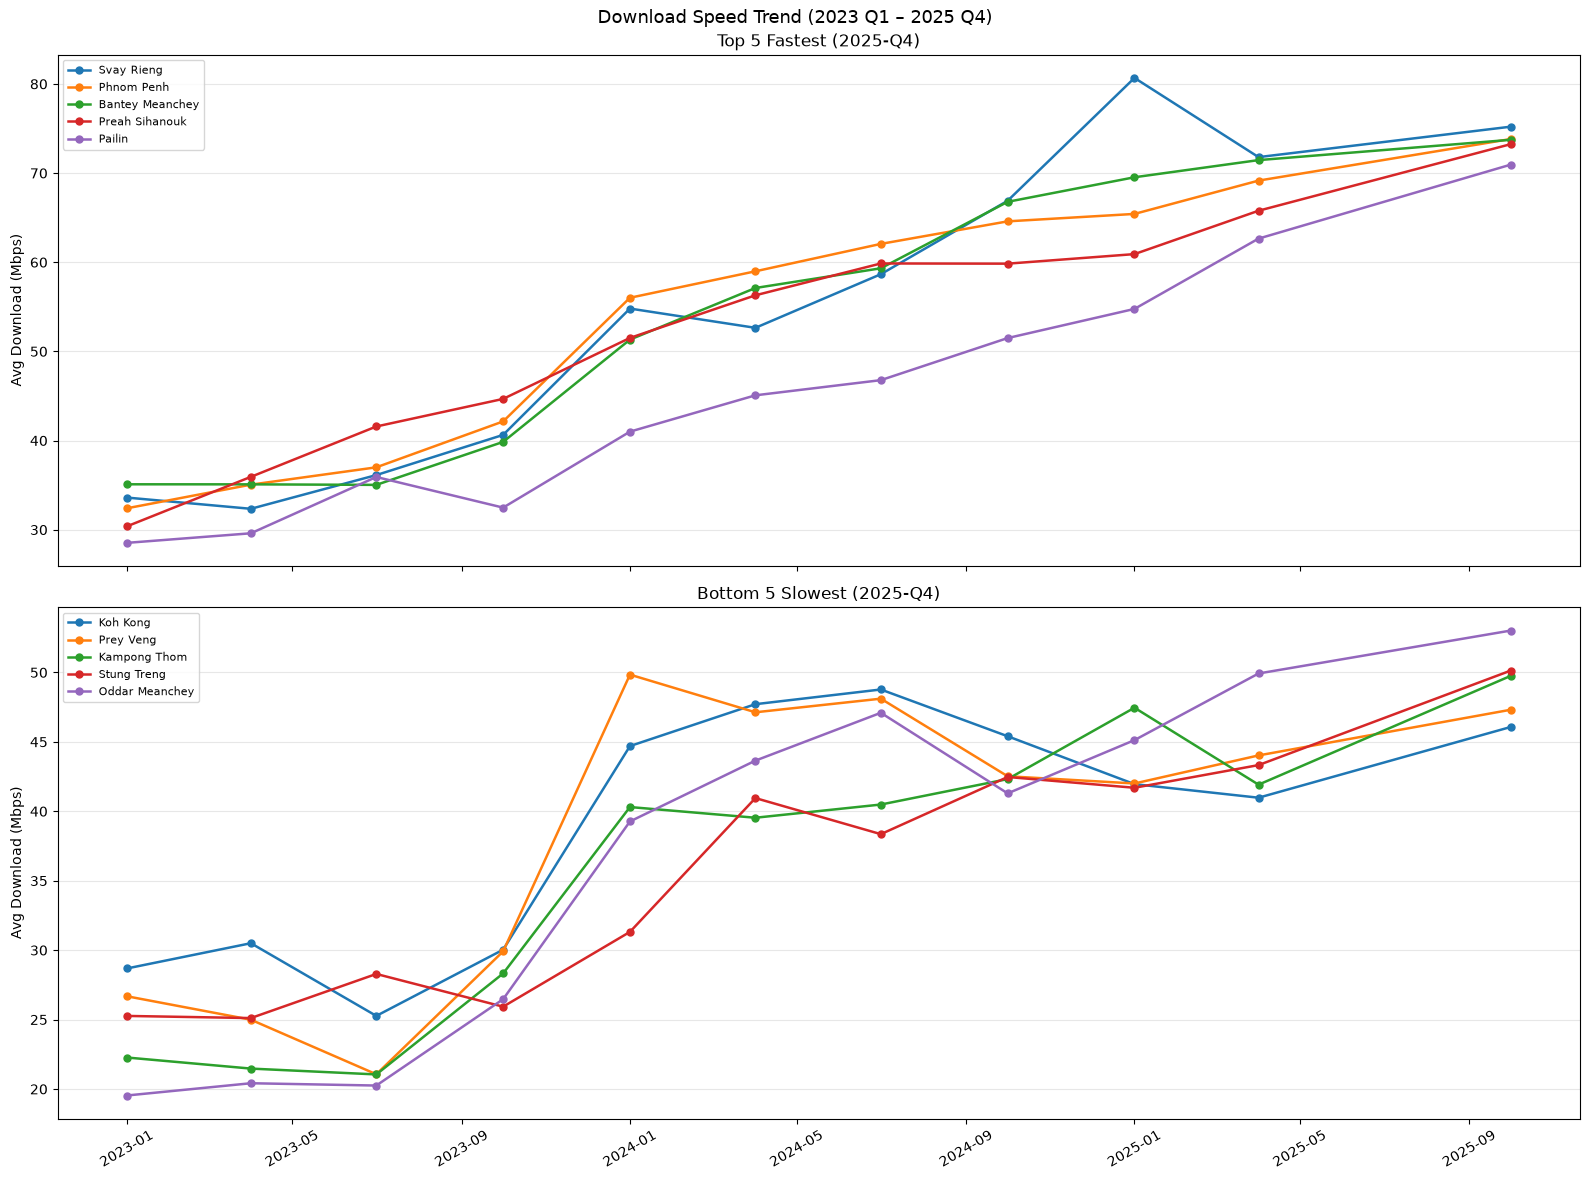

In [29]:
latest_q = master['label'].max()
latest = master[master['label'] == latest_q]
top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

quarter_order = sorted(master['label'].unique())
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

groups = [
    (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
    (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
]

for ax, (title, provinces, base_color) in zip(axes, groups):
    for i, prov in enumerate(provinces):
        df_p = master[master['name']==prov].sort_values('label')
        if df_p.empty: continue
        ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5,
                label=prov, linewidth=1.8)
    ax.set_ylabel('Avg Download (Mbps)')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/15_time_series.png', dpi=150, bbox_inches='tight')
plt.show()


### 8. GDP per Capita vs Download Speed — Does Money = Speed?

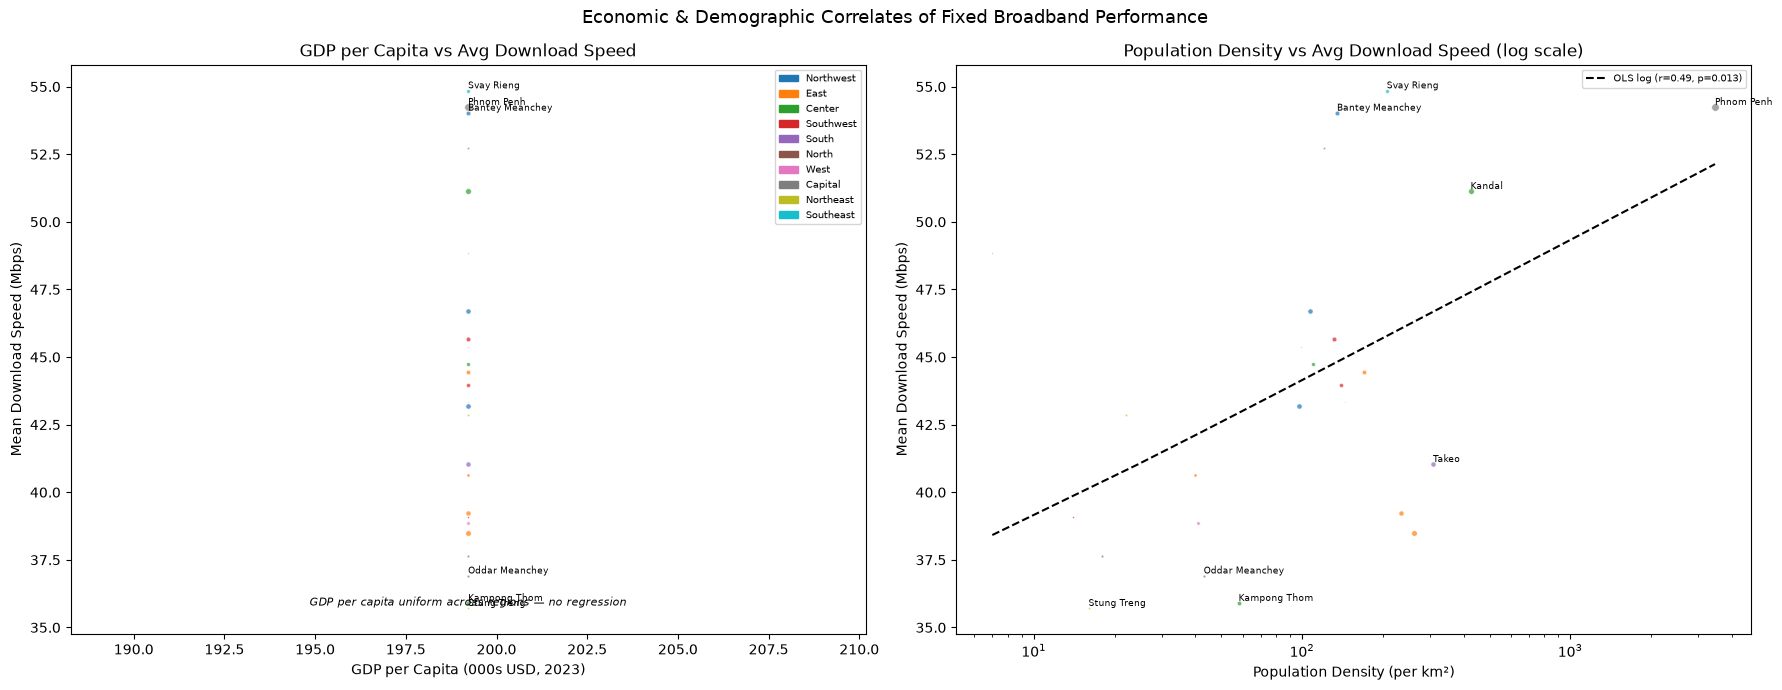

Pearson r (GDP vs download):     nan  p=nan
Pearson r (log density vs download): 0.490  p=0.0129


In [30]:
corr_df = prov_mean.merge(
    prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
    on='name', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter: GDP vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    # Label outliers
    if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

# OLS trendline
x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
y = corr_df.loc[x.index,'mean_dl']
if x.nunique() > 1:
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 100)
    axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
    ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
else:
    r, p = float('nan'), float('nan')
    axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
    ols_handle = []
axes[0].set_xlabel('GDP per Capita (000s USD, 2023)')
axes[0].set_ylabel('Mean Download Speed (Mbps)')
axes[0].set_title('GDP per Capita vs Avg Download Speed')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches+ols_handle, fontsize=7)

# Scatter: density vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'],'gray')
    axes[1].scatter(row['density_per_km2'], row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

x2 = corr_df['density_per_km2'].dropna()
y2 = corr_df.loc[x2.index,'mean_dl']
s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
xline2 = np.linspace(x2.min(), x2.max(), 200)
axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
axes[1].set_xlabel('Population Density (per km²)')
axes[1].set_xscale('log')
axes[1].set_ylabel('Mean Download Speed (Mbps)')
axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
axes[1].legend(fontsize=7)

plt.suptitle('Economic & Demographic Correlates of Fixed Broadband Performance', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")


### 8.5 Multivariate Model — GDP + Density + Tier + Region Together


In [31]:
import statsmodels.formula.api as smf

model_df = corr_df.dropna(subset=['mean_dl', 'gdp_per_capita_thb_2021', 'density_per_km2', 'region', 'internet_tier']).copy()
model_df['log_gdp'] = np.log(model_df['gdp_per_capita_thb_2021'])
model_df['log_density'] = np.log1p(model_df['density_per_km2'])

terms = []
if model_df['log_gdp'].nunique() > 1:
    terms.append('log_gdp')
if model_df['log_density'].nunique() > 1:
    terms.append('log_density')
if model_df['internet_tier'].nunique() > 1:
    terms.append("C(internet_tier)")
if model_df['region'].nunique() > 1:
    terms.append('C(region)')

formula = 'mean_dl ~ ' + ' + '.join(terms)
mv_model = smf.ols(formula, data=model_df).fit()
print(mv_model.summary())

print(f"\nMultivariate R\u00b2 = {mv_model.rsquared:.3f}  (bivariate GDP-only r\u00b2 = {r**2:.3f})")
print(f"Adjusted R\u00b2 = {mv_model.rsquared_adj:.3f}")


                            OLS Regression Results                            
Dep. Variable:                mean_dl   R-squared:                       0.690
Model:                            OLS   Adj. R-squared:                  0.323
Method:                 Least Squares   F-statistic:                     1.880
Date:                Mon, 20 Jul 2026   Prob (F-statistic):              0.151
Time:                        18:03:48   Log-Likelihood:                -64.742
No. Observations:                  25   AIC:                             157.5
Df Residuals:                      11   BIC:                             174.5
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 66

NDT per tile , facebook , spilt , 

### 9. Upload/Download Ratio — Symmetry Check

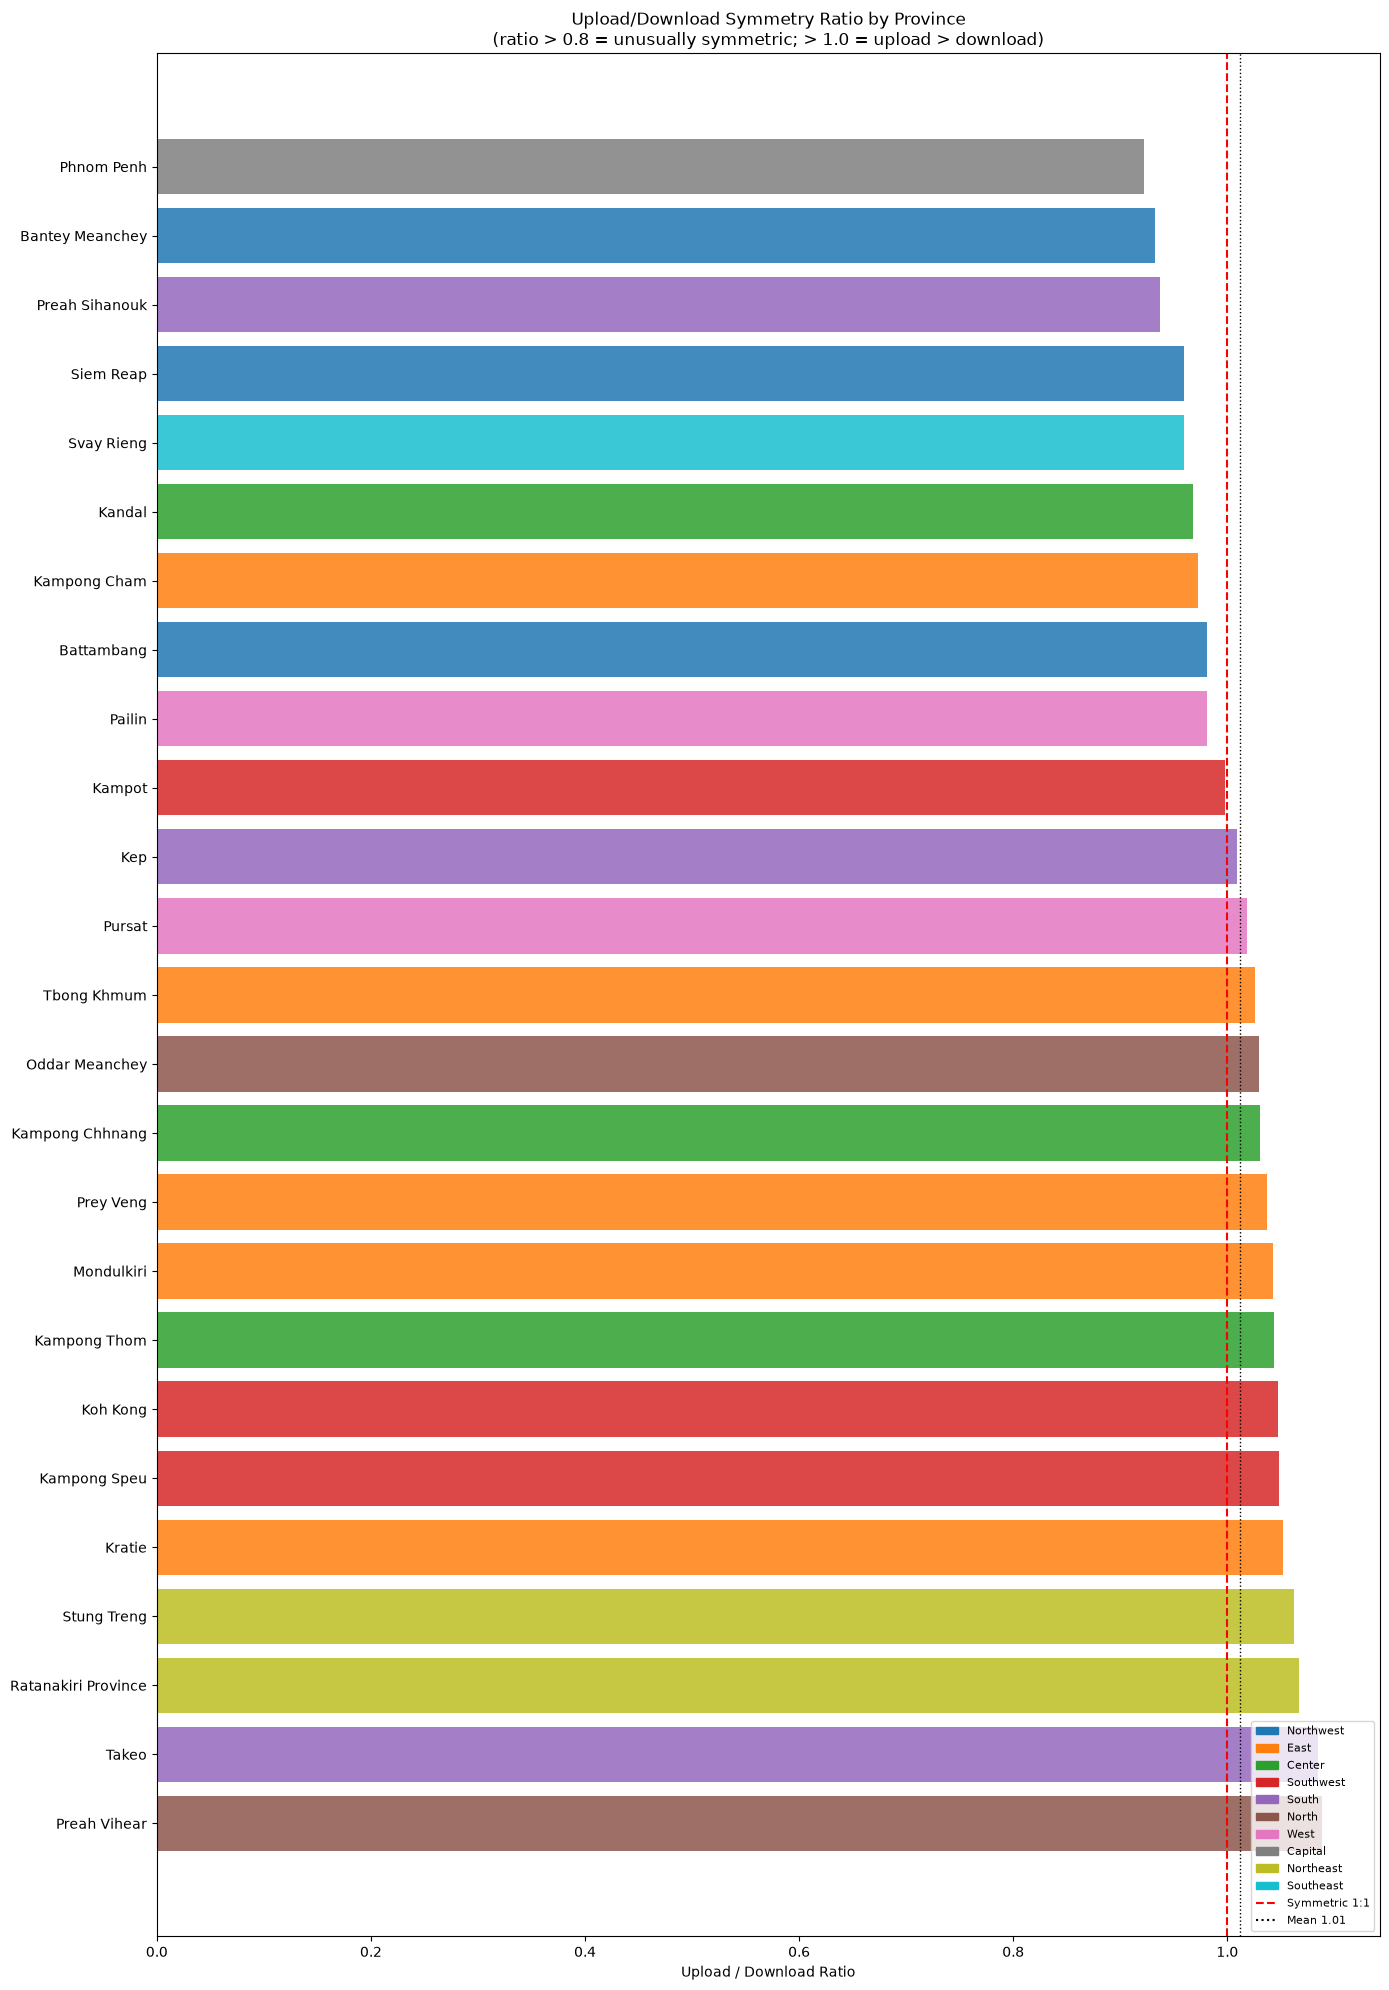

Provinces with UL/DL ratio > 0.8 (25):
               name    region  ul_dl_ratio
       Preah Vihear     North     1.088219
              Takeo     South     1.085064
Ratanakiri Province Northeast     1.066749
        Stung Treng Northeast     1.061939
             Kratie      East     1.052266
       Kampong Speu Southwest     1.048369
           Koh Kong Southwest     1.047804
       Kampong Thom    Center     1.043630
         Mondulkiri      East     1.042737
          Prey Veng      East     1.037100
    Kampong Chhnang    Center     1.030258
     Oddar Meanchey     North     1.029633
        Tbong Khmum      East     1.025847
             Pursat      West     1.018293
                Kep     South     1.009477
             Kampot Southwest     0.997973
             Pailin      West     0.981235
         Battambang Northwest     0.980573
       Kampong Cham      East     0.972252
             Kandal    Center     0.968065
         Svay Rieng Southeast     0.959594
          Siem 

In [32]:
master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']

ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
ax.set_xlabel('Upload / Download Ratio')
ax.set_title('Upload/Download Symmetry Ratio by Province\n(ratio > 0.8 = unusually symmetric; > 1.0 = upload > download)')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[
    plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
    plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
], fontsize=8, loc='lower right')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
plt.show()

divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.8]
print(f"Provinces with UL/DL ratio > 0.8 ({len(divergent_ratio)}):")
print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))


### 10. Anomaly Detection — Province Flags

In [33]:
# === ANOMALY DETECTION (recalibrated from actual data) ===
# National mean UL/DL ratio = 0.852 → flag only clear outliers (z-score based)
# Tier medians are compressed: T1=282, T2=247, T3=246, T4=229 Mbps
# Thresholds set based on observed distributions

from scipy import stats
import numpy as np

master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
        mean_ratio=('ul_dl_ratio','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=False)
)
prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

tier_speed   = prov_mean.groupby('tier')['mean_dl'].median()
national_std = prov_mean['mean_dl'].std()


# infastructure mod

### 12. Full Province Summary Table

In [34]:
summary = prov_mean.merge(
    prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
    on='name', how='left'
).copy()

summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
summary = summary.sort_values('mean_dl', ascending=False).round(2)

print(summary[[
    'name','region','internet_tier',
    'mean_dl','mean_ul','mean_lat',
    'ul_dl_ratio','mean_tests',
    'gdp_per_capita_thb_2021'
]].to_string(index=False))

               name    region  internet_tier  mean_dl  mean_ul  mean_lat  ul_dl_ratio  mean_tests  gdp_per_capita_thb_2021
         Svay Rieng Southeast              2    54.86    51.90     19.00         0.96     5846.18                199216.96
         Phnom Penh   Capital              1    54.24    49.53      6.27         0.92   102852.18                199216.96
    Bantey Meanchey Northwest              1    54.03    50.17     21.61         0.93    13203.73                199216.96
     Preah Sihanouk     South              2    52.73    49.11     12.36         0.94    11478.00                199216.96
             Kandal    Center              2    51.13    49.22      8.80         0.97    10111.45                199216.96
         Mondulkiri      East              4    48.84    50.30     15.65         1.04      821.36                199216.96
          Siem Reap Northwest              1    46.70    44.86     11.05         0.96    13601.36                199216.96
       Kampong S

### 13. UL/DL Symmetry — Fiber Penetration Evidence

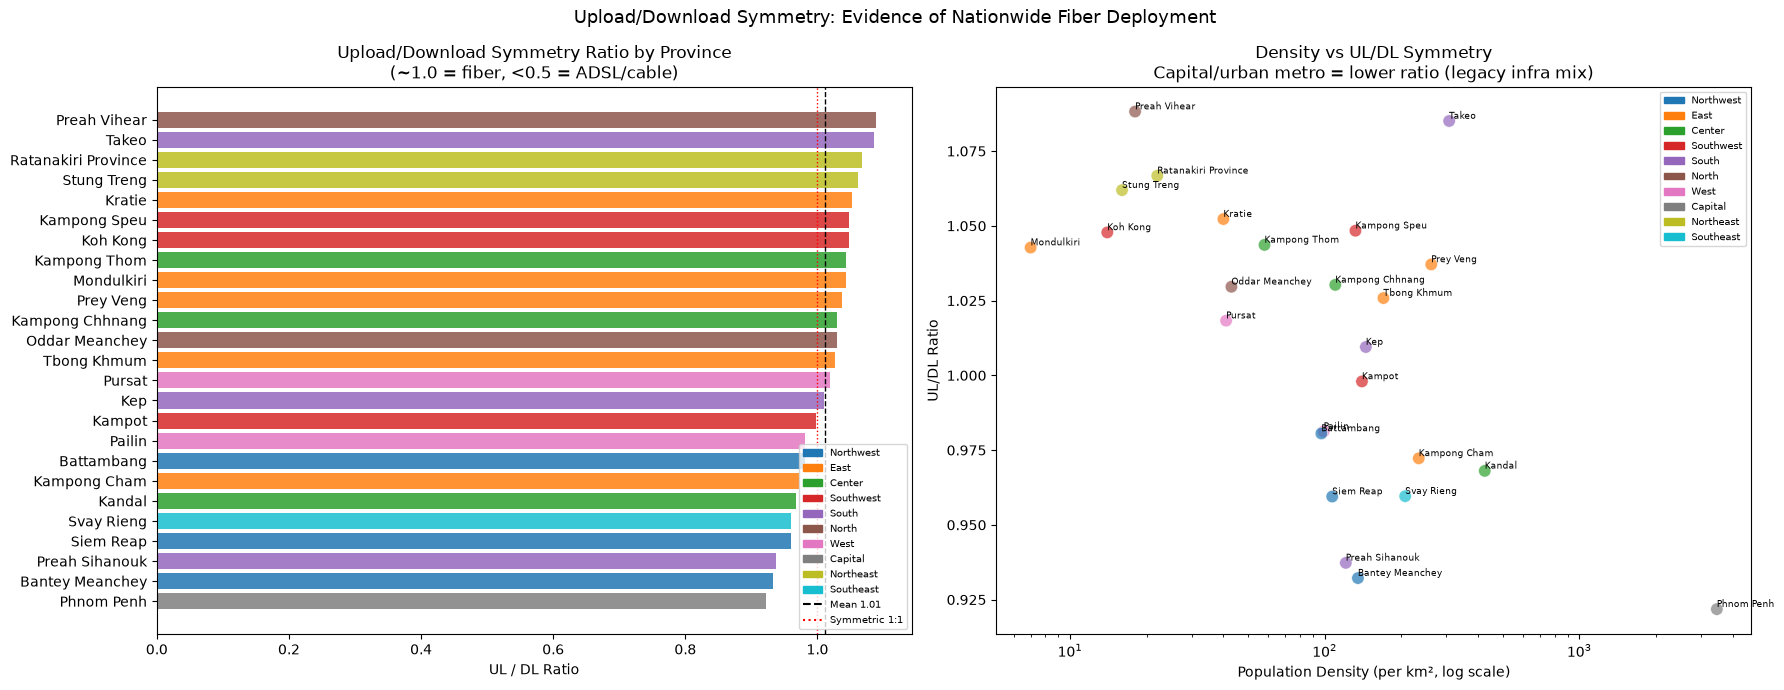

Provinces ratio > 0.90: 25 (near-perfect fiber)
Provinces ratio > 0.80: 25 out of 25
Northwest min ratio: 0.932
Northwest max ratio: 0.981


In [35]:
# Near-symmetric UL/DL often indicates fiber (GPON/FTTH ~1:1) vs legacy copper (ADSL ~0.1-0.2)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1,
                label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
axes[0].set_xlabel('UL / DL Ratio')
axes[0].set_title('Upload/Download Symmetry Ratio by Province\n(~1.0 = fiber, <0.5 = ADSL/cable)')
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches + [
    plt.Line2D([0],[0],color='black',ls='--',label=f'Mean {prov_mean["mean_ratio"].mean():.2f}'),
    plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
], fontsize=7, loc='lower right')

axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                prov_mean['mean_ratio'].values,
                c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                s=80, alpha=0.7, edgecolors='white', lw=0.5)
for _, row in prov_mean.iterrows():
    if row['mean_ratio'] > 0.91 or row['mean_ratio'] < 0.81 or row['mean_dl'] > 300:
        density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
        if len(density):
            axes[1].annotate(row['name'], (density[0], row['mean_ratio']),
                             fontsize=6.5, ha='left', va='bottom')
axes[1].set_xscale('log')
axes[1].set_xlabel('Population Density (per km², log scale)')
axes[1].set_ylabel('UL/DL Ratio')
axes[1].set_title('Density vs UL/DL Symmetry\nCapital/urban metro = lower ratio (legacy infra mix)')
axes[1].legend(handles=patches, fontsize=7)

plt.suptitle('Upload/Download Symmetry: Evidence of Nationwide Fiber Deployment', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

_top_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmax(), 'region']
_bot_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmin(), 'region']
print(f"Provinces ratio > 0.90: {(prov_mean['mean_ratio'] > 0.90).sum()} (near-perfect fiber)")
print(f"Provinces ratio > 0.80: {(prov_mean['mean_ratio'] > 0.80).sum()} out of {len(prov_mean)}")
print(f"{_top_region} min ratio: {prov_mean[prov_mean['region']==_top_region]['mean_ratio'].min():.3f}")
print(f"{_bot_region} max ratio: {prov_mean[prov_mean['region']==_bot_region]['mean_ratio'].max():.3f}")


### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

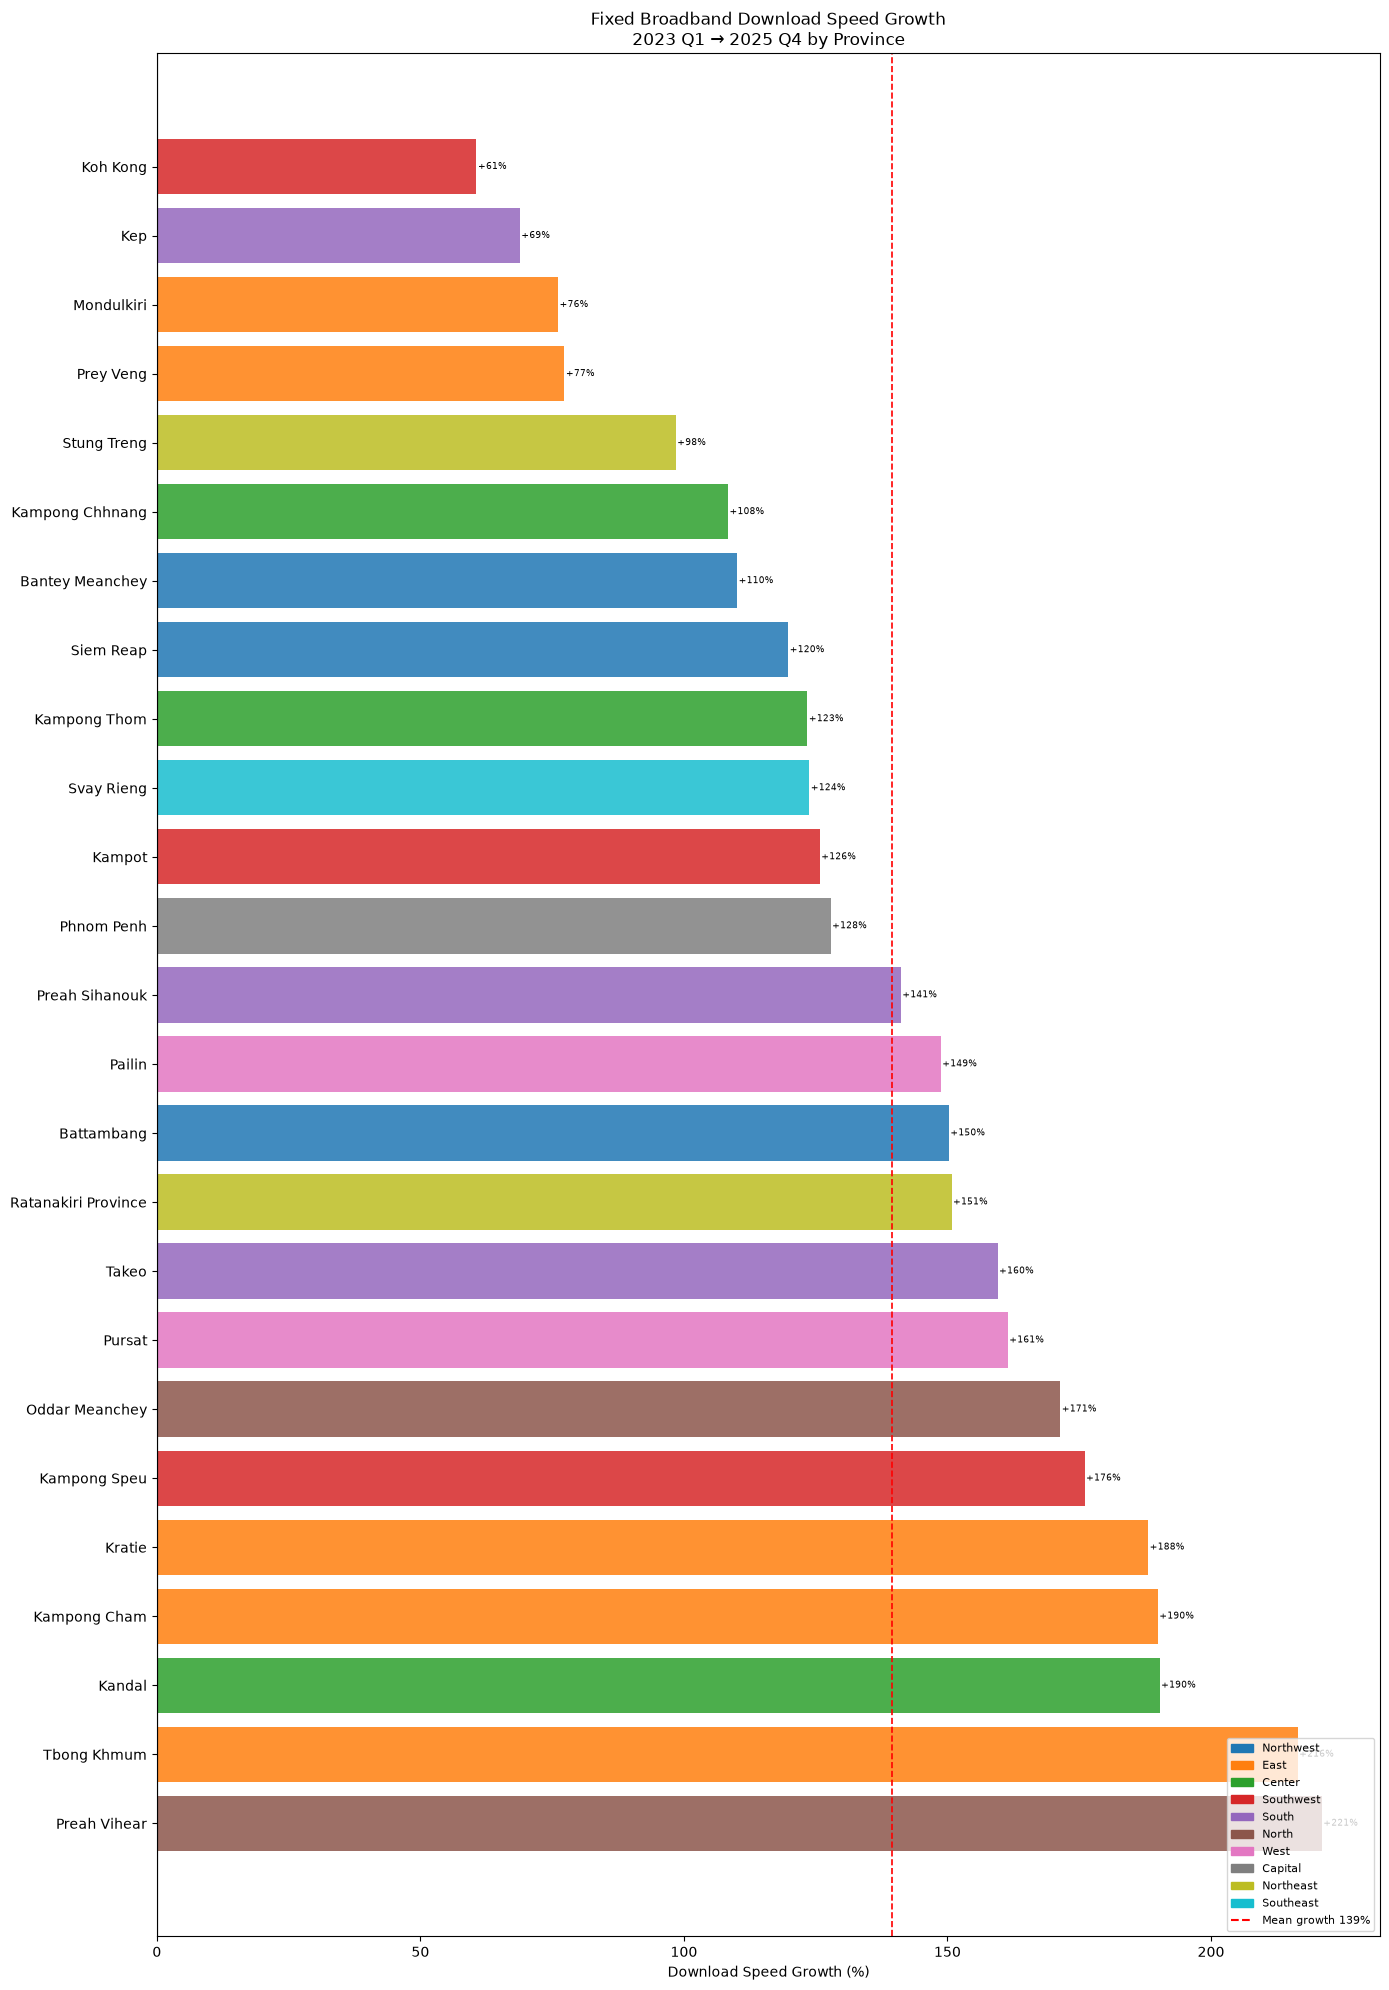

Top 10 fastest growing provinces:
               name    region  internet_tier  pct_growth
       Preah Vihear     North              3  221.010885
        Tbong Khmum      East              4  216.442638
             Kandal    Center              2  190.249833
       Kampong Cham      East              4  189.906486
             Kratie      East              3  188.083819
       Kampong Speu Southwest              4  176.012029
     Oddar Meanchey     North              1  171.407463
             Pursat      West              4  161.440456
              Takeo     South              1  159.502906
Ratanakiri Province Northeast              4  150.769924

Bottom 5 (slowest growth or decline):
       name    region  internet_tier  pct_growth
   Koh Kong Southwest              3   60.642259
        Kep     South              2   68.860446
 Mondulkiri      East              4   76.122130
  Prey Veng      East              1   77.329729
Stung Treng Northeast              3   98.442877


In [36]:
first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

growth_df = growth.reset_index()
growth_df.columns = ['name','pct_growth']
growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in growth_df['region']]
bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2,
           label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
for bar, val in zip(bars, growth_df['pct_growth']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}%', va='center', fontsize=6.5)
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f'Mean growth {growth_df["pct_growth"].mean():.0f}%')],
          fontsize=8, loc='lower right')
ax.set_xlabel('Download Speed Growth (%)')
ax.set_title('Fixed Broadband Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/20_density_vs_speed.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 fastest growing provinces:")
print(growth_df.nlargest(10,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))
print("\nBottom 5 (slowest growth or decline):")
print(growth_df.nsmallest(5,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))


### 15. Deep Dive — The Divergent Ones

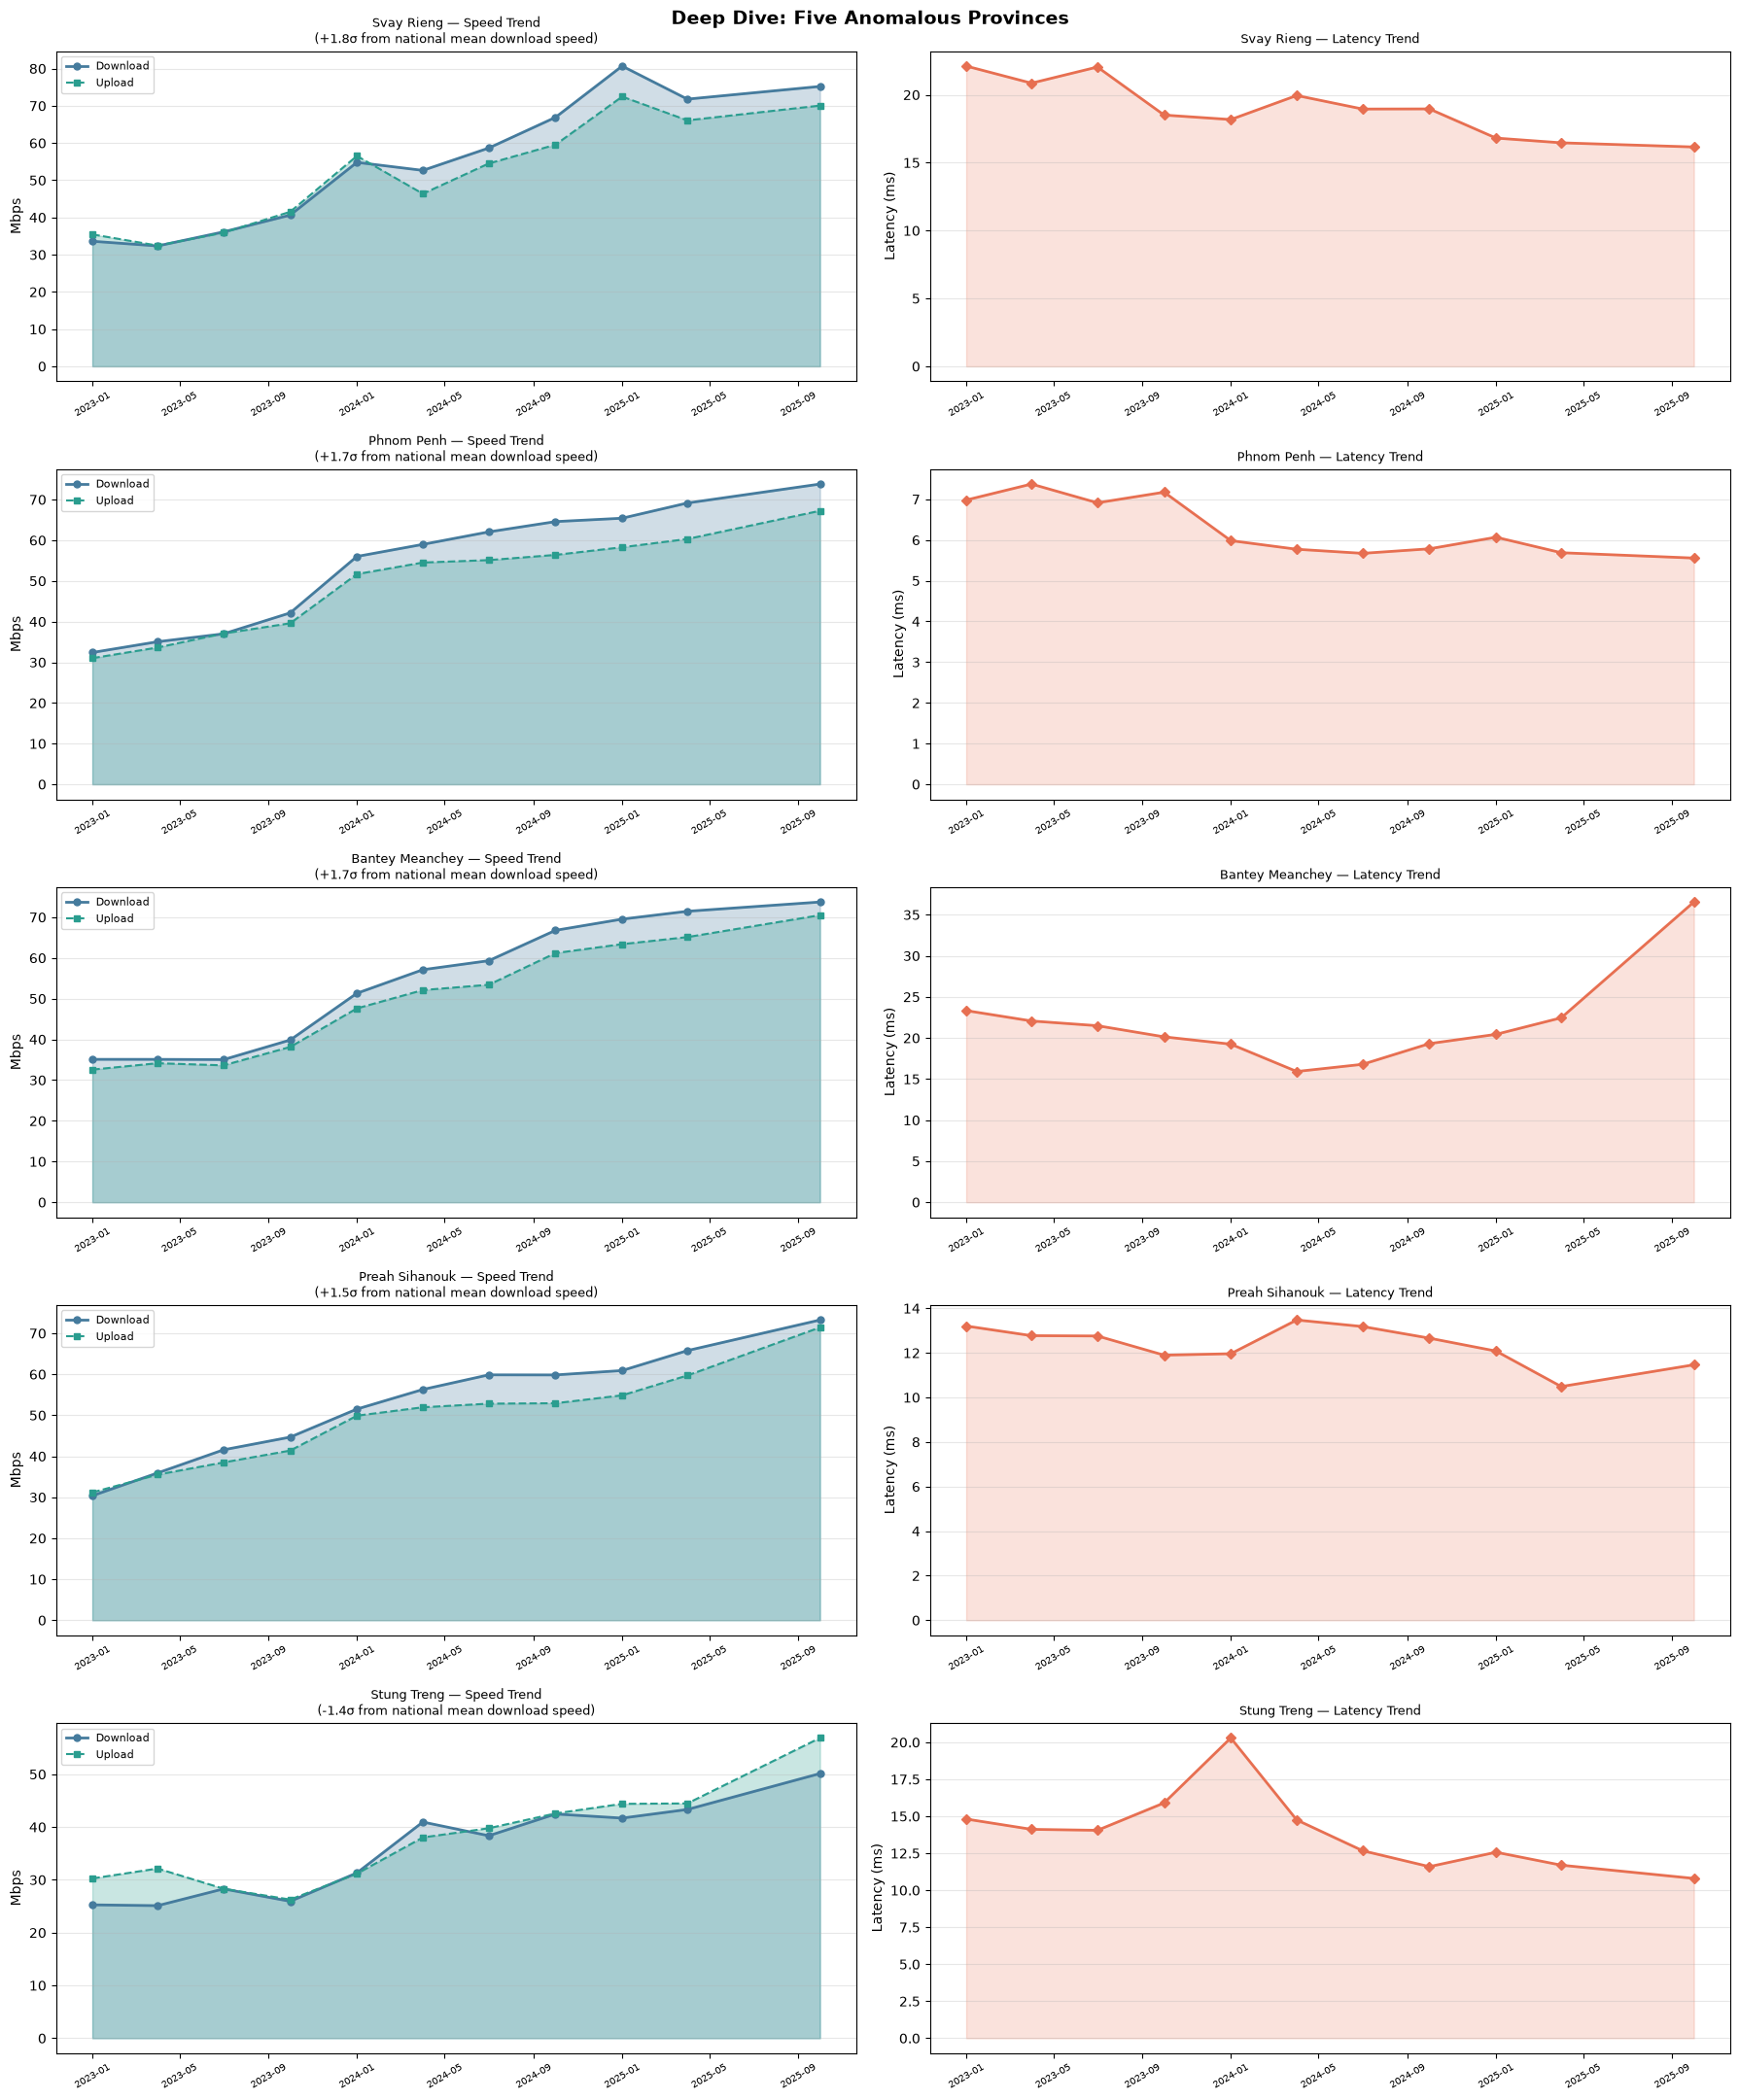

In [37]:
# Focus on the 5 most extreme performers (data-driven selection, no anomaly flags)
_pm = prov_mean.copy()
_pm['z'] = (_pm['mean_dl'] - _pm['mean_dl'].mean()) / _pm['mean_dl'].std()
_top_divergent_df = _pm.reindex(_pm['z'].abs().sort_values(ascending=False).index).head(5)
DIVERGENT = {
    row['name']: f"{row['z']:+.1f}σ from national mean download speed"
    for _, row in _top_divergent_df.iterrows()
}

fig, axes = plt.subplots(len(DIVERGENT), 2, figsize=(18, 22))

quarter_order = sorted(master['label'].unique())

for ax_row, (prov, note) in zip(axes, DIVERGENT.items()):
    df_p = master[master['name']==prov].sort_values('label')
    
    # Download + upload trend
    ax_row[0].fill_between(df_p['period_start'], df_p['avg_d_mbps'], alpha=0.25, color='#457b9d')
    ax_row[0].plot(df_p['period_start'], df_p['avg_d_mbps'], 'o-', color='#457b9d', label='Download', lw=2, markersize=5)
    ax_row[0].fill_between(df_p['period_start'], df_p['avg_u_mbps'], alpha=0.25, color='#2a9d8f')
    ax_row[0].plot(df_p['period_start'], df_p['avg_u_mbps'], 's--', color='#2a9d8f', label='Upload', lw=1.5, markersize=4)
    ax_row[0].set_title(f'{prov} — Speed Trend\n({note})', fontsize=9)
    ax_row[0].set_ylabel('Mbps'); ax_row[0].legend(fontsize=8); ax_row[0].grid(axis='y', alpha=0.3)
    ax_row[0].tick_params(axis='x', rotation=30, labelsize=7)
    
    # Latency trend
    ax_row[1].plot(df_p['period_start'], df_p['avg_lat_ms_wt'], 'D-', color='#e76f51', lw=2, markersize=5)
    ax_row[1].fill_between(df_p['period_start'], df_p['avg_lat_ms_wt'], alpha=0.2, color='#e76f51')
    ax_row[1].set_title(f'{prov} — Latency Trend', fontsize=9)
    ax_row[1].set_ylabel('Latency (ms)'); ax_row[1].grid(axis='y', alpha=0.3)
    ax_row[1].tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle('Deep Dive: Five Anomalous Provinces', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/21_deep_dive_divergent.png', dpi=150, bbox_inches='tight')
plt.show()


### 16. EDA Key Findings Summary

## Key Findings from EDA

---

In [38]:
from scipy import stats as scipy_stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

_DATA_ROOT = '/home/chissanupun/Desktop/Code/lab/cnc/ds/internet-measurement/data'

# Fallback: load master and prov_ref if not already in scope
if 'master' not in dir() or master is None:
    master = pd.read_parquet(f'{_DATA_ROOT}/ookla/processed/master_province_quarterly.parquet')
    print("Loaded master from processed parquet")
if 'prov_ref' not in dir() or prov_ref is None:
    prov_ref = pd.read_csv(f'{_DATA_ROOT}/reference/province_reference.csv')
    print("Loaded prov_ref from CSV")

# ── Build per-province summary (self-contained) ────────────────────────────────
divergent_df = (
    master.groupby(['name', 'region'])
    .agg(
        mean_dl=('avg_d_mbps', 'mean'),
        mean_ul=('avg_u_mbps', 'mean'),
        mean_lat=('avg_lat_ms_wt', 'mean'),
        mean_tests=('total_tests', 'mean'),
    )
    .reset_index()
)

# Temporal instability: std of quarterly download speed
temp_std = master.groupby('name')['avg_d_mbps'].std().rename('std_dl')
divergent_df = divergent_df.merge(temp_std, on='name', how='left')
divergent_df['cv_dl'] = divergent_df['std_dl'] / divergent_df['mean_dl']

# Merge reference cols
divergent_df = divergent_df.merge(
    prov_ref[['province_en','pop_2024','density_per_km2',
              'gdp_per_capita_thb_2021','internet_tier','area_km2']]
    .rename(columns={'province_en': 'name'}),
    on='name', how='left'
)

divergent_df['ul_dl_ratio']        = divergent_df['mean_ul'] / divergent_df['mean_dl']
divergent_df['tests_per_1000_pop'] = divergent_df['mean_tests'] / divergent_df['pop_2024'] * 1_000

print(f"Provinces in analysis: {len(divergent_df)}")
print(divergent_df[['name','region','internet_tier','mean_dl','ul_dl_ratio','tests_per_1000_pop']].head(5).to_string(index=False))


Provinces in analysis: 25
           name    region  internet_tier   mean_dl  ul_dl_ratio  tests_per_1000_pop
Bantey Meanchey Northwest              1 54.030543     0.928478           14.695562
     Battambang Northwest              2 43.182480     0.978282            6.291505
   Kampong Cham      East              4 39.216799     0.978116            3.544886
Kampong Chhnang    Center              1 44.730620     1.019377            3.343631
   Kampong Speu Southwest              4 45.668247     1.059596            3.237679


In [39]:
# ── Dimension 1: Tier residual ─────────────────────────────────────────────────
tier_med = divergent_df.groupby('internet_tier')['mean_dl'].median()
divergent_df['tier_expected']   = divergent_df['internet_tier'].map(tier_med)
divergent_df['tier_residual']   = (divergent_df['mean_dl'] - divergent_df['tier_expected']) / divergent_df['tier_expected']
divergent_df['tier_residual_z'] = (divergent_df['tier_residual'] - divergent_df['tier_residual'].mean()) / divergent_df['tier_residual'].std()

# ── Dimension 2: GDP residual (OLS on log-GDP) ─────────────────────────────────
log_gdp = np.log(divergent_df['gdp_per_capita_thb_2021'])
if log_gdp.nunique() > 1:
    slope_g, int_g, r_g, p_g, _ = scipy_stats.linregress(log_gdp, divergent_df['mean_dl'])
    divergent_df['gdp_expected']   = int_g + slope_g * log_gdp
    divergent_df['gdp_residual']   = divergent_df['mean_dl'] - divergent_df['gdp_expected']
    divergent_df['gdp_residual_z'] = scipy_stats.zscore(divergent_df['gdp_residual'])
else:
    # GDP per capita uniform across regions (e.g. Singapore: national-only data) — dimension contributes nothing
    slope_g, int_g, r_g, p_g = 0.0, divergent_df['mean_dl'].mean(), float('nan'), float('nan')
    divergent_df['gdp_expected']   = int_g
    divergent_df['gdp_residual']   = 0.0
    divergent_df['gdp_residual_z'] = 0.0

# ── Dimension 3: Density residual (OLS on log-density) ────────────────────────
log_den = np.log1p(divergent_df['density_per_km2'])
slope_d, int_d, r_d, p_d, _ = scipy_stats.linregress(log_den, divergent_df['mean_dl'])
divergent_df['den_expected']   = int_d + slope_d * log_den
divergent_df['den_residual_z'] = scipy_stats.zscore(divergent_df['mean_dl'] - divergent_df['den_expected'])

# ── Dimension 4: Regional z-score (speed within region) ───────────────────────
divergent_df['regional_z'] = divergent_df.groupby('region')['mean_dl'].transform(
    lambda x: scipy_stats.zscore(x) if len(x) > 1 else pd.Series(np.zeros(len(x)), index=x.index)
)

# ── Dimension 5: UL/DL ratio z-score ──────────────────────────────────────────
divergent_df['ratio_z'] = scipy_stats.zscore(divergent_df['ul_dl_ratio'])

# ── Dimension 6: Within-region latency z-score ────────────────────────────────
divergent_df['lat_regional_z'] = divergent_df.groupby('region')['mean_lat'].transform(
    lambda x: scipy_stats.zscore(x) if len(x) > 1 else pd.Series(np.zeros(len(x)), index=x.index)
)

# ── Dimension 7: Coverage z-score (tests per 1000 pop) ────────────────────────
divergent_df['coverage_z'] = scipy_stats.zscore(divergent_df['tests_per_1000_pop'])

# ── Composite divergence score (sum of absolute z-scores) ──────────────────────
divergent_df['divergence_score'] = (
    np.abs(divergent_df['tier_residual_z']) +
    np.abs(divergent_df['gdp_residual_z']) +
    np.abs(divergent_df['den_residual_z']) +
    np.abs(divergent_df['regional_z']) +
    np.abs(divergent_df['ratio_z']) +
    np.abs(divergent_df['lat_regional_z']) +
    np.abs(divergent_df['coverage_z'])
)

print(f"GDP-speed OLS:     r = {r_g:.3f}, slope = {slope_g:.2f} Mbps per log-unit GDP")
print(f"Density-speed OLS: r = {r_d:.3f}, slope = {slope_d:.2f} Mbps per log-unit density")
print()
print("Top 15 divergentest provinces:")
cols = ['name','region','internet_tier','mean_dl','divergence_score',
        'gdp_residual_z','den_residual_z','regional_z','ratio_z','lat_regional_z','coverage_z']
print(divergent_df.nlargest(15,'divergence_score')[cols].to_string(index=False))


GDP-speed OLS:     r = nan, slope = 0.00 Mbps per log-unit GDP
Density-speed OLS: r = 0.490, slope = 2.26 Mbps per log-unit density

Top 15 divergentest provinces:
               name    region  internet_tier   mean_dl  divergence_score  gdp_residual_z  den_residual_z  regional_z   ratio_z  lat_regional_z  coverage_z
     Preah Sihanouk     South              2 52.728533         10.662979             0.0        1.616390    1.389946 -1.598185        1.355786    3.365170
    Bantey Meanchey Northwest              1 54.030543          8.068219             0.0        1.825813    1.341102 -1.661195        1.030312    0.447661
         Mondulkiri      East              4 48.836229          7.196934             0.0        2.065068    1.692001  0.514351        1.926908   -0.057706
         Phnom Penh   Capital              1 54.241835          7.134750             0.0        0.417541    0.000000 -1.989103        0.000000    2.922481
          Prey Veng      East              1 38.509072       

### 18. Tier vs Actual Speed — Expectation Gap

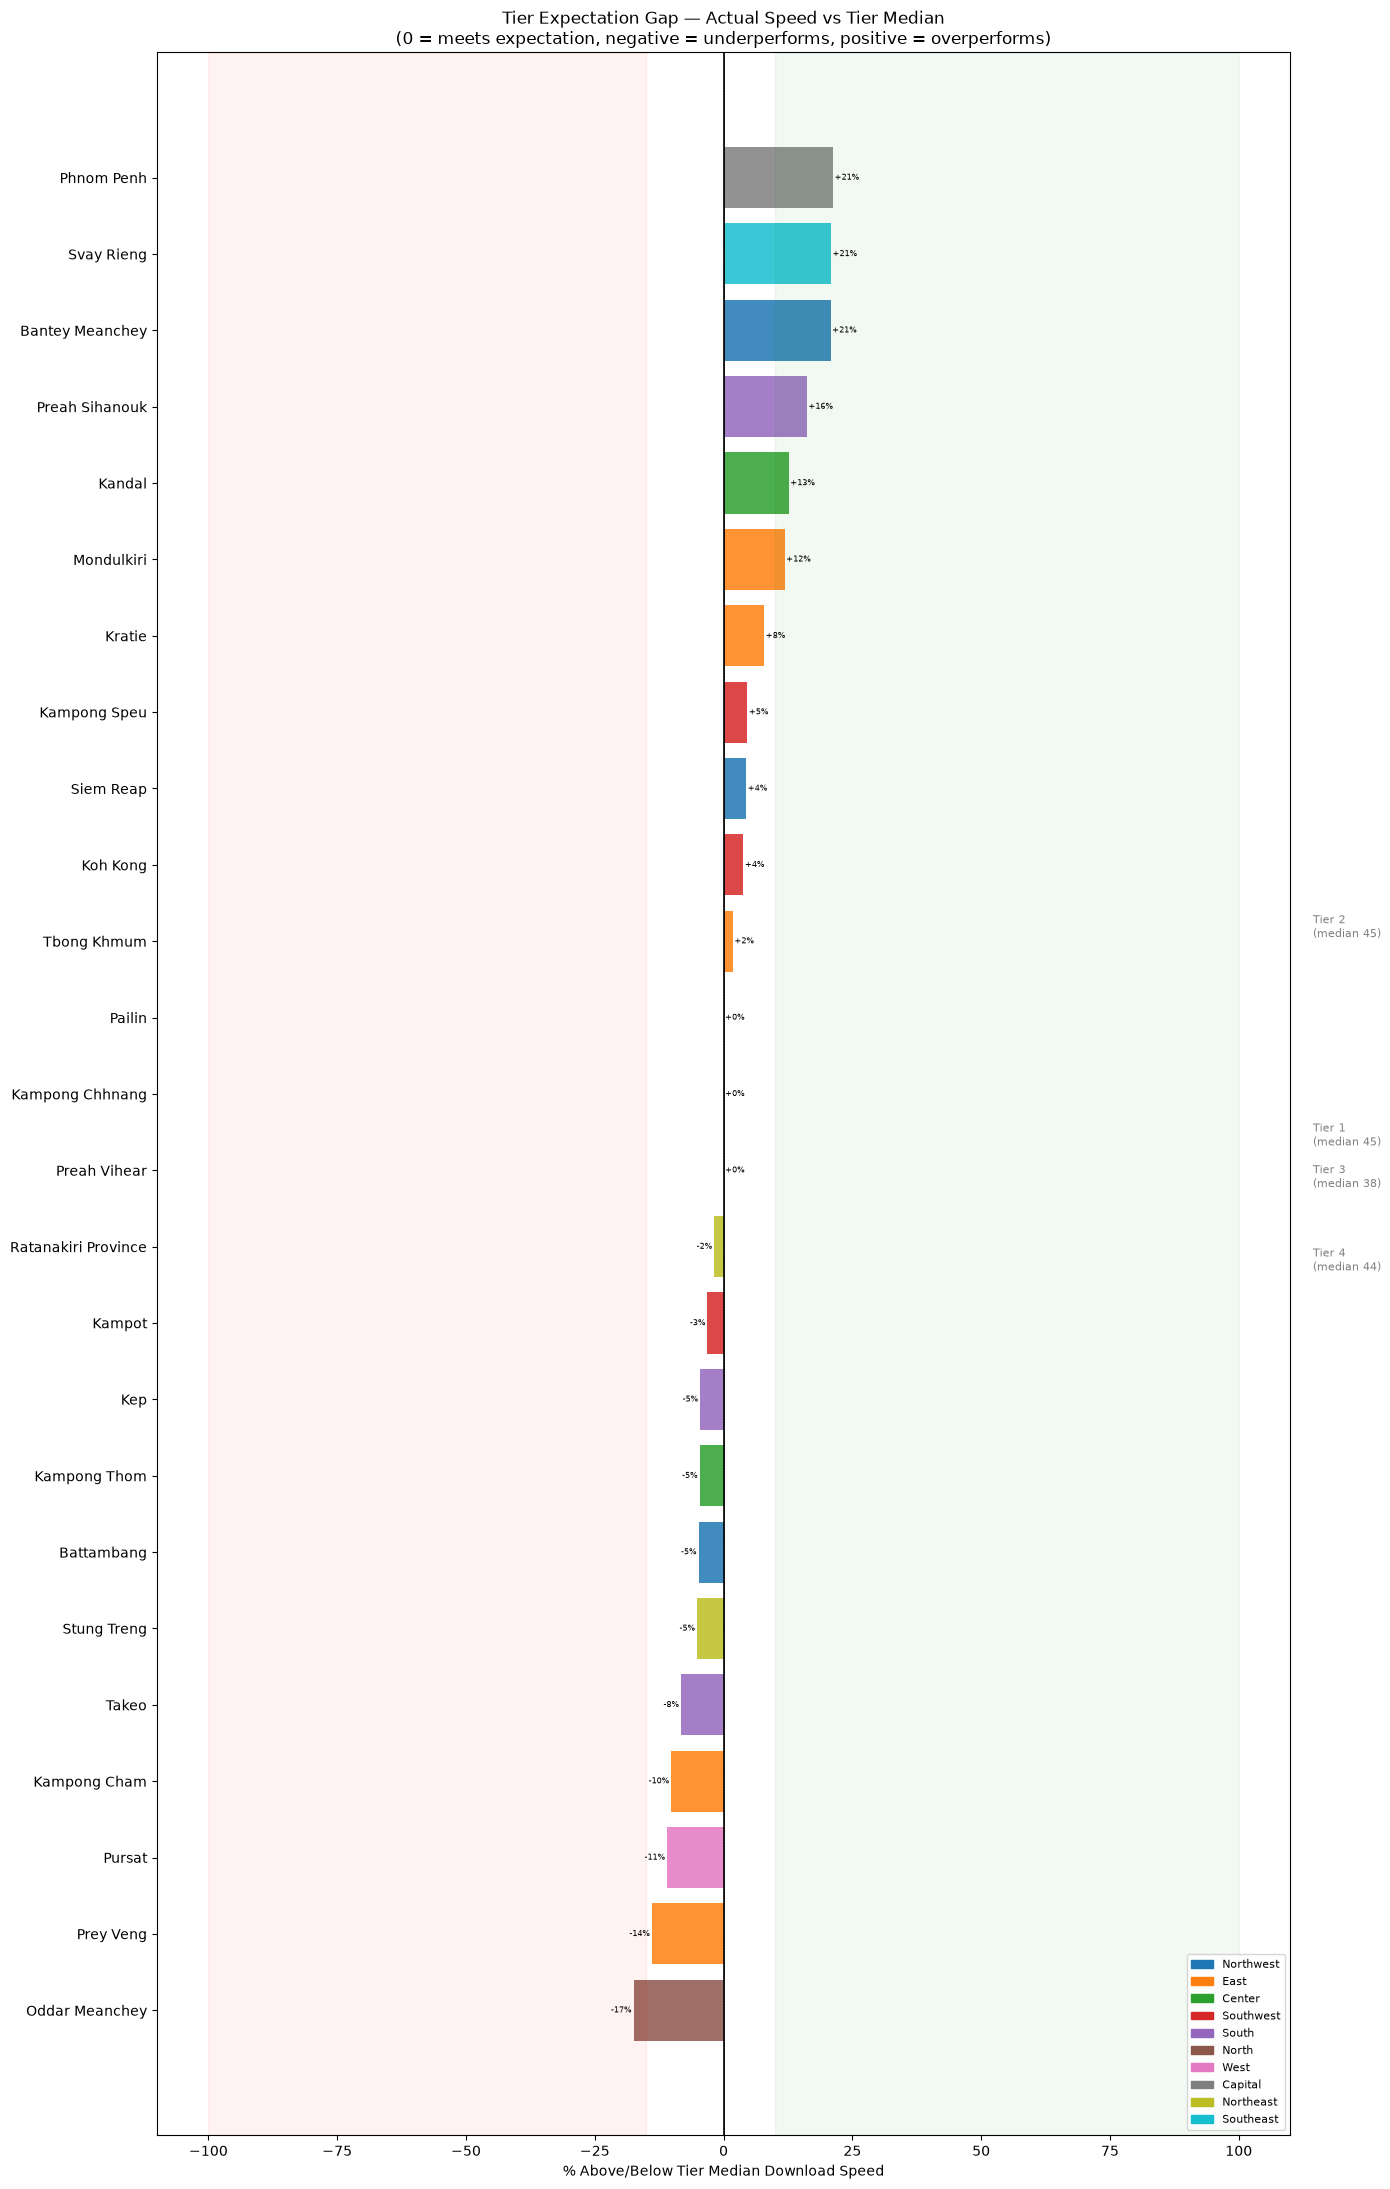

Biggest underperformers vs tier expectation:
          name  internet_tier   mean_dl  tier_expected  tier_residual
Oddar Meanchey              1 36.913084      44.730620      -0.174769
     Prey Veng              1 38.509072      44.730620      -0.139089
        Pursat              4 38.871074      43.653956      -0.109564
  Kampong Cham              4 39.216799      43.653956      -0.101644
         Takeo              1 41.037575      44.730620      -0.082562
   Stung Treng              3 35.713353      37.650541      -0.051452
    Battambang              2 43.182480      45.385647      -0.048543
  Kampong Thom              3 35.899994      37.650541      -0.046495

Biggest overperformers vs tier expectation:
           name  internet_tier   mean_dl  tier_expected  tier_residual
     Phnom Penh              1 54.241835      44.730620       0.212633
     Svay Rieng              2 54.855147      45.385647       0.208645
Bantey Meanchey              1 54.030543      44.730620       0.207

In [40]:
# Show each province's % deviation from its tier median
tier_gap = divergent_df[['name','region','internet_tier','mean_dl','tier_expected','tier_residual']].copy()
tier_gap = tier_gap.sort_values('tier_residual')

fig, ax = plt.subplots(figsize=(14, 22))

region_colors = {
    'Northwest': '#1f77b4',
    'East': '#ff7f0e',
    'Center': '#2ca02c',
    'Southwest': '#d62728',
    'South': '#9467bd',
    'North': '#8c564b',
    'West': '#e377c2',
    'Capital': '#7f7f7f',
    'Northeast': '#bcbd22',
    'Southeast': '#17becf',
}

colors = [region_colors.get(r, 'gray') for r in tier_gap['region']]
bars = ax.barh(tier_gap['name'], tier_gap['tier_residual'] * 100, color=colors, alpha=0.85)

# Tier median reference lines
ax.axvline(0, color='black', lw=1.2, label='Tier median (expected)')

# Annotate bars
for bar, val in zip(bars, tier_gap['tier_residual']):
    x = bar.get_width()
    ax.text(x + (0.3 if x >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
            f'{val*100:+.0f}%', va='center', ha='left' if x >= 0 else 'right', fontsize=6)

# Tier grouping lines
tier_boundaries = tier_gap.groupby('internet_tier').apply(lambda g: (g.index.min(), g.index.max()))
for t in sorted(tier_gap['internet_tier'].unique()):
    grp = tier_gap[tier_gap['internet_tier'] == t]
    median = tier_med[t]
    ax.axvline(0, color='black', lw=0.4, ls='--', alpha=0.4)

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, fontsize=8, loc='lower right')
ax.set_xlabel('% Above/Below Tier Median Download Speed')
ax.set_title('Tier Expectation Gap — Actual Speed vs Tier Median\n'
             '(0 = meets expectation, negative = underperforms, positive = overperforms)', fontsize=12)
ax.axvspan(-100, -15, alpha=0.05, color='red', label='Strong underperform')
ax.axvspan(10, 100, alpha=0.05, color='green')

# Annotate Tier brackets on y-axis
for t in sorted(tier_gap['internet_tier'].unique()):
    grp_idx = tier_gap[tier_gap['internet_tier']==t].index
    grp_pos = [list(tier_gap.index).index(i) for i in grp_idx]
    if grp_pos:
        mid = (min(grp_pos) + max(grp_pos)) / 2
        ax.annotate(f'Tier {t}\n(median {tier_med[t]:.0f})', xy=(1.02, mid/len(tier_gap)),
                    xycoords='axes fraction', va='center', fontsize=8, color='gray')

plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/22_tier_expectation_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Biggest underperformers vs tier expectation:")
print(tier_gap.nsmallest(8,'tier_residual')[['name','internet_tier','mean_dl','tier_expected','tier_residual']].to_string(index=False))
print()
print("Biggest overperformers vs tier expectation:")
print(tier_gap.nlargest(8,'tier_residual')[['name','internet_tier','mean_dl','tier_expected','tier_residual']].to_string(index=False))


### 19. GDP per Capita vs Download Speed — Who Breaks the Rule?

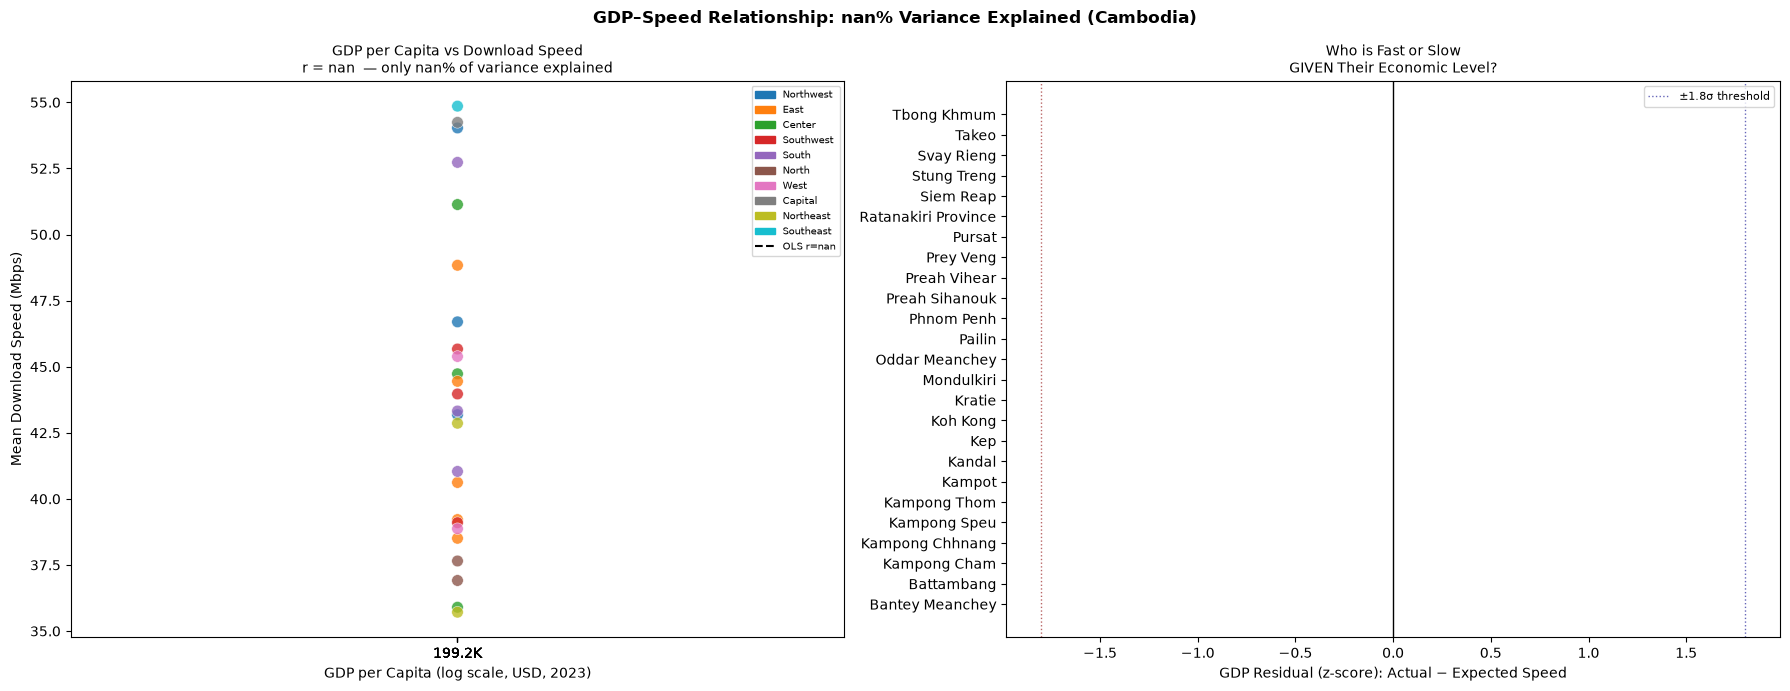

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: GDP scatter ──────────────────────────────────────────────────────────
ax = axes[0]
gdp_vals = divergent_df['gdp_per_capita_thb_2021']
colors_scatter = [region_colors.get(r, 'gray') for r in divergent_df['region']]

sc = ax.scatter(np.log(gdp_vals), divergent_df['mean_dl'],
                c=colors_scatter, s=70, alpha=0.8, edgecolors='white', lw=0.4)

# OLS line
x_fit = np.linspace(np.log(gdp_vals.min()), np.log(gdp_vals.max()), 200)
ax.plot(x_fit, int_g + slope_g * x_fit, 'k--', lw=1.5,
        label=f'OLS fit  r={r_g:.2f}')

# Label big residuals
threshold = 1.8
for _, row in divergent_df.iterrows():
    if abs(row['gdp_residual_z']) > threshold:
        ax.annotate(row['name'],
                    (np.log(row['gdp_per_capita_thb_2021']), row['mean_dl']),
                    fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points',
                    color='darkred' if row['gdp_residual_z'] < 0 else 'darkblue')

ax.set_xlabel('GDP per Capita (log scale, USD, 2023)')
ax.set_ylabel('Mean Download Speed (Mbps)')
ax.set_title(f'GDP per Capita vs Download Speed\nr = {r_g:.2f}  — only {r_g**2*100:.0f}% of variance explained',
             fontsize=10)

# x-tick labels spaced across the actual data range (log scale)
_tick_vals = np.geomspace(gdp_vals.min(), gdp_vals.max(), 5)
ax.set_xticks(np.log(_tick_vals))
ax.set_xticklabels([f'{v/1000:.1f}K' if v >= 1000 else f'{v:.0f}' for v in _tick_vals])

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches + [plt.Line2D([0],[0],color='black',ls='--',label=f'OLS r={r_g:.2f}')],
          fontsize=7)

# ── Right: residual bar chart ──────────────────────────────────────────────────
ax2 = axes[1]
resid_sorted = divergent_df.sort_values('gdp_residual_z')
cols2 = [region_colors.get(r, 'gray') for r in resid_sorted['region']]
bars2 = ax2.barh(resid_sorted['name'], resid_sorted['gdp_residual_z'], color=cols2, alpha=0.85)
ax2.axvline(0, color='black', lw=1)
ax2.axvline(1.8, color='darkblue', ls=':', lw=1, alpha=0.6, label='±1.8σ threshold')
ax2.axvline(-1.8, color='darkred', ls=':', lw=1, alpha=0.6)
ax2.set_xlabel('GDP Residual (z-score): Actual − Expected Speed')
ax2.set_title('Who is Fast or Slow\nGIVEN Their Economic Level?', fontsize=10)
ax2.legend(fontsize=8)
# Add province labels for outliers
for bar, (_, row) in zip(bars2, resid_sorted.iterrows()):
    if abs(row['gdp_residual_z']) > 1.8:
        x = bar.get_width()
        ax2.text(x + (0.05 if x >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
                 row['name'], va='center', ha='left' if x >= 0 else 'right', fontsize=5.5,
                 color='darkblue' if x > 0 else 'darkred', fontweight='bold')

plt.suptitle(f'GDP–Speed Relationship: {r_g**2*100:.0f}% Variance Explained (Cambodia)',
             fontsize=12, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/23_gdp_residual_bar.png', dpi=150, bbox_inches='tight')
plt.show()


### 20. Population Density vs Speed — Greenfield Fiber Effect

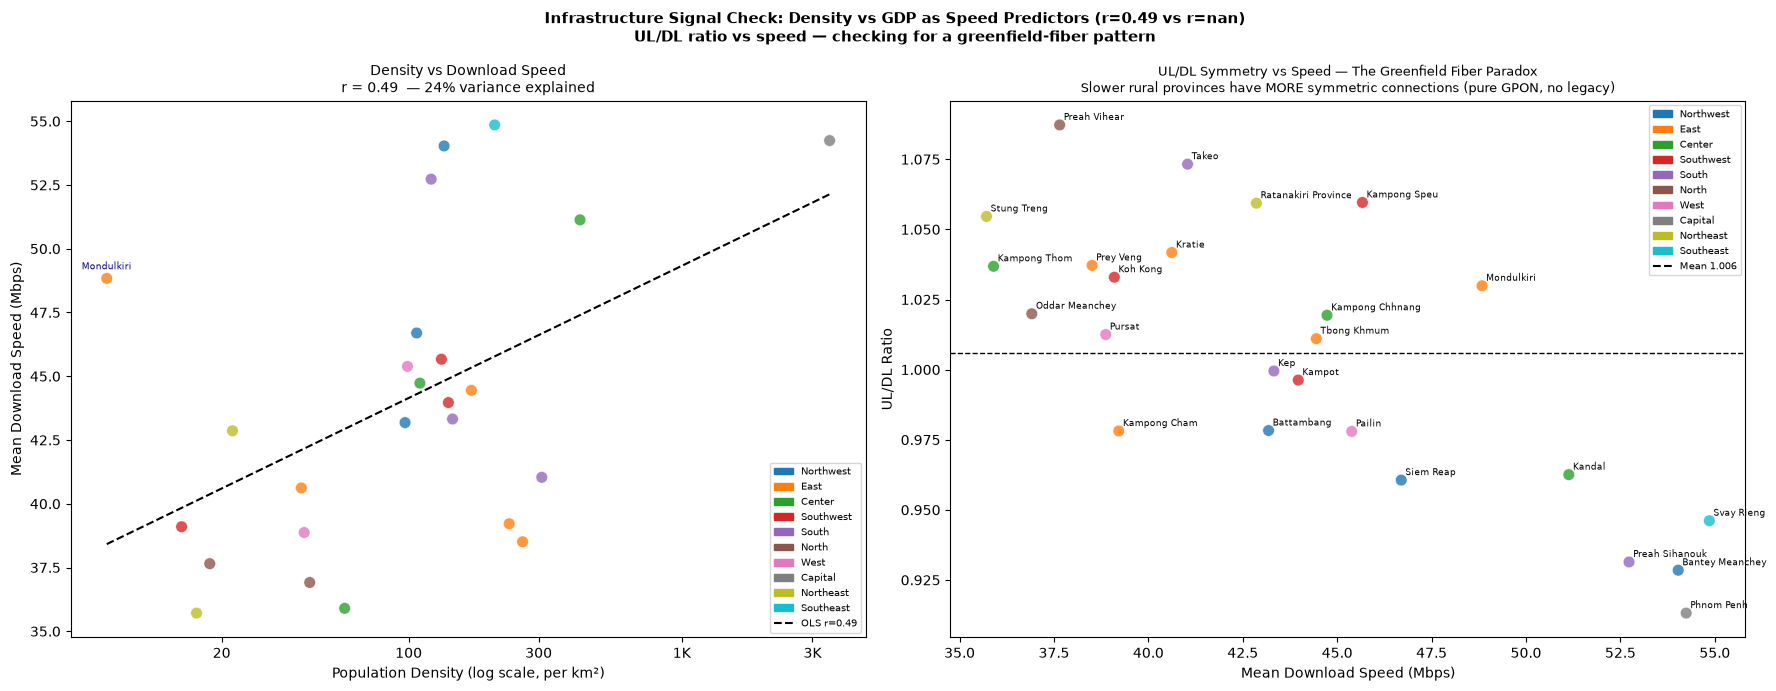

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: Density scatter ──────────────────────────────────────────────────────
ax = axes[0]
den_vals = divergent_df['density_per_km2']
colors_s = [region_colors.get(r, 'gray') for r in divergent_df['region']]

ax.scatter(np.log1p(den_vals), divergent_df['mean_dl'],
           c=colors_s, s=70, alpha=0.8, edgecolors='white', lw=0.4)

x_fit2 = np.linspace(np.log1p(den_vals.min()), np.log1p(den_vals.max()), 200)
ax.plot(x_fit2, int_d + slope_d * x_fit2, 'k--', lw=1.5, label=f'OLS r={r_d:.2f}')

for _, row in divergent_df.iterrows():
    if abs(row['den_residual_z']) > 2.0:
        ax.annotate(row['name'],
                    (np.log1p(row['density_per_km2']), row['mean_dl']),
                    fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points',
                    color='darkred' if row['den_residual_z'] < 0 else 'darkblue')

xticks_den = np.log1p([20, 100, 300, 1000, 3000])
ax.set_xticks(xticks_den)
ax.set_xticklabels(['20','100','300','1K','3K'])
ax.set_xlabel('Population Density (log scale, per km²)')
ax.set_ylabel('Mean Download Speed (Mbps)')
ax.set_title(f'Density vs Download Speed\nr = {r_d:.2f}  — {r_d**2*100:.0f}% variance explained', fontsize=10)
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches + [plt.Line2D([0],[0],color='black',ls='--',label=f'OLS r={r_d:.2f}')],
          fontsize=7)

# ── Right: UL/DL ratio vs DL speed — the "greenfield fiber paradox" ───────────
ax2 = axes[1]
ax2.scatter(divergent_df['mean_dl'], divergent_df['ul_dl_ratio'],
            c=colors_s, s=70, alpha=0.8, edgecolors='white', lw=0.4)

for _, row in divergent_df.iterrows():
    if row['ul_dl_ratio'] > 0.91 or row['ul_dl_ratio'] < 0.80 or row['mean_dl'] < 170:
        ax2.annotate(row['name'], (row['mean_dl'], row['ul_dl_ratio']),
                     fontsize=6.5, ha='left', va='bottom',
                     xytext=(3, 2), textcoords='offset points')

ax2.axhline(divergent_df['ul_dl_ratio'].mean(), color='black', ls='--', lw=1,
            label=f"Mean ratio {divergent_df['ul_dl_ratio'].mean():.3f}")
ax2.set_xlabel('Mean Download Speed (Mbps)')
ax2.set_ylabel('UL/DL Ratio')
ax2.set_title('UL/DL Symmetry vs Speed — The Greenfield Fiber Paradox\n'
              'Slower rural provinces have MORE symmetric connections (pure GPON, no legacy)', fontsize=9)
ax2.legend(handles=patches + [plt.Line2D([0],[0],color='black',ls='--',
           label=f'Mean {divergent_df["ul_dl_ratio"].mean():.3f}')], fontsize=7)

# Add trend arrow annotation
ax2.annotate('← slower but more symmetric\n   (rural greenfield fiber)',
             xy=(155, 0.905), fontsize=7.5, color='#6d6875',
             bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.8))
ax2.annotate('faster but less symmetric →\n(urban legacy cable mix)',
             xy=(285, 0.800), fontsize=7.5, color='#e63946',
             bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.8))

plt.suptitle(f'Infrastructure Signal Check: Density vs GDP as Speed Predictors (r={r_d:.2f} vs r={r_g:.2f})\n'
             'UL/DL ratio vs speed — checking for a greenfield-fiber pattern',
             fontsize=11, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/24_uldl_greenfield.png', dpi=150, bbox_inches='tight')
plt.show()


### 21. Ookla Coverage — Tests per 1,000 Population

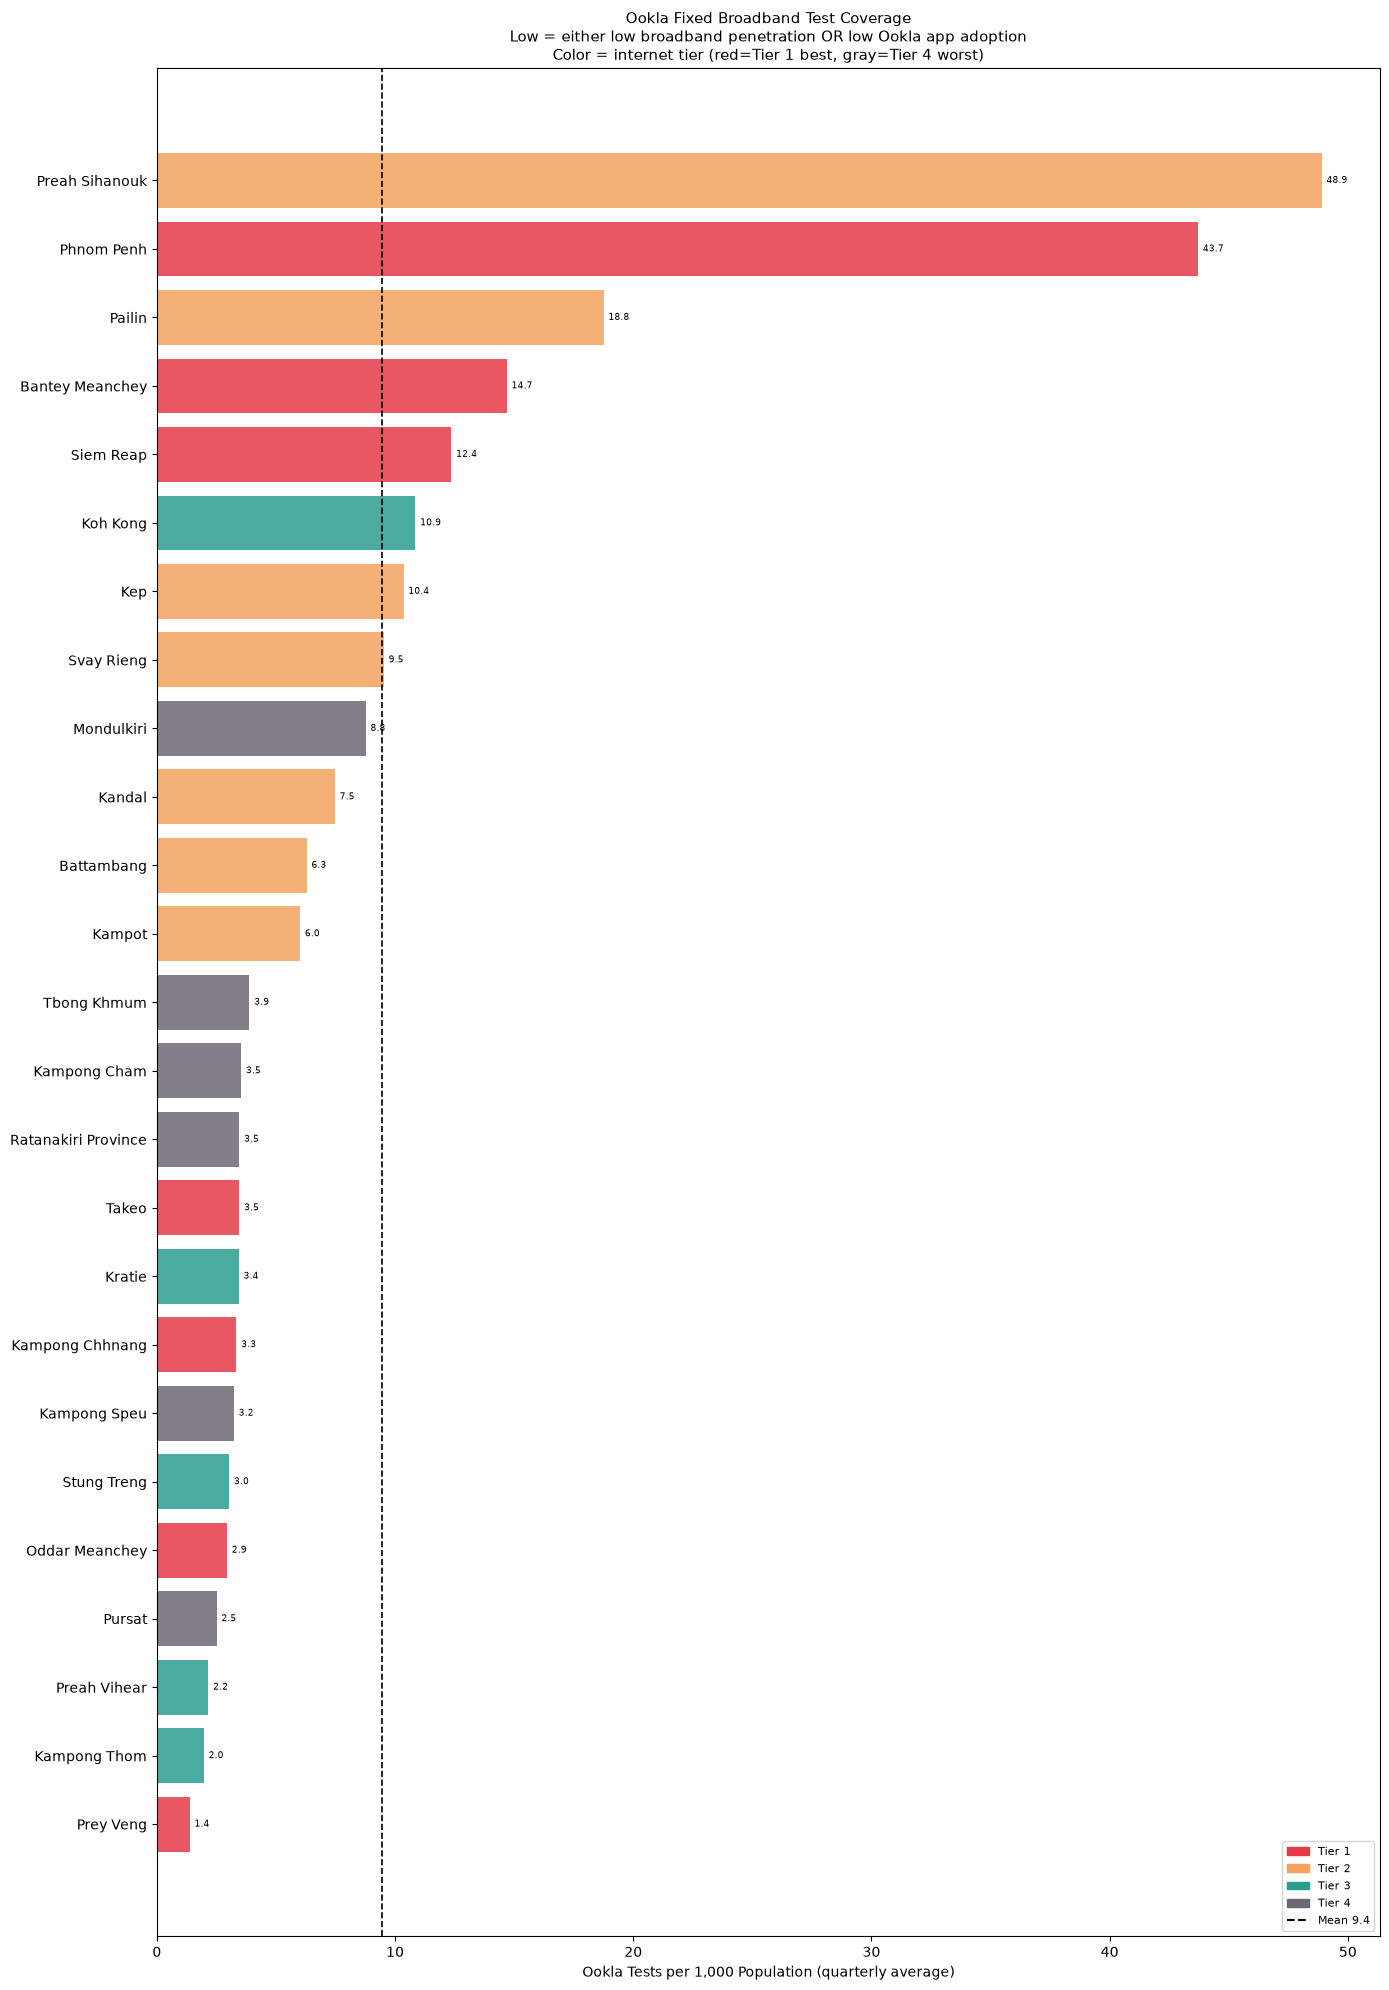

Top coverage (tests per 1000 pop):
           name    region  internet_tier  tests_per_1000_pop    mean_tests  pop_2024
 Preah Sihanouk     South              2           48.904568  11478.000000    234702
     Phnom Penh   Capital              1           43.713853 102852.181818   2352851
         Pailin      West              2           18.759691   1490.363636     79445
Bantey Meanchey Northwest              1           14.695562  13203.727273    898484
      Siem Reap Northwest              1           12.366843  13601.363636   1099825
       Koh Kong Southwest              3           10.857214   1530.454545    140962
            Kep     South              2           10.358030    505.181818     48772
     Svay Rieng Southeast              2            9.534528   5846.181818    613159

Bottom coverage:
           name    region  internet_tier  tests_per_1000_pop  mean_tests  pop_2024
      Prey Veng      East              1            1.383200 1767.545455   1277867
   Kampong Thom 

In [43]:
# Tests per 1000 pop = proxy for (broadband penetration × Ookla app adoption × tech-savviness)
cov = divergent_df.sort_values('tests_per_1000_pop')
tier_palette = {1:'#e63946', 2:'#f4a261', 3:'#2a9d8f', 4:'#6d6875'}
colors_cov = [tier_palette.get(int(t), 'gray') for t in cov['internet_tier']]

fig, ax = plt.subplots(figsize=(14, 20))
bars = ax.barh(cov['name'], cov['tests_per_1000_pop'], color=colors_cov, alpha=0.85)
ax.axvline(divergent_df['tests_per_1000_pop'].mean(), color='black', ls='--', lw=1.2,
           label=f"National mean {divergent_df['tests_per_1000_pop'].mean():.1f}")

for bar, val in zip(bars, cov['tests_per_1000_pop']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=6.2)

patches_t = [mpatches.Patch(color=v, label=f'Tier {k}') for k, v in tier_palette.items()]
ax.legend(handles=patches_t + [plt.Line2D([0],[0],color='black',ls='--',
           label=f'Mean {divergent_df["tests_per_1000_pop"].mean():.1f}')], fontsize=8)
ax.set_xlabel('Ookla Tests per 1,000 Population (quarterly average)')
ax.set_title('Ookla Fixed Broadband Test Coverage\n'
             'Low = either low broadband penetration OR low Ookla app adoption\n'
             'Color = internet tier (red=Tier 1 best, gray=Tier 4 worst)', fontsize=11)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/25_test_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top coverage (tests per 1000 pop):")
print(divergent_df.nlargest(8,'tests_per_1000_pop')[
    ['name','region','internet_tier','tests_per_1000_pop','mean_tests','pop_2024']
].to_string(index=False))
print()
print("Bottom coverage:")
print(divergent_df.nsmallest(10,'tests_per_1000_pop')[
    ['name','region','internet_tier','tests_per_1000_pop','mean_tests','pop_2024']
].to_string(index=False))


### 22. Composite Divergence Leaderboard — Top 20 Anomalous Provinces

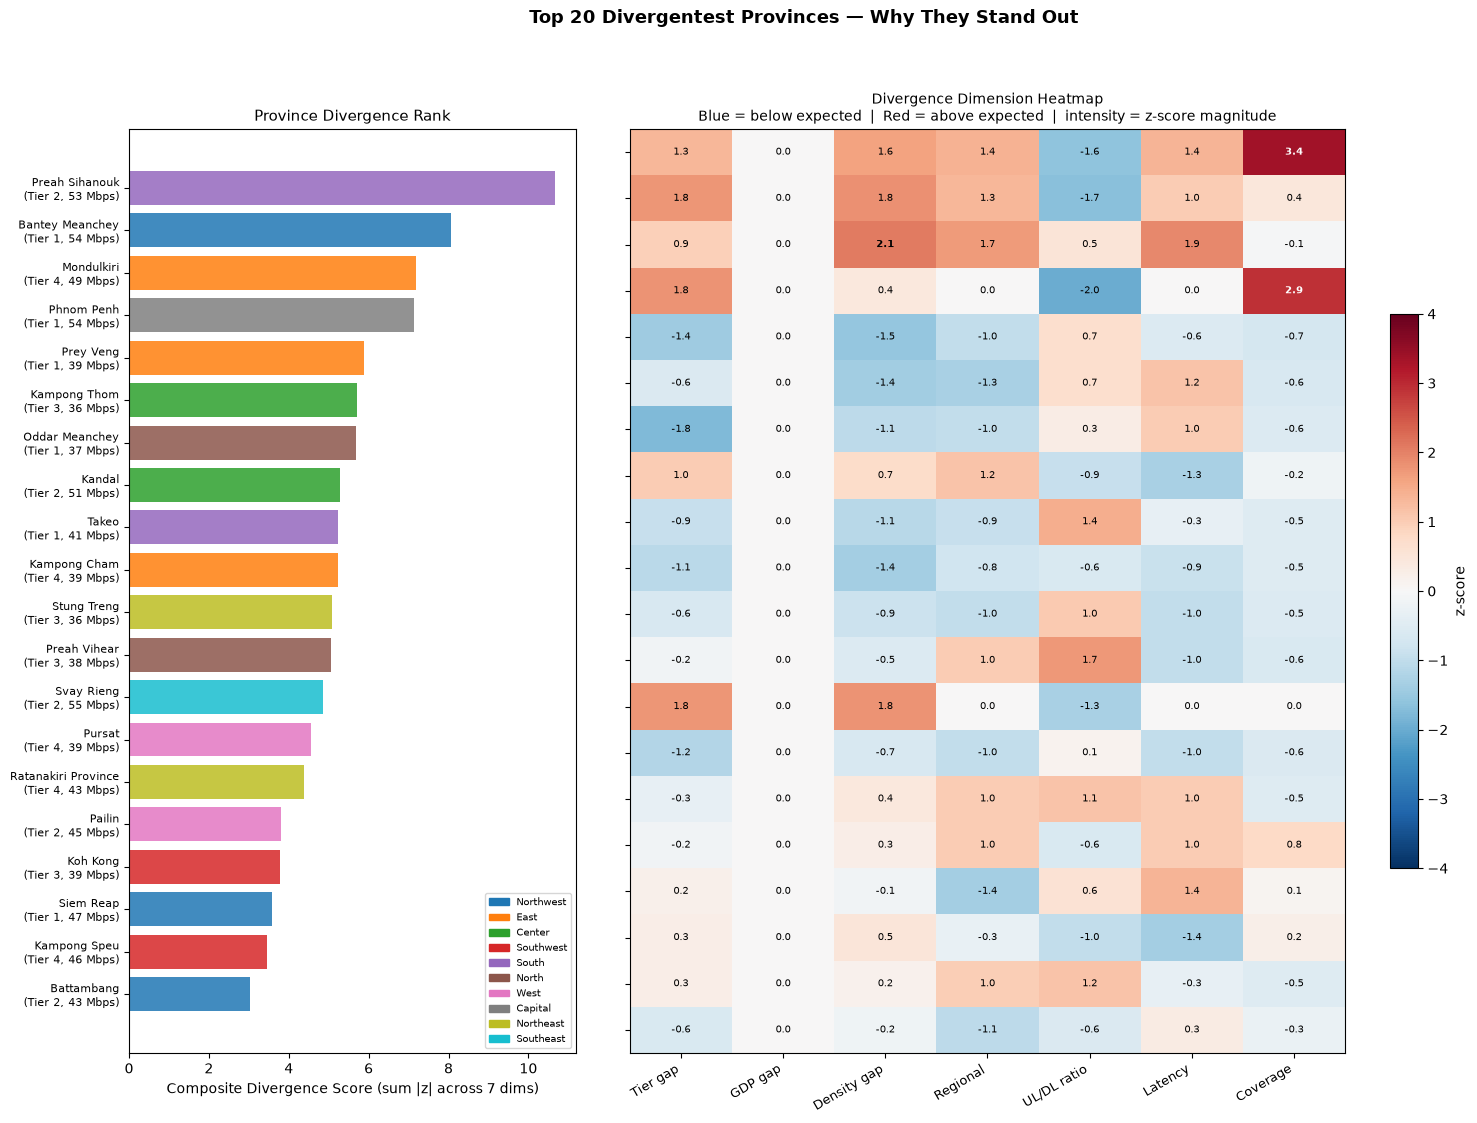


Full leaderboard table:
               name    region  internet_tier   mean_dl  divergence_score  GDP-z     Den-z     Reg-z   Ratio-z     Lat-z     Cov-z
     Preah Sihanouk     South              2 52.728533         10.662979    0.0  1.616390  1.389946 -1.598185  1.355786  3.365170
    Bantey Meanchey Northwest              1 54.030543          8.068219    0.0  1.825813  1.341102 -1.661195  1.030312  0.447661
         Mondulkiri      East              4 48.836229          7.196934    0.0  2.065068  1.692001  0.514351  1.926908 -0.057706
         Phnom Penh   Capital              1 54.241835          7.134750    0.0  0.417541  0.000000 -1.989103  0.000000  2.922481
          Prey Veng      East              1 38.509072          5.888945    0.0 -1.546069 -0.991959  0.670436 -0.560124 -0.687681
       Kampong Thom    Center              3 35.899994          5.714216    0.0 -1.393869 -1.284385  0.663390  1.155178 -0.637234
     Oddar Meanchey     North              1 36.913084          5

In [44]:
TOP_N = min(20, len(divergent_df))
dims = ['tier_residual_z','gdp_residual_z','den_residual_z','regional_z',
        'ratio_z','lat_regional_z','coverage_z']
dim_labels = ['Tier gap','GDP gap','Density gap','Regional','UL/DL ratio','Latency','Coverage']

top20 = divergent_df.nlargest(TOP_N, 'divergence_score').copy().reset_index(drop=True)

fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(1, 2, width_ratios=[1, 2], wspace=0.08)

region_colors = {
    'Northwest': '#1f77b4',
    'East': '#ff7f0e',
    'Center': '#2ca02c',
    'Southwest': '#d62728',
    'South': '#9467bd',
    'North': '#8c564b',
    'West': '#e377c2',
    'Capital': '#7f7f7f',
    'Northeast': '#bcbd22',
    'Southeast': '#17becf',
}

# ── Left: Composite score bar ──────────────────────────────────────────────────
ax_bar = fig.add_subplot(gs[0])
colors_bar = [region_colors.get(r, 'gray') for r in top20['region']]
y_pos = np.arange(TOP_N)
ax_bar.barh(y_pos, top20['divergence_score'], color=colors_bar, alpha=0.85)
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(
    [f"{row['name']}\n(Tier {int(row['internet_tier'])}, {row['mean_dl']:.0f} Mbps)"
     for _, row in top20.iterrows()],
    fontsize=8
)
ax_bar.set_xlabel('Composite Divergence Score (sum |z| across 7 dims)')
ax_bar.set_title('Province Divergence Rank', fontsize=11)
ax_bar.invert_yaxis()

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax_bar.legend(handles=patches, fontsize=7, loc='lower right')

# ── Right: Heatmap of dimension z-scores ──────────────────────────────────────
ax_heat = fig.add_subplot(gs[1])
heat_data = top20[dims].values.astype(float)

im = ax_heat.imshow(heat_data, cmap='RdBu_r', aspect='auto', vmin=-4, vmax=4)
ax_heat.set_xticks(np.arange(len(dim_labels)))
ax_heat.set_xticklabels(dim_labels, rotation=30, ha='right', fontsize=9)
ax_heat.set_yticks(np.arange(TOP_N))
ax_heat.set_yticklabels([''] * TOP_N)

for i in range(TOP_N):
    for j in range(len(dims)):
        val = heat_data[i, j]
        txt_color = 'white' if abs(val) > 2.5 else 'black'
        ax_heat.text(j, i, f'{val:.1f}', ha='center', va='center',
                     fontsize=7, color=txt_color,
                     fontweight='bold' if abs(val) > 2 else 'normal')

ax_heat.set_title(
    'Divergence Dimension Heatmap\n'
    'Blue = below expected  |  Red = above expected  |  intensity = z-score magnitude',
    fontsize=10
)
plt.colorbar(im, ax=ax_heat, label='z-score', shrink=0.6)

plt.suptitle('Top 20 Divergentest Provinces — Why They Stand Out', fontsize=13, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/26_divergence_top20.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFull leaderboard table:")
print(top20[['name','region','internet_tier','mean_dl','divergence_score',
             'gdp_residual_z','den_residual_z','regional_z','ratio_z','lat_regional_z','coverage_z']]
      .rename(columns={'gdp_residual_z':'GDP-z','den_residual_z':'Den-z','regional_z':'Reg-z',
                       'ratio_z':'Ratio-z','lat_regional_z':'Lat-z','coverage_z':'Cov-z'})
      .to_string(index=False))


### 23. Province Divergence Map

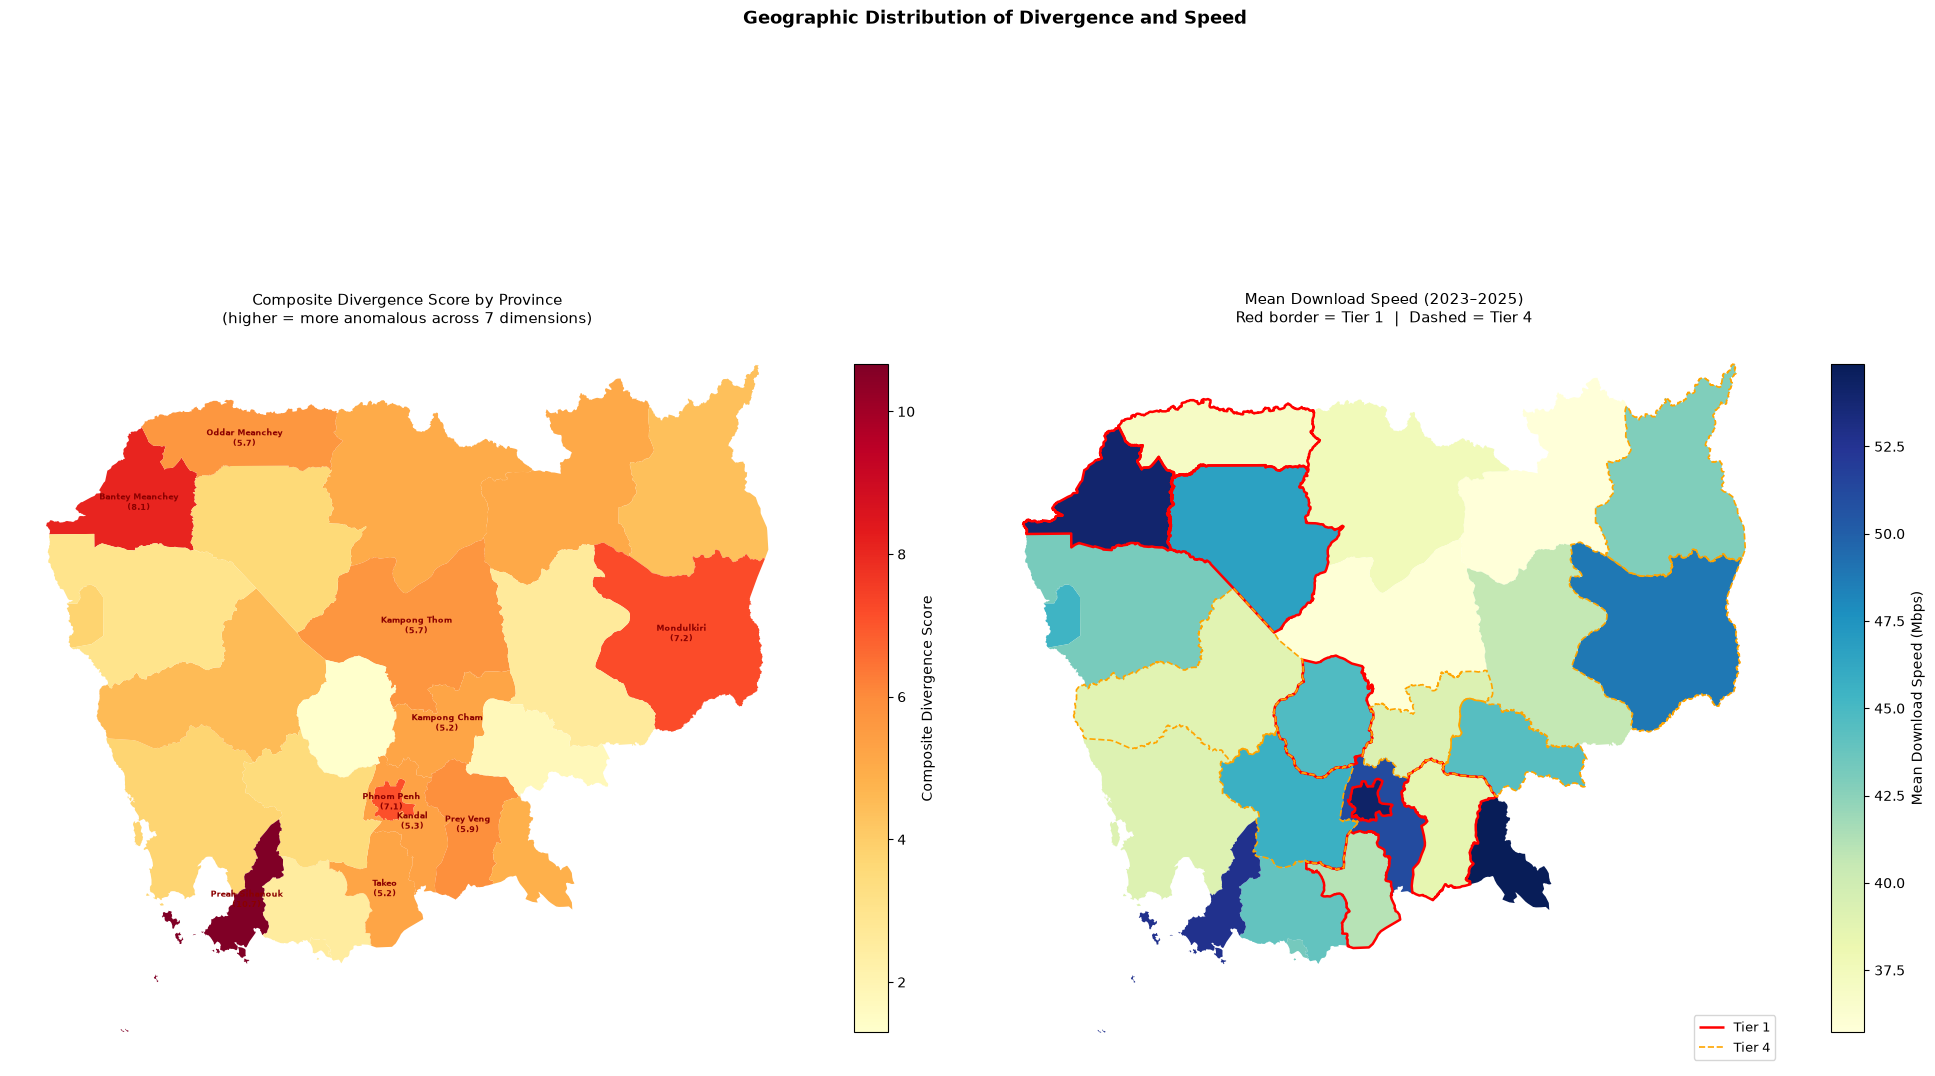

In [45]:
_GEOJSON = '../../data/geo/cambodia_provinces.geojson'

# Load GeoDataFrame with correct path (fallback if earlier cells used old path)
try:
    if 'thailand_gdf' not in dir() or thailand_gdf is None:
        raise NameError
    _ = thailand_gdf.shape  # verify it's valid
except (NameError, Exception):
    thailand_gdf = gpd.read_file(_GEOJSON).to_crs(4326)
    print("Loaded thailand_gdf from correct project path")

geo_divergent = thailand_gdf.copy()
geo_divergent = geo_divergent.merge(
    divergent_df[['name','divergence_score','mean_dl','internet_tier']],
    on='name', how='left'
)
geo_divergent['divergence_score'] = geo_divergent['divergence_score'].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(20, 14))

# ── Left: divergence score choropleth ──────────────────────────────────────────
ax1 = axes[0]
geo_divergent.plot('divergence_score', ax=ax1, cmap='YlOrRd',
               legend=True, missing_kwds={'color':'lightgray'},
               legend_kwds={'label':'Composite Divergence Score','shrink':0.5})

top10_names = divergent_df.nlargest(10, 'divergence_score')['name'].values
for _, row in geo_divergent.iterrows():
    if row['name'] in top10_names:
        c = row.geometry.centroid
        score = row['divergence_score']
        ax1.annotate(f"{row['name']}\n({score:.1f})",
                     (c.x, c.y), ha='center', va='center',
                     fontsize=5.5, color='darkred', fontweight='bold')

ax1.set_title('Composite Divergence Score by Province\n(higher = more anomalous across 7 dimensions)',
              fontsize=11)
ax1.set_axis_off()

# ── Right: download speed choropleth with tier overlay ────────────────────────
ax2 = axes[1]
geo_divergent.plot('mean_dl', ax=ax2, cmap='YlGnBu',
               legend=True, missing_kwds={'color':'lightgray'},
               legend_kwds={'label':'Mean Download Speed (Mbps)','shrink':0.5})

t1 = geo_divergent[geo_divergent['internet_tier'] == 1]
t1.boundary.plot(ax=ax2, color='red', linewidth=1.8, label='Tier 1')
t4 = geo_divergent[geo_divergent['internet_tier'] == 4]
t4.boundary.plot(ax=ax2, color='orange', linewidth=1.2, ls='--', label='Tier 4')

ax2.legend(fontsize=9, loc='lower right')
ax2.set_title('Mean Download Speed (2023–2025)\nRed border = Tier 1  |  Dashed = Tier 4',
              fontsize=11)
ax2.set_axis_off()

plt.suptitle('Geographic Distribution of Divergence and Speed', fontsize=13, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/27_divergence_map.png', dpi=150, bbox_inches='tight')
plt.show()


### 24. Why Are They Divergent? — Annotated Province Notes

### 25. Full Province Divergence Table — All Provinces


In [46]:
# ── Merge display name ────────────────────────────────────────────────────────────
full_table = divergent_df.copy()
full_table = full_table.merge(
    prov_ref[['province_en','province_th']].rename(columns={'province_en':'name'}),
    on='name', how='left'
)

# ── Generate verdict ───────────────────────────────────────────────────────────
_DIM_ORDER = ['regional_z','gdp_residual_z','den_residual_z','tier_residual_z',
              'ratio_z','lat_regional_z','coverage_z']

def _note(d, v, region, tier):
    if d == 'gdp_residual_z':
        return f"fast for GDP (+{v:.1f}σ)" if v > 0 else f"slow for GDP ({v:.1f}σ)"
    if d == 'den_residual_z':
        return f"fast for density (+{v:.1f}σ)" if v > 0 else f"slow for density ({v:.1f}σ)"
    if d == 'tier_residual_z':
        return f"overperforms Tier {tier} (+{v:.1f}σ)" if v > 0 else f"underperforms Tier {tier} ({v:.1f}σ)"
    if d == 'regional_z':
        return f"fast vs {region} (+{v:.1f}σ)" if v > 0 else f"slow vs {region} ({v:.1f}σ)"
    if d == 'ratio_z':
        return f"symmetric UL/DL (+{v:.1f}σ)" if v > 0 else f"asymmetric UL/DL ({v:.1f}σ)"
    if d == 'lat_regional_z':
        return f"high latency (+{v:.1f}σ)" if v > 0 else f"ultra-low latency ({v:.1f}σ)"
    if d == 'coverage_z':
        return f"over-tested (+{v:.1f}σ)" if v > 0 else f"under-tested ({v:.1f}σ)"
    return f"{d}:{v:.1f}σ"

def make_verdict(r):
    region = r['region']
    tier   = int(r['internet_tier'])
    signals = [(abs(r[d]), d, r[d]) for d in _DIM_ORDER if abs(r[d]) >= 1.0]
    signals.sort(reverse=True)
    if not signals:
        return "unremarkable"
    return " | ".join(_note(d, v, region, tier) for _, d, v in signals[:3])

full_table['verdict'] = full_table.apply(make_verdict, axis=1)

# ── Table 0: Overall ranking (top 20) ─────────────────────────────────────────
from IPython.display import display, HTML

display(HTML("<h3>Overall Divergence Ranking — Top 20</h3>"))
t0 = (full_table.nlargest(20, 'divergence_score')
      [['name','province_th','region','internet_tier','mean_dl','divergence_score','verdict']]
      .rename(columns={'name':'Province','province_th':'Local Name','region':'Region',
                       'internet_tier':'Tier','mean_dl':'DL Mbps','divergence_score':'Score','verdict':'Why Divergent?'})
      .reset_index(drop=True))
t0.index += 1
tier_palette = {1:'#ffcccc', 2:'#ffe4b5', 3:'#d4f0d4', 4:'#dce0f5'}
styled0 = (t0.style
    .background_gradient(subset=['Score'], cmap='YlOrRd', vmin=0, vmax=20)
    .background_gradient(subset=['DL Mbps'], cmap='YlGn', vmin=110, vmax=330)
    .map(lambda v: f"background-color:{tier_palette.get(int(v),'#fff')}", subset=['Tier'])
    .set_properties(**{'font-size':'11px','text-align':'left'})
    .set_properties(subset=['Why Divergent?'], **{'min-width':'320px','font-size':'10px'})
    .set_table_styles([
        {'selector':'th','props':[('background','#f0f0f0'),('font-size','10px'),('padding','4px 6px')]},
        {'selector':'td','props':[('padding','3px 6px'),('border','1px solid #ddd')]},
    ]))
display(styled0)

# ── Tables 1-7: Per-dimension top 8 over / bottom 8 under ─────────────────────
dim_meta = {
    'regional_z':      ('Regional Speed', 'fast vs region peers', 'slow vs region peers'),
    'gdp_residual_z':  ('GDP Gap', 'fast for GDP level', 'slow for GDP level'),
    'den_residual_z':  ('Density Gap', 'fast for density', 'slow for density'),
    'tier_residual_z': ('Tier Gap', 'overperforms tier', 'underperforms tier'),
    'ratio_z':         ('UL/DL Ratio', 'symmetric (fiber)', 'asymmetric (legacy)'),
    'lat_regional_z':  ('Latency (regional)', 'high latency', 'ultra-low latency'),
    'coverage_z':      ('Test Coverage', 'over-tested', 'under-tested'),
}

base_cols = ['name','province_th','region','internet_tier','mean_dl']

for dim, (title, over_label, under_label) in dim_meta.items():
    display(HTML(f"<h3>Dimension: {title} <small style='color:#888'>({dim})</small></h3>"))
    
    sub = full_table[base_cols + [dim, 'divergence_score']].copy()
    sub = sub.rename(columns={
        'name':'Province','province_th':'Local Name','region':'Region',
        'internet_tier':'Tier','mean_dl':'DL Mbps',
        dim:'z-score','divergence_score':'Total Score'
    })
    
    over  = sub.nlargest(8, 'z-score').copy()
    under = sub.nsmallest(8, 'z-score').copy()
    over['signal']  = over_label
    under['signal'] = under_label
    
    combined = pd.concat([over, under], ignore_index=True)
    combined = combined[['Province','Local Name','Region','Tier','DL Mbps','z-score','signal','Total Score']]
    combined['z-score'] = combined['z-score'].round(2)
    combined['DL Mbps'] = combined['DL Mbps'].round(1)
    combined['Total Score'] = combined['Total Score'].round(2)
    
    styled_dim = (combined.style
        .background_gradient(subset=['z-score'], cmap='RdBu_r', vmin=-4, vmax=4)
        .background_gradient(subset=['DL Mbps'], cmap='YlGn', vmin=110, vmax=330)
        .map(lambda v: f"background-color:{tier_palette.get(int(v),'#fff')}", subset=['Tier'])
        .set_properties(**{'font-size':'11px','text-align':'left'})
        .set_table_styles([
            {'selector':'th','props':[('background','#f0f0f0'),('font-size','10px'),('padding','4px 6px')]},
            {'selector':'td','props':[('padding','3px 6px'),('border','1px solid #ddd')]},
        ])
        .hide(axis='index'))
    display(styled_dim)
    display(HTML("<hr style='margin:16px 0'>"))

print(f"Provinces: {len(full_table)}")
print(f"Score range: {full_table['divergence_score'].min():.2f} – {full_table['divergence_score'].max():.2f}")
print(f"|z|>2 in any dim: {(full_table[[*_DIM_ORDER]].abs() >= 2).any(axis=1).sum()}")
print(f"|z|>3 in any dim: {(full_table[[*_DIM_ORDER]].abs() >= 3).any(axis=1).sum()}")
print(f"Unremarkable: {(full_table[[*_DIM_ORDER]].abs() < 1.0).all(axis=1).sum()}")

# Save styled table as HTML
_html_path = '../../outputs/ookla/cambodia/28_divergence_table.html'
with open(_html_path, 'w') as _f:
    _f.write(styled0.to_html())
print(f"Saved: {_html_path}")


,Province,Local Name,Region,Tier,DL Mbps,Score,Why Divergent?
1,Preah Sihanouk,Preah Sihanouk,South,2,52.728533,10.662979,over-tested (+3.4σ) | fast for density (+1.6σ) | asymmetric UL/DL (-1.6σ)
2,Bantey Meanchey,Bantey Meanchey,Northwest,1,54.030543,8.068219,fast for density (+1.8σ) | overperforms Tier 1 (+1.8σ) | asymmetric UL/DL (-1.7σ)
3,Mondulkiri,Mondulkiri,East,4,48.836229,7.196934,fast for density (+2.1σ) | high latency (+1.9σ) | fast vs East (+1.7σ)
4,Phnom Penh,Phnom Penh,Capital,1,54.241835,7.134750,over-tested (+2.9σ) | asymmetric UL/DL (-2.0σ) | overperforms Tier 1 (+1.8σ)
5,Prey Veng,Prey Veng,East,1,38.509072,5.888945,slow for density (-1.5σ) | underperforms Tier 1 (-1.4σ)
6,Kampong Thom,Kampong Thom,Center,3,35.899994,5.714216,slow for density (-1.4σ) | slow vs Center (-1.3σ) | high latency (+1.2σ)
7,Oddar Meanchey,Oddar Meanchey,North,1,36.913084,5.677384,underperforms Tier 1 (-1.8σ) | slow for density (-1.1σ) | slow vs North (-1.0σ)
8,Kandal,Kandal,Center,2,51.133353,5.291192,ultra-low latency (-1.3σ) | fast vs Center (+1.2σ) | overperforms Tier 2 (+1.0σ)
9,Takeo,Takeo,South,1,41.037575,5.234153,symmetric UL/DL (+1.4σ) | slow for density (-1.1σ)
10,Kampong Cham,Kampong Cham,East,4,39.216799,5.227994,slow for density (-1.4σ) | underperforms Tier 4 (-1.1σ)


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Mondulkiri,Mondulkiri,East,4,48.800000,1.690000,fast vs region peers,7.200000
Preah Sihanouk,Preah Sihanouk,South,2,52.700000,1.390000,fast vs region peers,10.660000
Bantey Meanchey,Bantey Meanchey,Northwest,1,54.000000,1.340000,fast vs region peers,8.070000
Kandal,Kandal,Center,2,51.100000,1.150000,fast vs region peers,5.290000
Pailin,Pailin,West,2,45.400000,1.000000,fast vs region peers,3.800000
Preah Vihear,Preah Vihear,North,3,37.700000,1.000000,fast vs region peers,5.060000
Ratanakiri Province,Ratanakiri Province,Northeast,4,42.900000,1.000000,fast vs region peers,4.380000
Kampong Speu,Kampong Speu,Southwest,4,45.700000,0.990000,fast vs region peers,3.460000
Koh Kong,Koh Kong,Southwest,3,39.100000,-1.370000,slow vs region peers,3.780000
Kampong Thom,Kampong Thom,Center,3,35.900000,-1.280000,slow vs region peers,5.710000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Bantey Meanchey,Bantey Meanchey,Northwest,1,54.000000,0.000000,fast for GDP level,8.070000
Battambang,Battambang,Northwest,2,43.200000,0.000000,fast for GDP level,3.020000
Kampong Cham,Kampong Cham,East,4,39.200000,0.000000,fast for GDP level,5.230000
Kampong Chhnang,Kampong Chhnang,Center,1,44.700000,0.000000,fast for GDP level,1.290000
Kampong Speu,Kampong Speu,Southwest,4,45.700000,0.000000,fast for GDP level,3.460000
Kampong Thom,Kampong Thom,Center,3,35.900000,0.000000,fast for GDP level,5.710000
Kampot,Kampot,Southwest,2,44.000000,0.000000,fast for GDP level,2.520000
Kandal,Kandal,Center,2,51.100000,0.000000,fast for GDP level,5.290000
Bantey Meanchey,Bantey Meanchey,Northwest,1,54.000000,0.000000,slow for GDP level,8.070000
Battambang,Battambang,Northwest,2,43.200000,0.000000,slow for GDP level,3.020000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Mondulkiri,Mondulkiri,East,4,48.800000,2.070000,fast for density,7.200000
Bantey Meanchey,Bantey Meanchey,Northwest,1,54.000000,1.830000,fast for density,8.070000
Svay Rieng,Svay Rieng,Southeast,2,54.900000,1.800000,fast for density,4.860000
Preah Sihanouk,Preah Sihanouk,South,2,52.700000,1.620000,fast for density,10.660000
Kandal,Kandal,Center,2,51.100000,0.740000,fast for density,5.290000
Siem Reap,Siem Reap,Northwest,1,46.700000,0.480000,fast for density,3.580000
Phnom Penh,Phnom Penh,Capital,1,54.200000,0.420000,fast for density,7.130000
Ratanakiri Province,Ratanakiri Province,Northeast,4,42.900000,0.410000,fast for density,4.380000
Prey Veng,Prey Veng,East,1,38.500000,-1.550000,slow for density,5.890000
Kampong Thom,Kampong Thom,Center,3,35.900000,-1.390000,slow for density,5.710000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Phnom Penh,Phnom Penh,Capital,1,54.200000,1.810000,overperforms tier,7.130000
Svay Rieng,Svay Rieng,Southeast,2,54.900000,1.770000,overperforms tier,4.860000
Bantey Meanchey,Bantey Meanchey,Northwest,1,54.000000,1.760000,overperforms tier,8.070000
Preah Sihanouk,Preah Sihanouk,South,2,52.700000,1.340000,overperforms tier,10.660000
Kandal,Kandal,Center,2,51.100000,1.010000,overperforms tier,5.290000
Mondulkiri,Mondulkiri,East,4,48.800000,0.940000,overperforms tier,7.200000
Kratie,Kratie,East,3,40.600000,0.570000,overperforms tier,2.630000
Kampong Speu,Kampong Speu,Southwest,4,45.700000,0.270000,overperforms tier,3.460000
Oddar Meanchey,Oddar Meanchey,North,1,36.900000,-1.760000,underperforms tier,5.680000
Prey Veng,Prey Veng,East,1,38.500000,-1.430000,underperforms tier,5.890000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Preah Vihear,Preah Vihear,North,3,37.700000,1.740000,symmetric (fiber),5.060000
Takeo,Takeo,South,1,41.000000,1.440000,symmetric (fiber),5.230000
Kampong Speu,Kampong Speu,Southwest,4,45.700000,1.150000,symmetric (fiber),3.460000
Ratanakiri Province,Ratanakiri Province,Northeast,4,42.900000,1.150000,symmetric (fiber),4.380000
Stung Treng,Stung Treng,Northeast,3,35.700000,1.040000,symmetric (fiber),5.090000
Kratie,Kratie,East,3,40.600000,0.770000,symmetric (fiber),2.630000
Prey Veng,Prey Veng,East,1,38.500000,0.670000,symmetric (fiber),5.890000
Kampong Thom,Kampong Thom,Center,3,35.900000,0.660000,symmetric (fiber),5.710000
Phnom Penh,Phnom Penh,Capital,1,54.200000,-1.990000,asymmetric (legacy),7.130000
Bantey Meanchey,Bantey Meanchey,Northwest,1,54.000000,-1.660000,asymmetric (legacy),8.070000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Mondulkiri,Mondulkiri,East,4,48.800000,1.930000,high latency,7.200000
Koh Kong,Koh Kong,Southwest,3,39.100000,1.360000,high latency,3.780000
Preah Sihanouk,Preah Sihanouk,South,2,52.700000,1.360000,high latency,10.660000
Kampong Thom,Kampong Thom,Center,3,35.900000,1.160000,high latency,5.710000
Bantey Meanchey,Bantey Meanchey,Northwest,1,54.000000,1.030000,high latency,8.070000
Pailin,Pailin,West,2,45.400000,1.000000,high latency,3.800000
Oddar Meanchey,Oddar Meanchey,North,1,36.900000,1.000000,high latency,5.680000
Ratanakiri Province,Ratanakiri Province,Northeast,4,42.900000,1.000000,high latency,4.380000
Siem Reap,Siem Reap,Northwest,1,46.700000,-1.350000,ultra-low latency,3.580000
Kandal,Kandal,Center,2,51.100000,-1.280000,ultra-low latency,5.290000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Preah Sihanouk,Preah Sihanouk,South,2,52.700000,3.370000,over-tested,10.660000
Phnom Penh,Phnom Penh,Capital,1,54.200000,2.920000,over-tested,7.130000
Pailin,Pailin,West,2,45.400000,0.790000,over-tested,3.800000
Bantey Meanchey,Bantey Meanchey,Northwest,1,54.000000,0.450000,over-tested,8.070000
Siem Reap,Siem Reap,Northwest,1,46.700000,0.250000,over-tested,3.580000
Koh Kong,Koh Kong,Southwest,3,39.100000,0.120000,over-tested,3.780000
Kep,Kep,South,2,43.300000,0.080000,over-tested,2.610000
Svay Rieng,Svay Rieng,Southeast,2,54.900000,0.010000,over-tested,4.860000
Prey Veng,Prey Veng,East,1,38.500000,-0.690000,under-tested,5.890000
Kampong Thom,Kampong Thom,Center,3,35.900000,-0.640000,under-tested,5.710000


Provinces: 25
Score range: 1.29 – 10.66
|z|>2 in any dim: 3
|z|>3 in any dim: 1
Unremarkable: 3
Saved: ../../outputs/ookla/cambodia/28_divergence_table.html


## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [47]:
# ── Export Ookla quarterly province data for comparison notebook ──
import os
os.makedirs("../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../data/exports/ookla_cambodia_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows → {PATH}")
print(out.head(3).to_string())


Exported 275 rows → ../../data/exports/ookla_cambodia_province_quarterly.csv
          province  quarter  year  quarter  avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests  n_tiles  is_reliable     region  internet_tier  pop_2024  gdp_per_capita_thb_2021  density_per_km2
0  Bantey Meanchey  2023-Q1  2023        1   35.095643   32.581616      23.329967      10001.0    309.0         True  Northwest              1    898484                199216.96              135
1       Battambang  2023-Q1  2023        1   24.904844   25.122044      18.102771       6315.0    748.0         True  Northwest              2   1132017                199216.96               97
2     Kampong Cham  2023-Q1  2023        1   21.494499   20.280259      12.659547       3137.0    388.0         True       East              4   1062914                199216.96              234


---
# Part 2 — Mobile/Cellular


## Full EDA — Ookla Mobile/Cellular, Cambodia (2023 Q1 – 2025 Q4)

### 1. Load & Aggregate All Quarters

In [48]:
import glob, os, warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

DATASET_DIR = '../../data/ookla/raw'
GEOJSON     = '../../data/geo/cambodia_provinces.geojson'
PROV_REF    = '../../data/reference/cambodia_reference.csv'

# Ookla S3 filename convention: {YEAR}-{MM}-01_performance_mobile_tiles.parquet
# Q1=January(01), Q2=April(04), Q3=July(07), Q4=October(10)
Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

thailand_gdf = gpd.read_file(GEOJSON).to_crs(4326)
state_bounds = thailand_gdf.total_bounds
bbox_filters = [
    ('tile_y', '<=', state_bounds[3]), ('tile_y', '>=', state_bounds[1]),
    ('tile_x', '<=', state_bounds[2]), ('tile_x', '>=', state_bounds[0]),
]

COLS = ['tile_x','tile_y','tests','devices','avg_d_kbps','avg_u_kbps','avg_lat_ms']

records = []
files = sorted(glob.glob(os.path.join(DATASET_DIR, '*mobile_tiles*.parquet')))

for fp in files:
    fname   = os.path.basename(fp)
    year    = int(fname[:4])
    quarter = int(fname[6])
    month   = Q_TO_MONTH[quarter]
    # period_start mirrors Ookla's original filename date (first day of the quarter)
    period_start = pd.Timestamp(year=year, month=month, day=1)
    label   = f"{year}-Q{quarter}"

    raw = pd.read_parquet(fp, columns=COLS, filters=bbox_filters)

    tiles_gdf = gpd.GeoDataFrame(
        raw,
        geometry=gpd.points_from_xy(raw.tile_x, raw.tile_y),
        crs='EPSG:4326'
    ).drop(columns=['tile_x','tile_y'])

    joined = gpd.sjoin(tiles_gdf, thailand_gdf[['name','geometry']], how='inner', predicate='intersects')

    agg = (
        joined.groupby('name')
        .apply(lambda g: pd.Series({
            'avg_d_kbps_wt': np.average(g['avg_d_kbps'], weights=g['tests']),
            'avg_u_kbps_wt': np.average(g['avg_u_kbps'], weights=g['tests']),
            'avg_lat_ms_wt': np.average(g['avg_lat_ms'], weights=g['tests']),
            'total_tests'  : g['tests'].sum(),
            'total_devices': g['devices'].sum(),
            'n_tiles'      : len(g),
        }), include_groups=False)
        .reset_index()
    )
    agg['year']         = year
    agg['quarter']      = quarter
    agg['month']        = month
    agg['period_start'] = period_start   # datetime: 2023-01-01, 2023-04-01, ...
    agg['label']        = label
    records.append(agg)
    print(f"  {label} ({period_start.date()}): {len(raw):>8,} raw tiles → {len(agg)} provinces")

master = pd.concat(records, ignore_index=True)
master['avg_d_mbps'] = master['avg_d_kbps_wt'] / 1000
master['avg_u_mbps'] = master['avg_u_kbps_wt'] / 1000
master.drop(columns=['avg_d_kbps_wt','avg_u_kbps_wt'], inplace=True)

# Merge province reference
prov_ref = pd.read_csv(PROV_REF)
prov_ref['gdp_per_capita_usd'] = prov_ref['gdp_per_capita_thb_2021']  # already USD-equivalent in source data
master = master.merge(prov_ref.rename(columns={'province_en':'name'}), on='name', how='left')

print(f"\nMaster shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} → {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()}")
print(f"\nperiod_start unique values (matches Ookla filename dates):")
for d in sorted(master['period_start'].unique()):
    print(f"  {pd.Timestamp(d).date()}")


  2023-Q1 (2023-01-01):   25,521 raw tiles → 25 provinces


  2023-Q2 (2023-04-01):   25,180 raw tiles → 25 provinces


  2023-Q3 (2023-07-01):   25,272 raw tiles → 25 provinces


  2023-Q4 (2023-10-01):   26,168 raw tiles → 25 provinces


  2024-Q1 (2024-01-01):   24,601 raw tiles → 25 provinces


...

  2024-Q4 (2024-10-01):   24,450 raw tiles → 25 provinces


  2025-Q1 (2025-01-01):   22,386 raw tiles → 25 provinces


  2025-Q2 (2025-04-01):   22,680 raw tiles → 25 provinces


  2025-Q3 (2025-07-01):   22,354 raw tiles → 25 provinces


  2025-Q4 (2025-10-01):   23,831 raw tiles → 25 provinces

Master shape: (300, 22)
Date range: 2023-01-01 → 2025-10-01
Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4']
Provinces:  25

period_start unique values (matches Ookla filename dates):
  2023-01-01
  2023-04-01
  2023-07-01
  2023-10-01
  2024-01-01
  2024-04-01
  2024-07-01
  2024-10-01
  2025-01-01
  2025-04-01
  2025-07-01
  2025-10-01


In [49]:
# Quality flag per province × quarter
# Ookla: >= 100 tests AND >= 5 tiles → sufficient spatial + sample coverage
master['is_reliable'] = (
    (master['total_tests'] >= 100) &
    (master['n_tiles'] >= 5)
)
reliable_count = master.groupby('label')['is_reliable'].sum()
print('Reliable province-quarters per label:')
print(reliable_count.to_string())
print(f"\nOverall reliable: {master['is_reliable'].sum()} / {len(master)} ({master['is_reliable'].mean():.1%})")

Reliable province-quarters per label:
label
2023-Q1    24
2023-Q2    25
2023-Q3    24
2023-Q4    25
2024-Q1    24
2024-Q2    25
2024-Q3    24
2024-Q4    24
2025-Q1    24
2025-Q2    24
2025-Q3    24
2025-Q4    25

Overall reliable: 292 / 300 (97.3%)


### 2. Data Quality — Coverage per Province

In [50]:
# Expected: 25 provinces × 12 quarters = 300 rows
expected = len(prov_ref) * master['label'].nunique()
print(f"Expected rows: {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

# Provinces with zero coverage in any quarter
all_provinces = set(thailand_gdf['name'])
all_labels    = set(master['label'].unique())
coverage_pivot = master.pivot_table(index='name', columns='label', values='total_tests', aggfunc='sum')

missing_cells = [(p, q) for p in all_provinces for q in all_labels
                 if p not in coverage_pivot.index or pd.isna(coverage_pivot.loc[p, q])]
if missing_cells:
    print(f"\nMissing province-quarter combos ({len(missing_cells)}):")
    for p, q in missing_cells:
        print(f"  {p} — {q}")
else:
    print(f"\nAll {expected} provinces covered in every quarter.")

# Low-test provinces (< 100 tests in any quarter)
low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
if len(low_test):
    print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} cases:")
    print(low_test.to_string(index=False))
else:
    print("\nNo quarters with < 100 tests.")


Expected rows: 300 | Actual: 300 | Missing: 0

All 300 provinces covered in every quarter.

Low-test quarters (< 100 tests) — 8 cases:
name   label  total_tests  n_tiles
 Kep 2025-Q1         36.0     22.0
 Kep 2024-Q3         58.0     31.0
 Kep 2024-Q4         62.0     29.0
 Kep 2025-Q2         72.0     33.0
 Kep 2023-Q3         85.0     33.0
 Kep 2025-Q3         87.0     32.0
 Kep 2023-Q1         88.0     36.0
 Kep 2024-Q1         89.0     36.0


In [51]:
# Drop unreliable province-quarters before any stats/plots use master downstream
master = master[master['is_reliable']].copy()
print(f"Filtered to reliable province-quarters: {len(master)} rows kept")

Filtered to reliable province-quarters: 292 rows kept


### 3. Speed Distribution — All Provinces, All Quarters

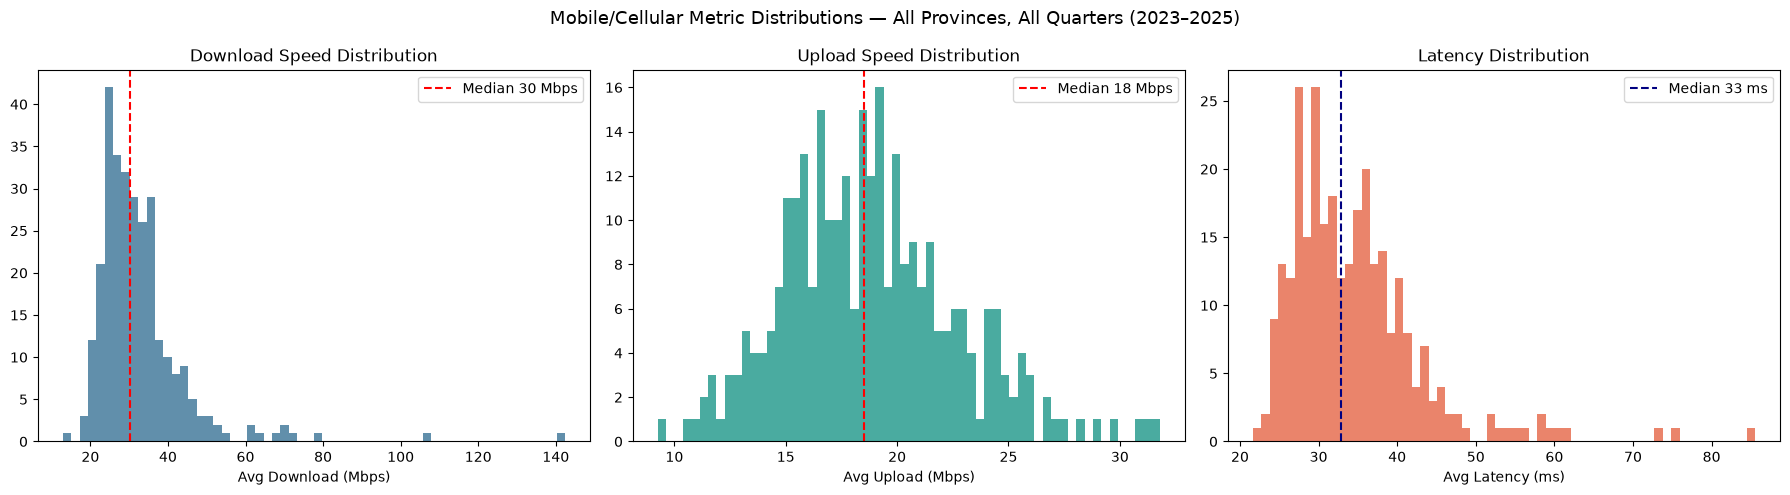

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count      292.00      292.00         292.00       292.00
mean        32.74       18.80          34.55      1798.75
std         12.26        3.90           8.50      3286.90
min         12.90        9.26          21.64       100.00
25%         25.49       15.95          28.83       539.50
50%         30.30       18.49          32.81       923.50
75%         35.77       21.10          38.11      1682.75
max        142.34       31.80          85.51     24888.00


In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

plt.suptitle('Mobile/Cellular Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/mobile/11_upload_speed_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))


### 4. Province Ranking — Mean Download Speed (All Quarters)

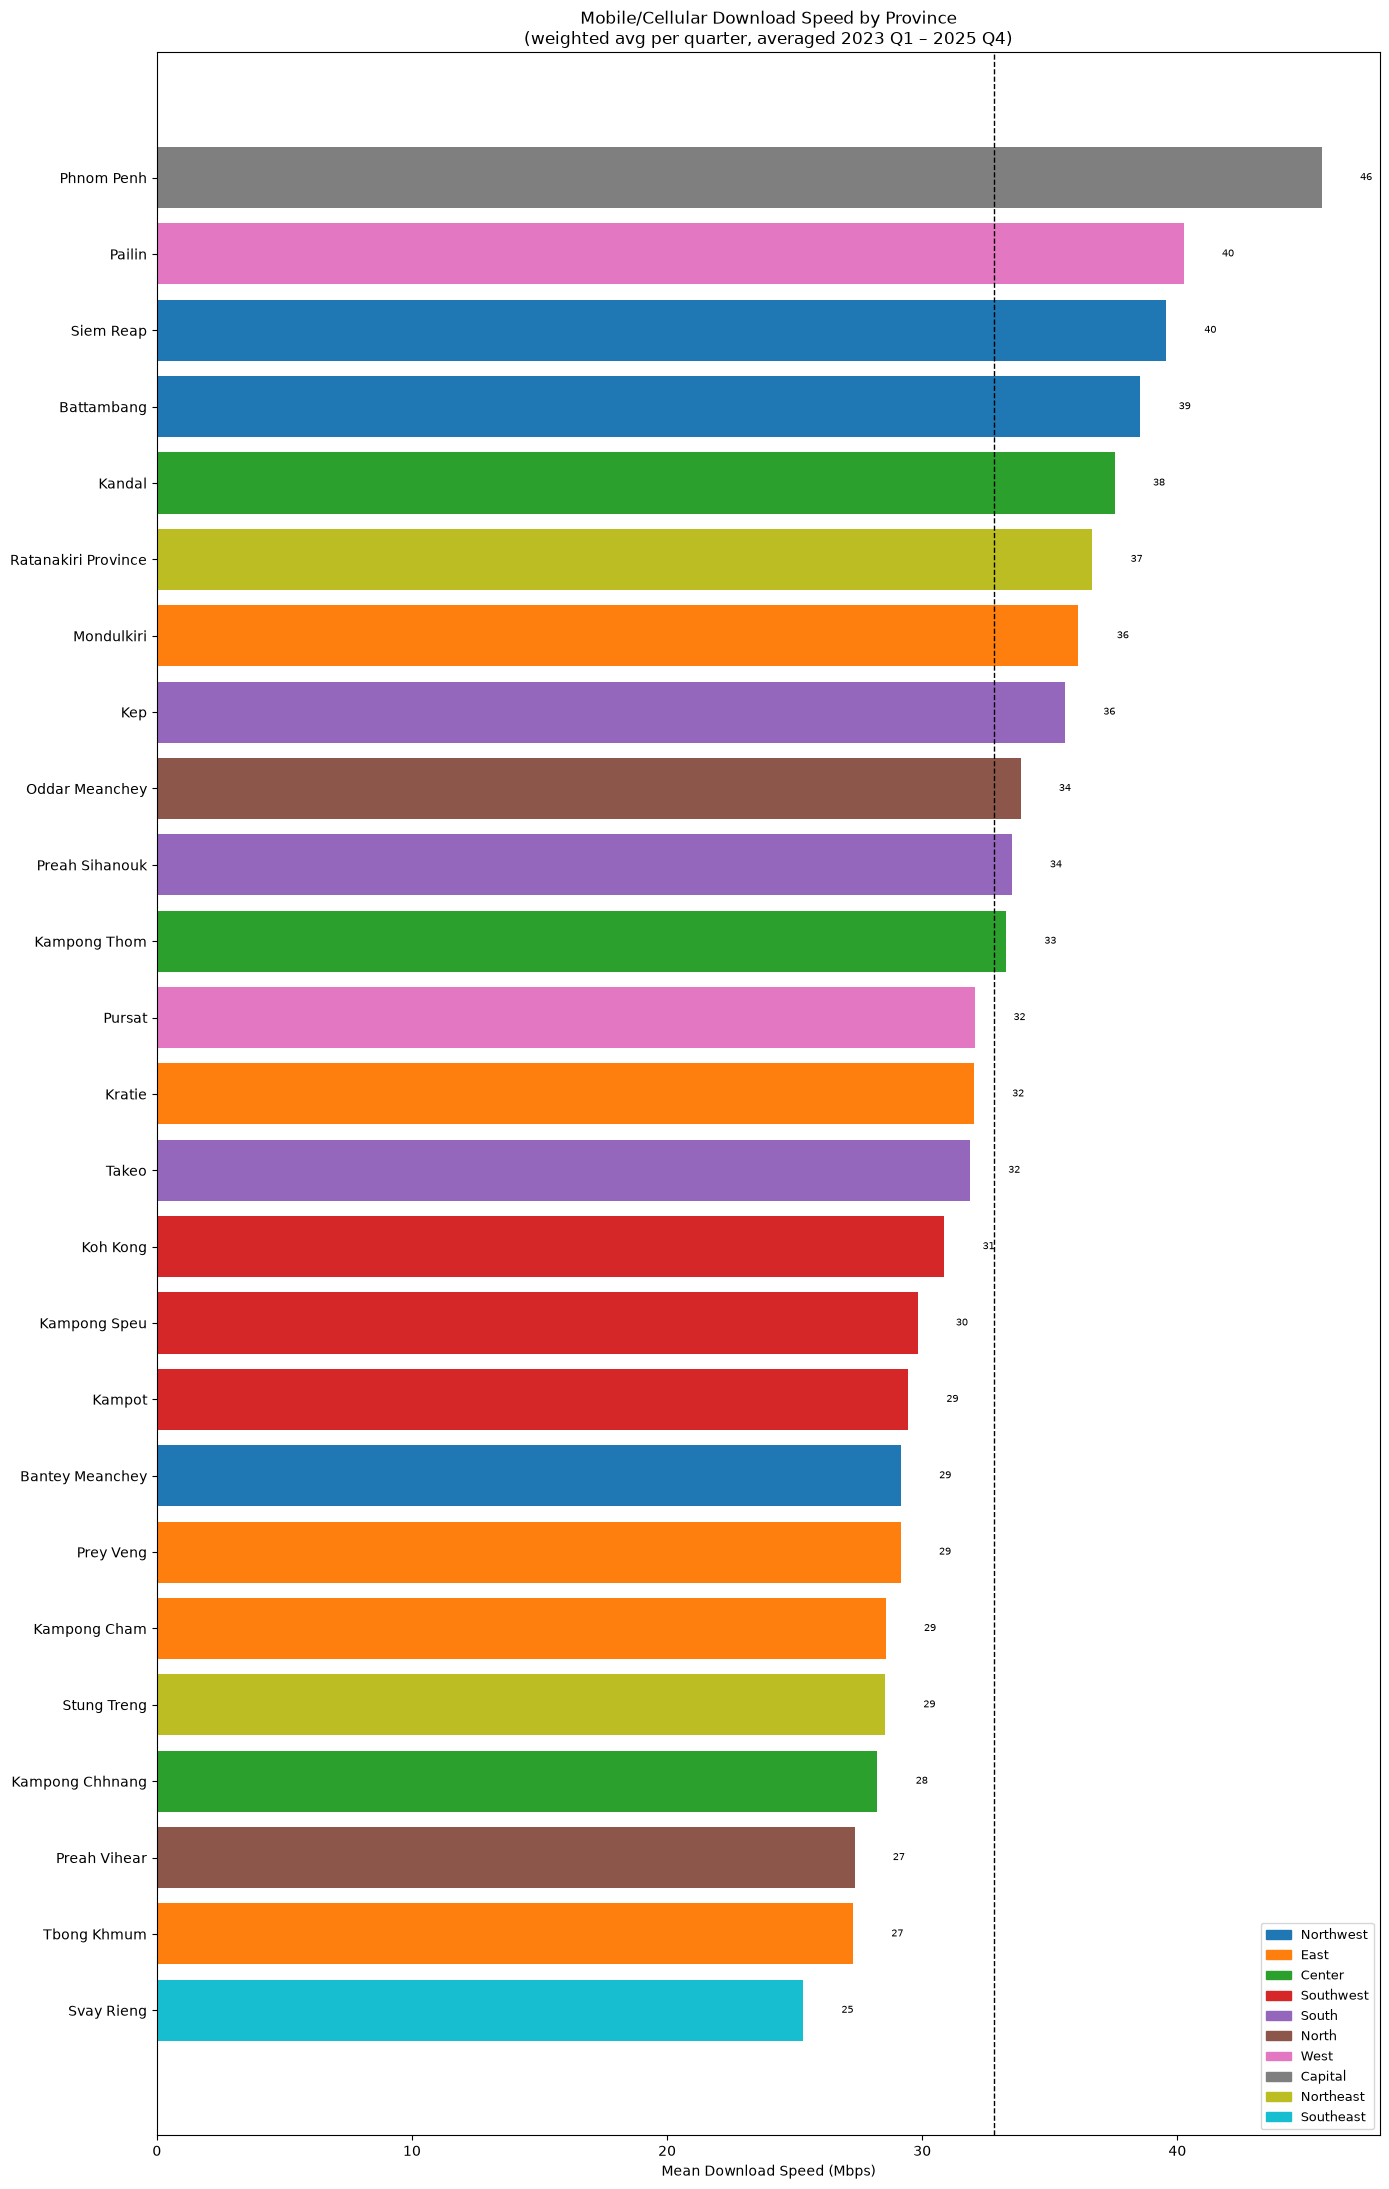

In [53]:
region_colors = {
    'Northwest': '#1f77b4',
    'East': '#ff7f0e',
    'Center': '#2ca02c',
    'Southwest': '#d62728',
    'South': '#9467bd',
    'North': '#8c564b',
    'West': '#e377c2',
    'Capital': '#7f7f7f',
    'Northeast': '#bcbd22',
    'Southeast': '#17becf',
}

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_mean['mean_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('Mean Download Speed (Mbps)')
ax.set_title('Mobile/Cellular Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/mobile/12_province_ranking_mean.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.5 Province Ranking — Median Download Speed (All Quarters)

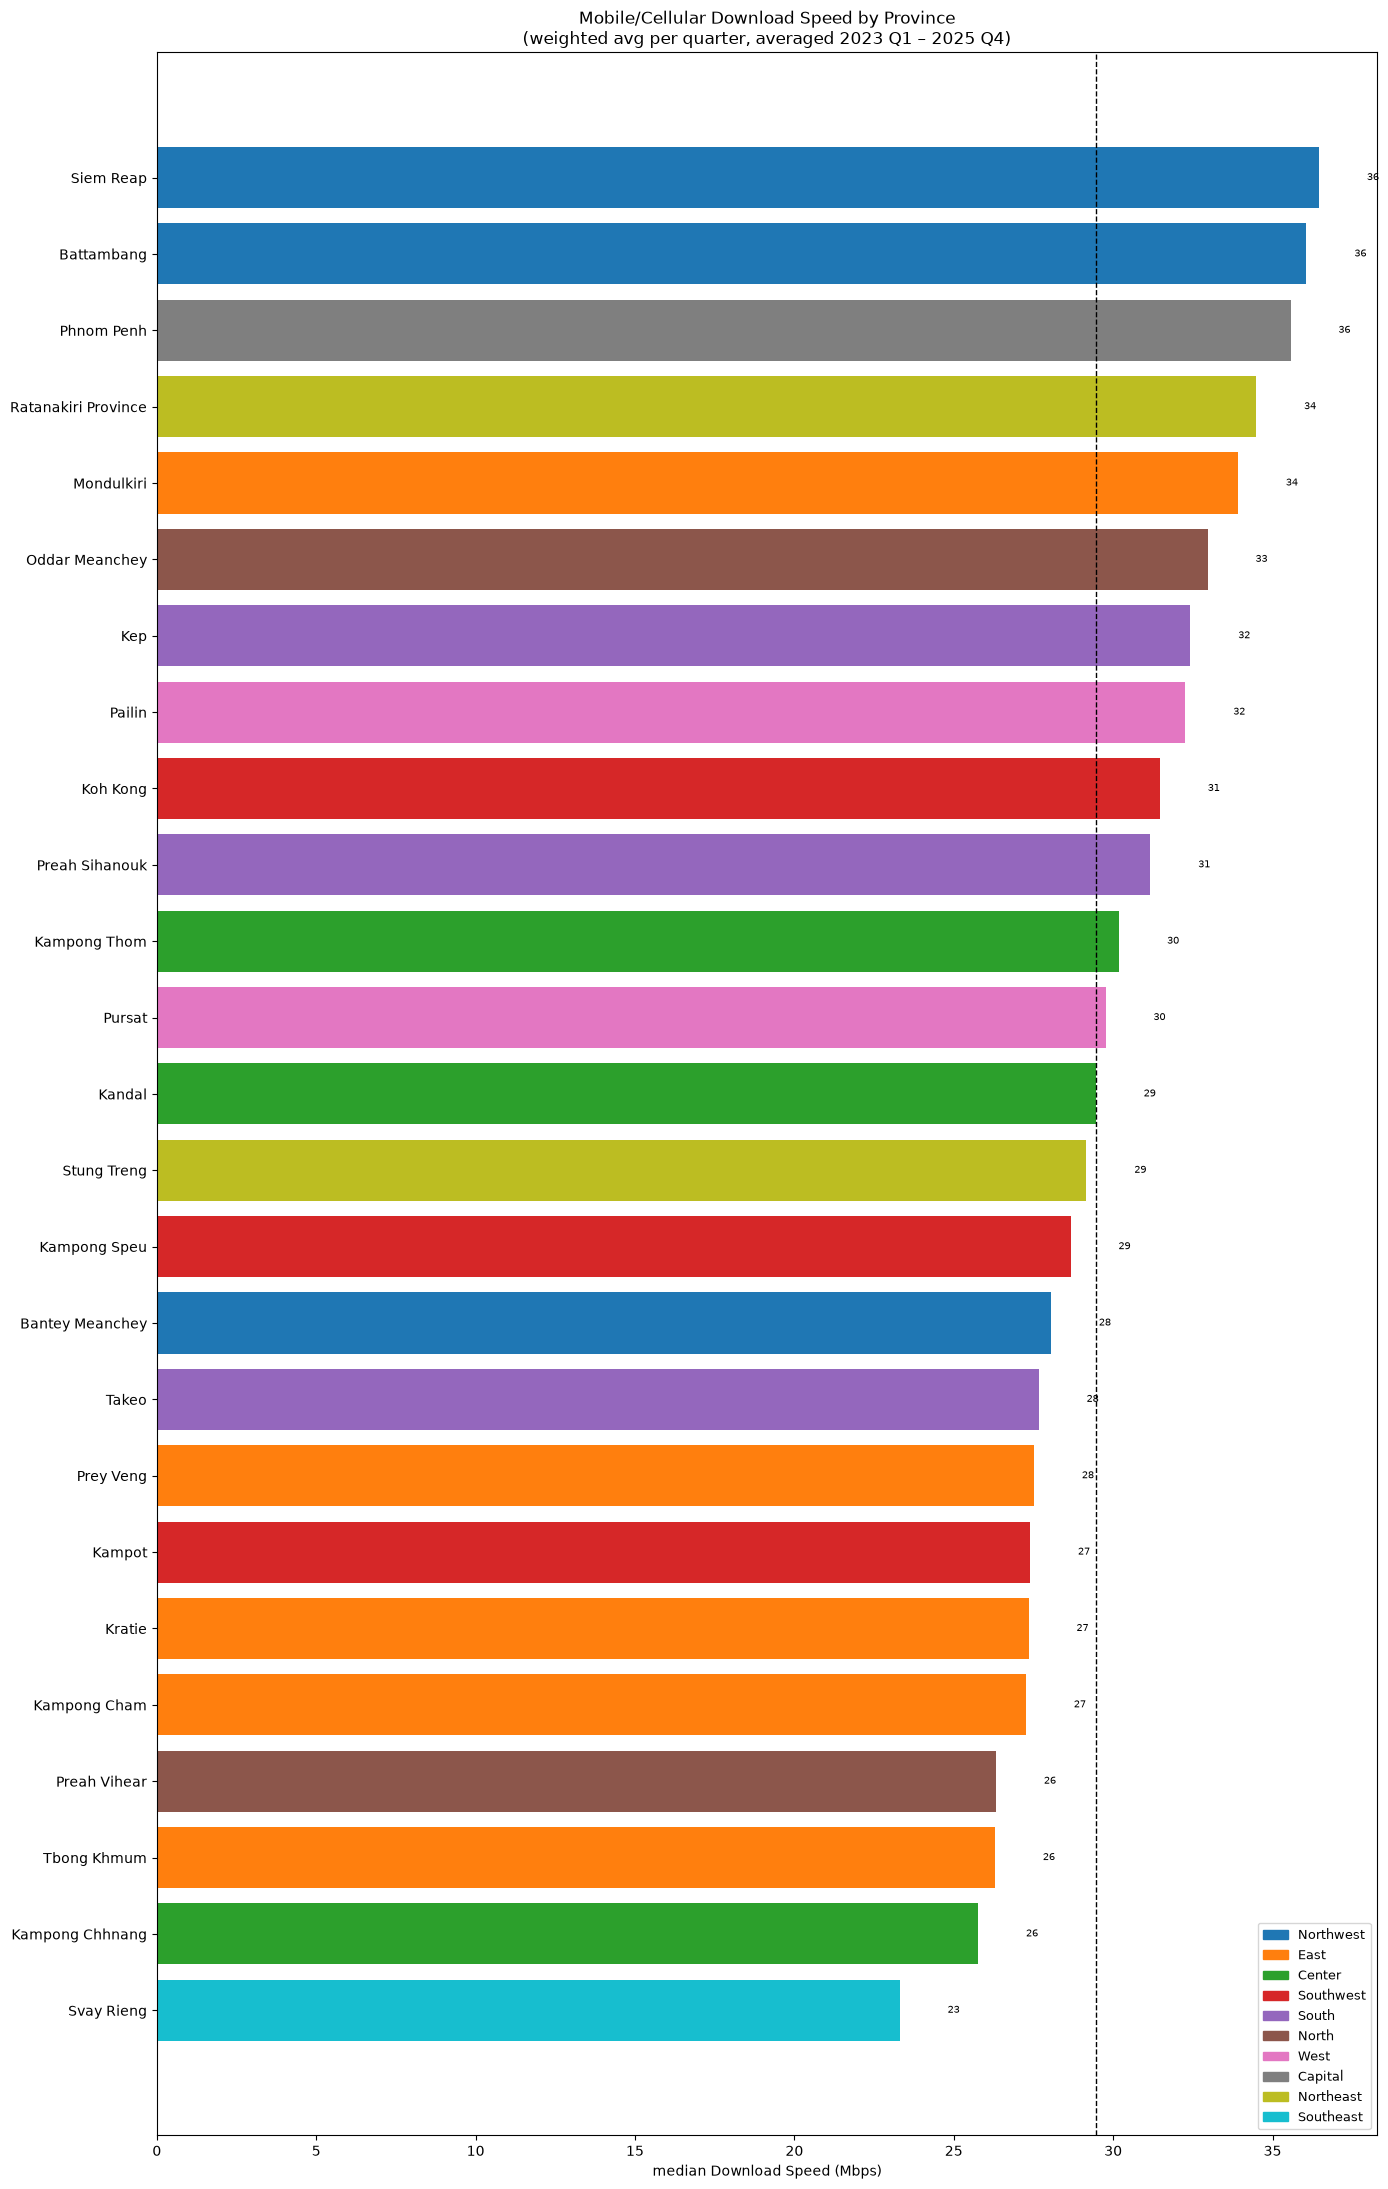

In [54]:
region_colors = {
    'Northwest': '#1f77b4',
    'East': '#ff7f0e',
    'Center': '#2ca02c',
    'Southwest': '#d62728',
    'South': '#9467bd',
    'North': '#8c564b',
    'West': '#e377c2',
    'Capital': '#7f7f7f',
    'Northeast': '#bcbd22',
    'Southeast': '#17becf',
}

prov_median = (
    master.groupby(['name','region'])
    .agg(
        median_dl=('avg_d_mbps','median'),
        median_ul=('avg_u_mbps','median'),
        median_lat=('avg_lat_ms_wt','median'),
        median_tests=('total_tests','median'),
    )
    .reset_index()
    .sort_values('median_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_median['region']]
bars = ax.barh(prov_median['name'], prov_median['median_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_median['median_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_median['median_dl'].median(), color='black', ls='--', lw=1, label=f'National median {prov_median["median_dl"].median():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('median Download Speed (Mbps)')
ax.set_title('Mobile/Cellular Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/mobile/12_province_ranking_median.png', dpi=150, bbox_inches='tight')
plt.show()


### 5. Time Series — Download Speed Heatmap (Province × Quarter)

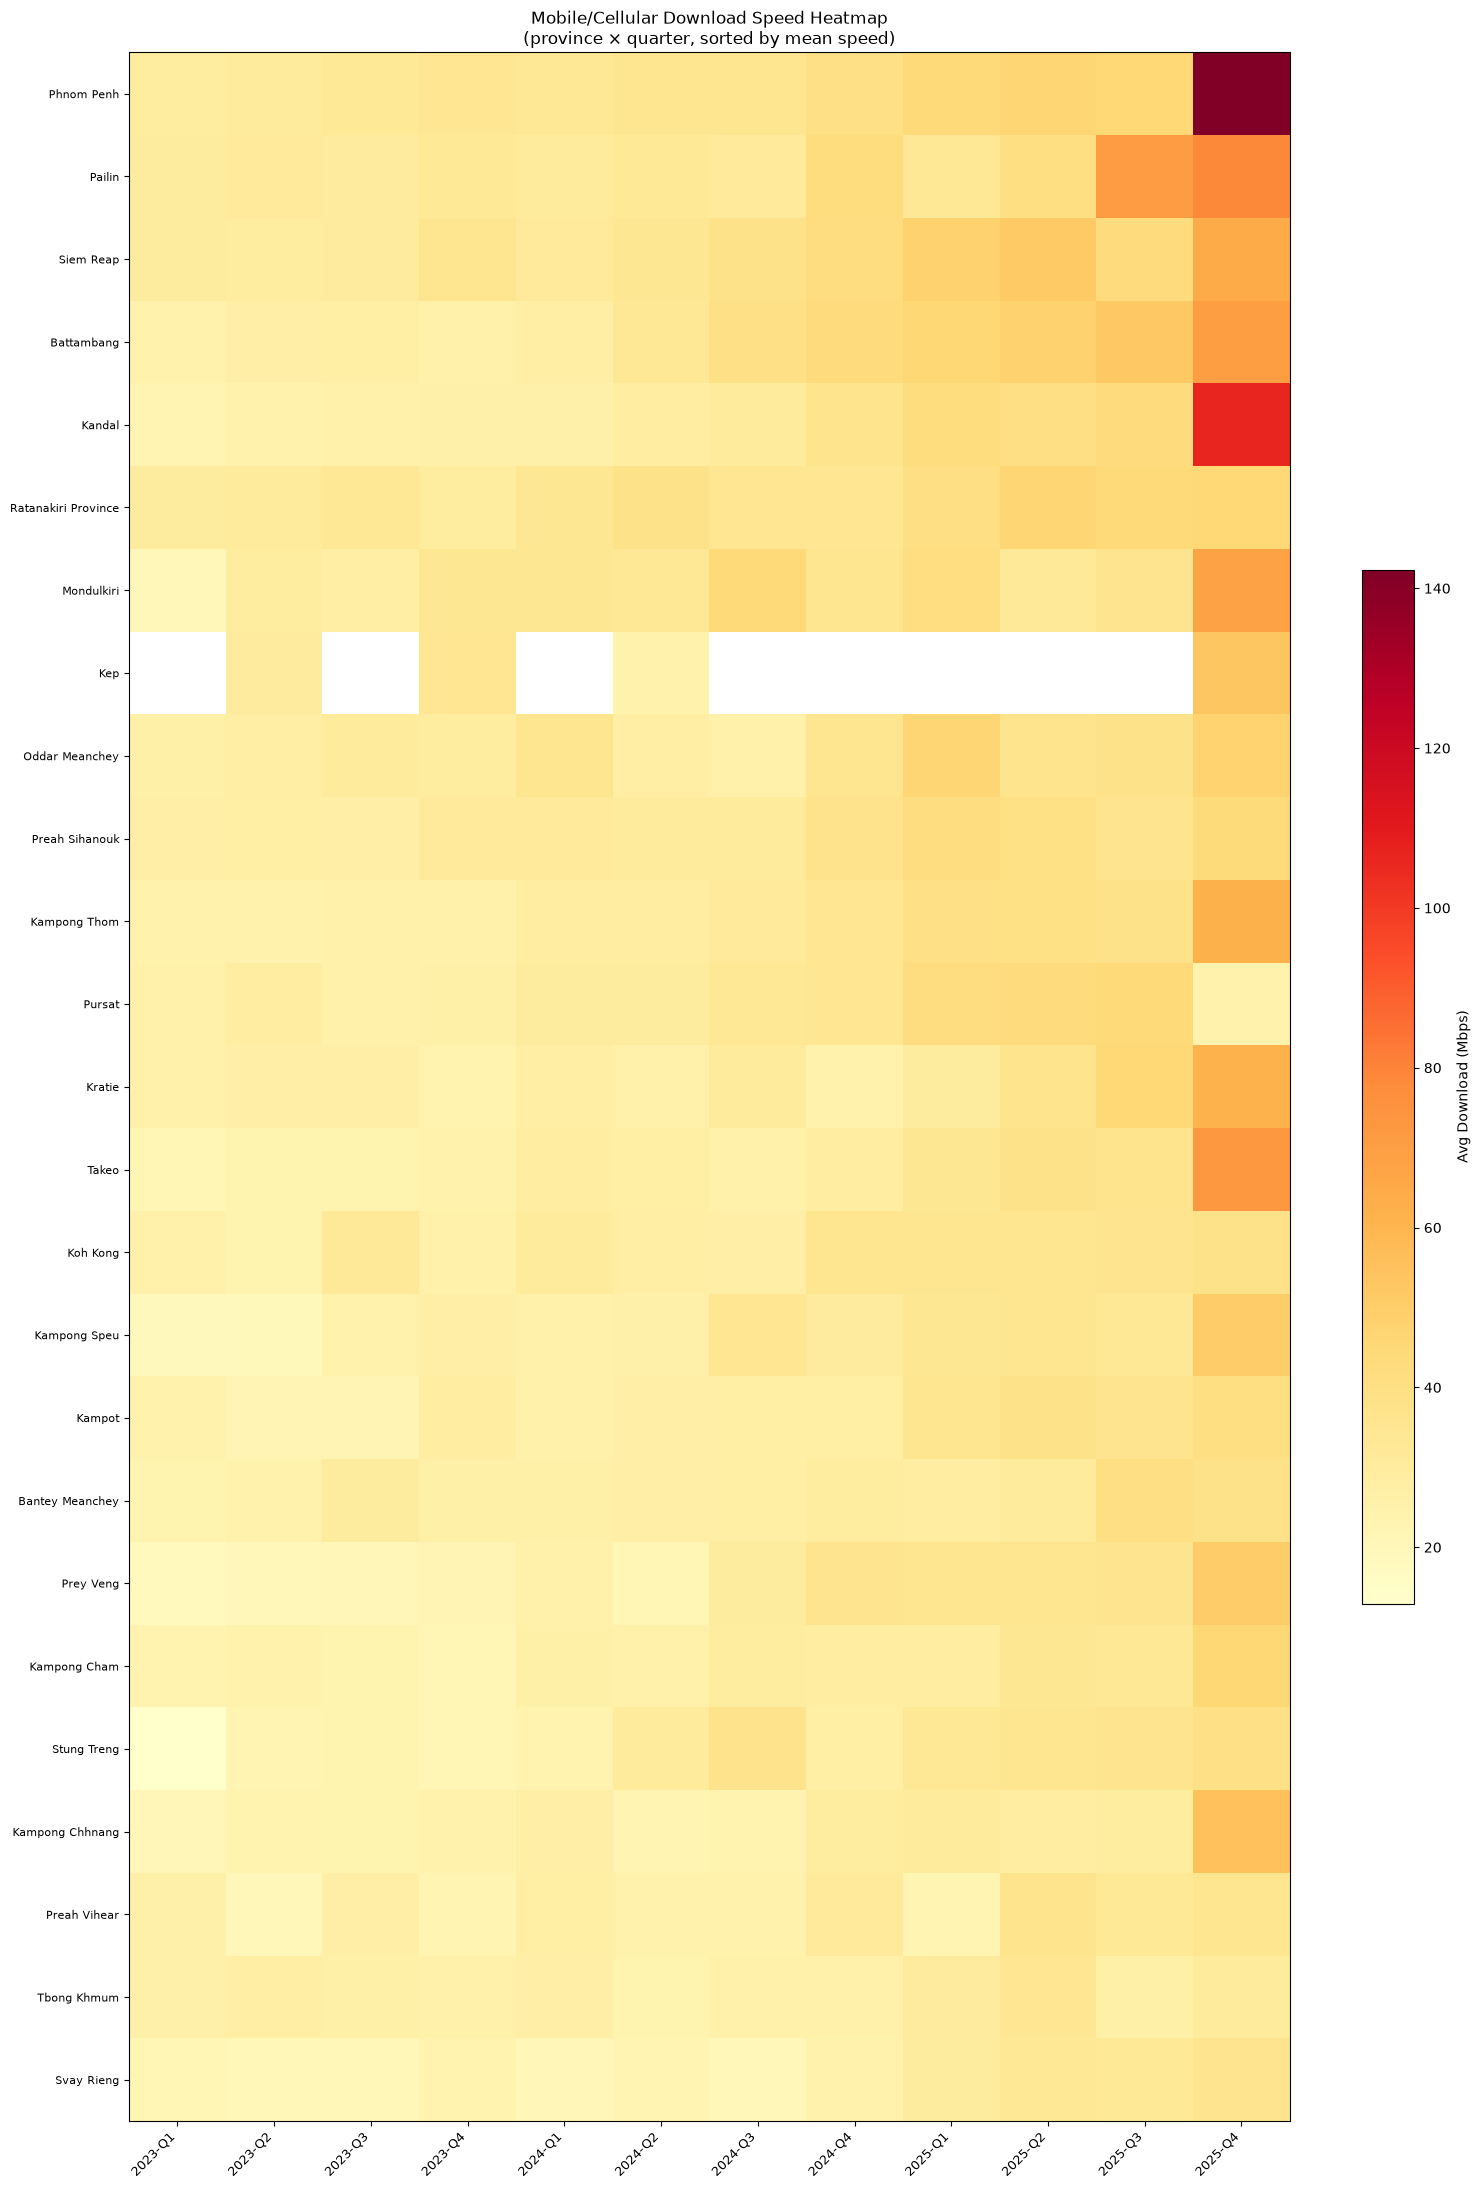

In [55]:
pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
# Format column labels as quarter strings for display
pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
# Sort by mean download speed
pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

fig, ax = plt.subplots(figsize=(16, 22))
im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)

ax.set_xticks(range(len(pivot_dl.columns)))
ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_dl.index)))
ax.set_yticklabels(pivot_dl.index, fontsize=8)
ax.set_title('Mobile/Cellular Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/mobile/13_heatmap_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()


### 6. Regional Comparison — Download, Upload, Latency

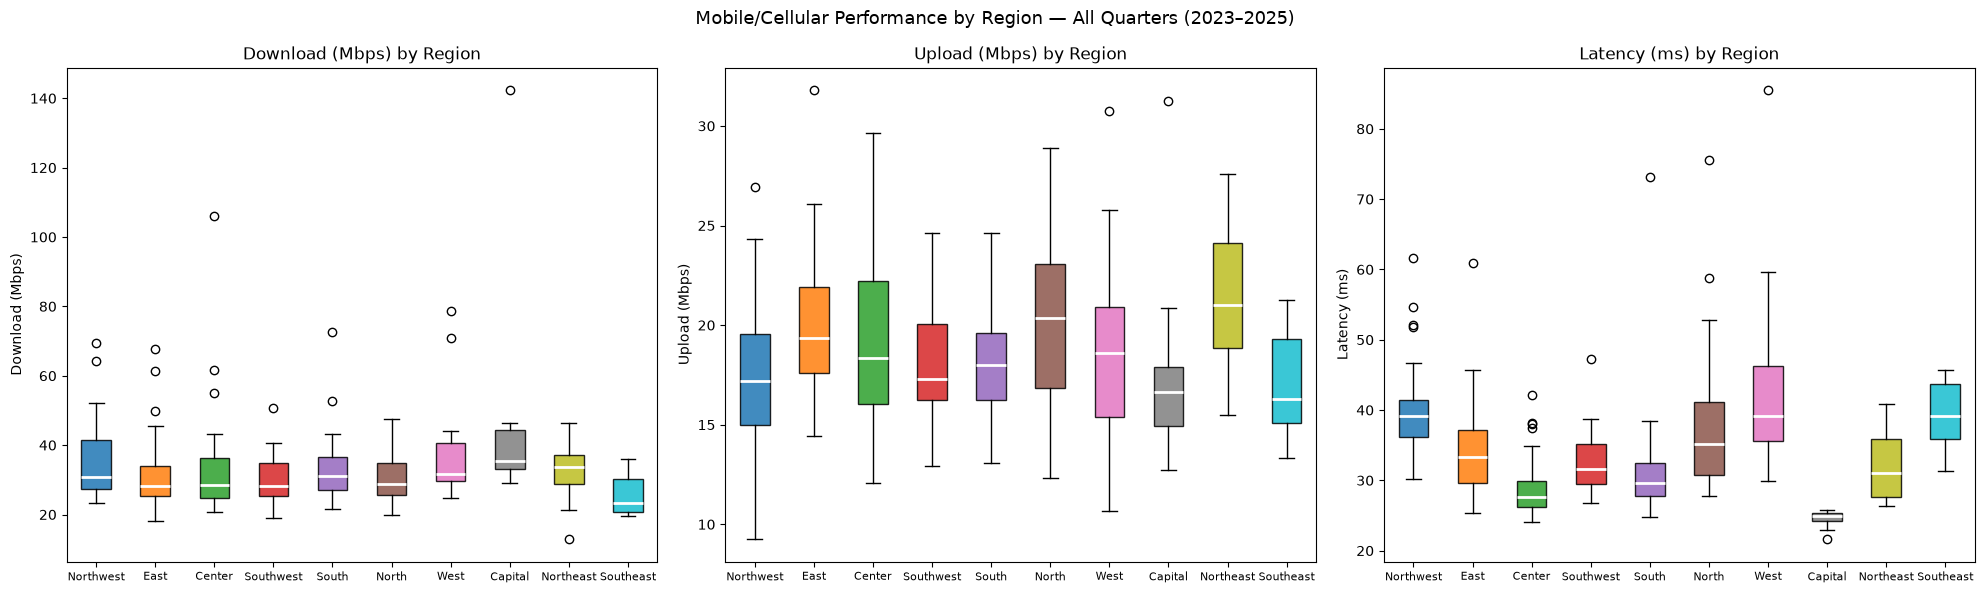

In [56]:
region_order = ['Northwest', 'East', 'Center', 'Southwest', 'South', 'North', 'West', 'Capital', 'Northeast', 'Southeast']
region_data  = [master[master['region']==r]['avg_d_mbps'].dropna().values for r in region_order]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric, label, color_key in [
    (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
    (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
    (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
]:
    data = [master[master['region']==r][metric].dropna().values for r in region_order]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2))
    for patch, region in zip(bp['boxes'], region_order):
        patch.set_facecolor(region_colors[region])
        patch.set_alpha(0.85)
    ax.set_xticklabels([r.replace(' & ',' &\n') for r in region_order], fontsize=8)
    ax.set_ylabel(label)
    ax.set_title(f'{label} by Region')

plt.suptitle('Mobile/Cellular Performance by Region — All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/mobile/14_regional_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

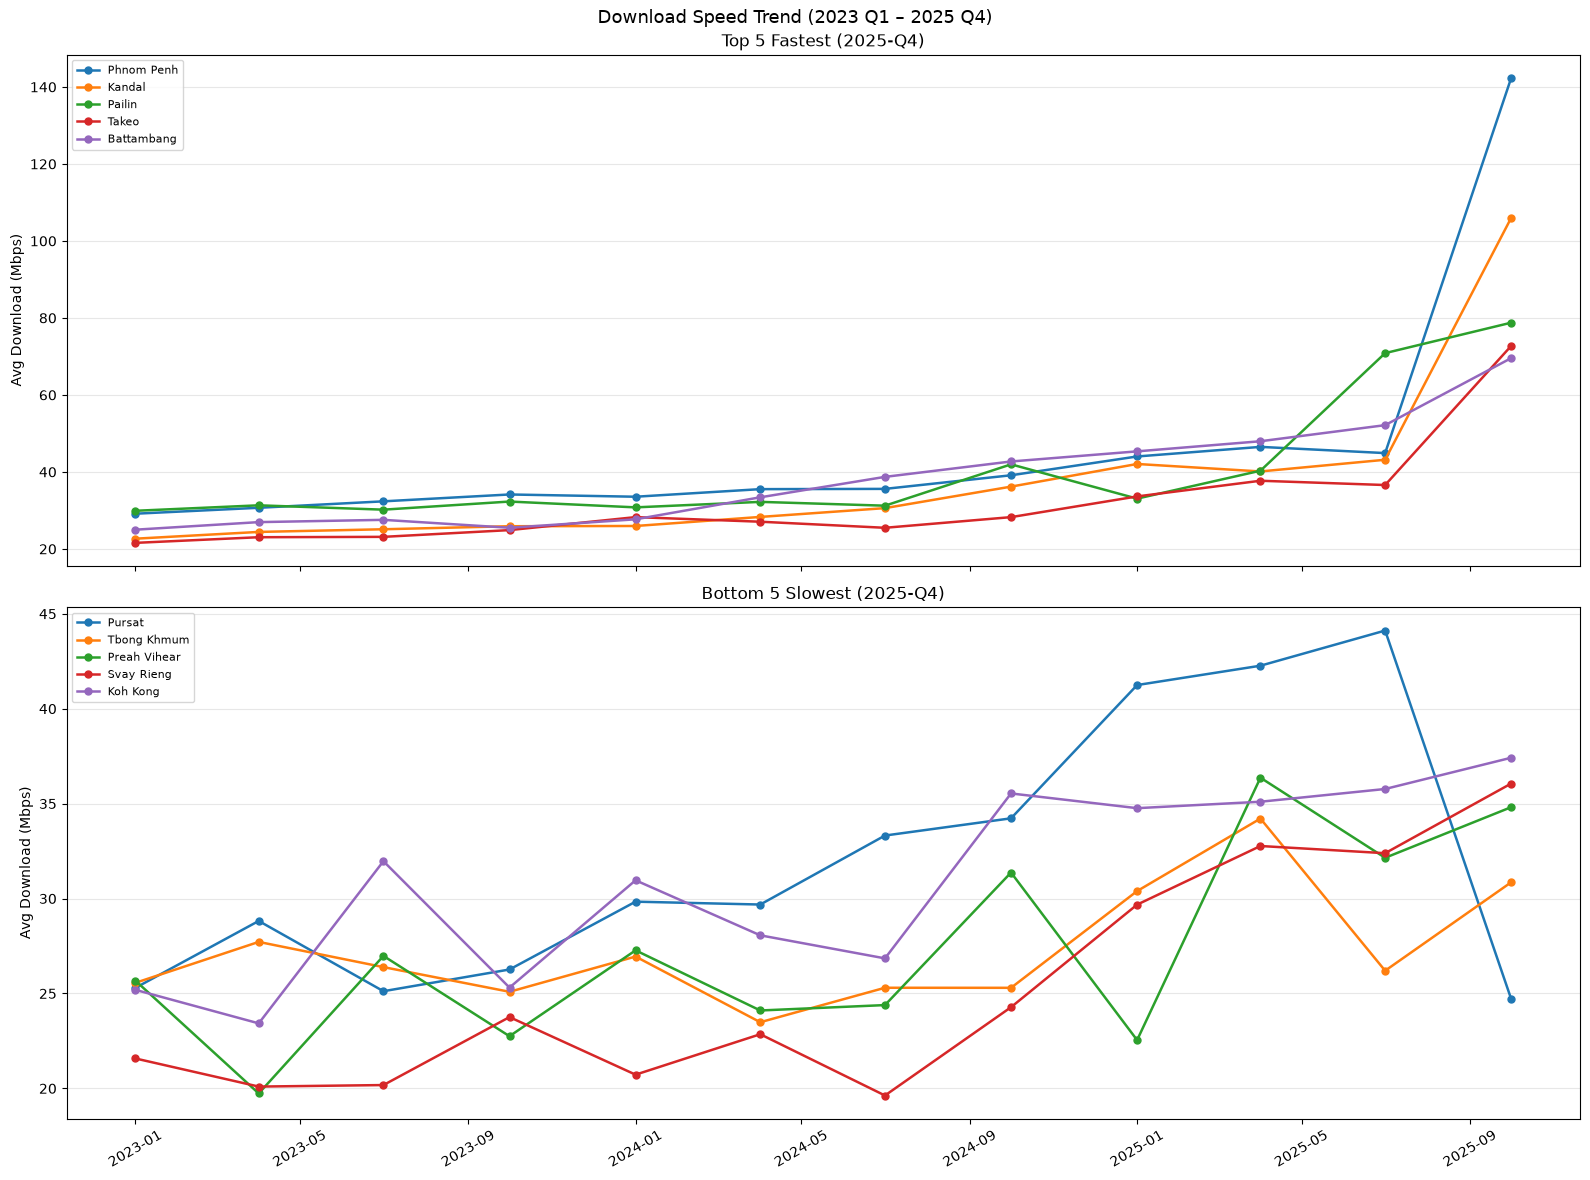

In [57]:
latest_q = master['label'].max()
latest = master[master['label'] == latest_q]
top5 = latest.nlargest(5, 'avg_d_mbps')['name'].tolist()
bot5 = latest.nsmallest(5, 'avg_d_mbps')['name'].tolist()

quarter_order = sorted(master['label'].unique())
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

groups = [
    (f'Top 5 Fastest ({latest_q})', top5, '#e63946'),
    (f'Bottom 5 Slowest ({latest_q})', bot5, '#6d6875'),
]

for ax, (title, provinces, base_color) in zip(axes, groups):
    for i, prov in enumerate(provinces):
        df_p = master[master['name']==prov].sort_values('label')
        if df_p.empty: continue
        ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5,
                label=prov, linewidth=1.8)
    ax.set_ylabel('Avg Download (Mbps)')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/mobile/15_time_series.png', dpi=150, bbox_inches='tight')
plt.show()


### 8. GDP per Capita vs Download Speed — Does Money = Speed?

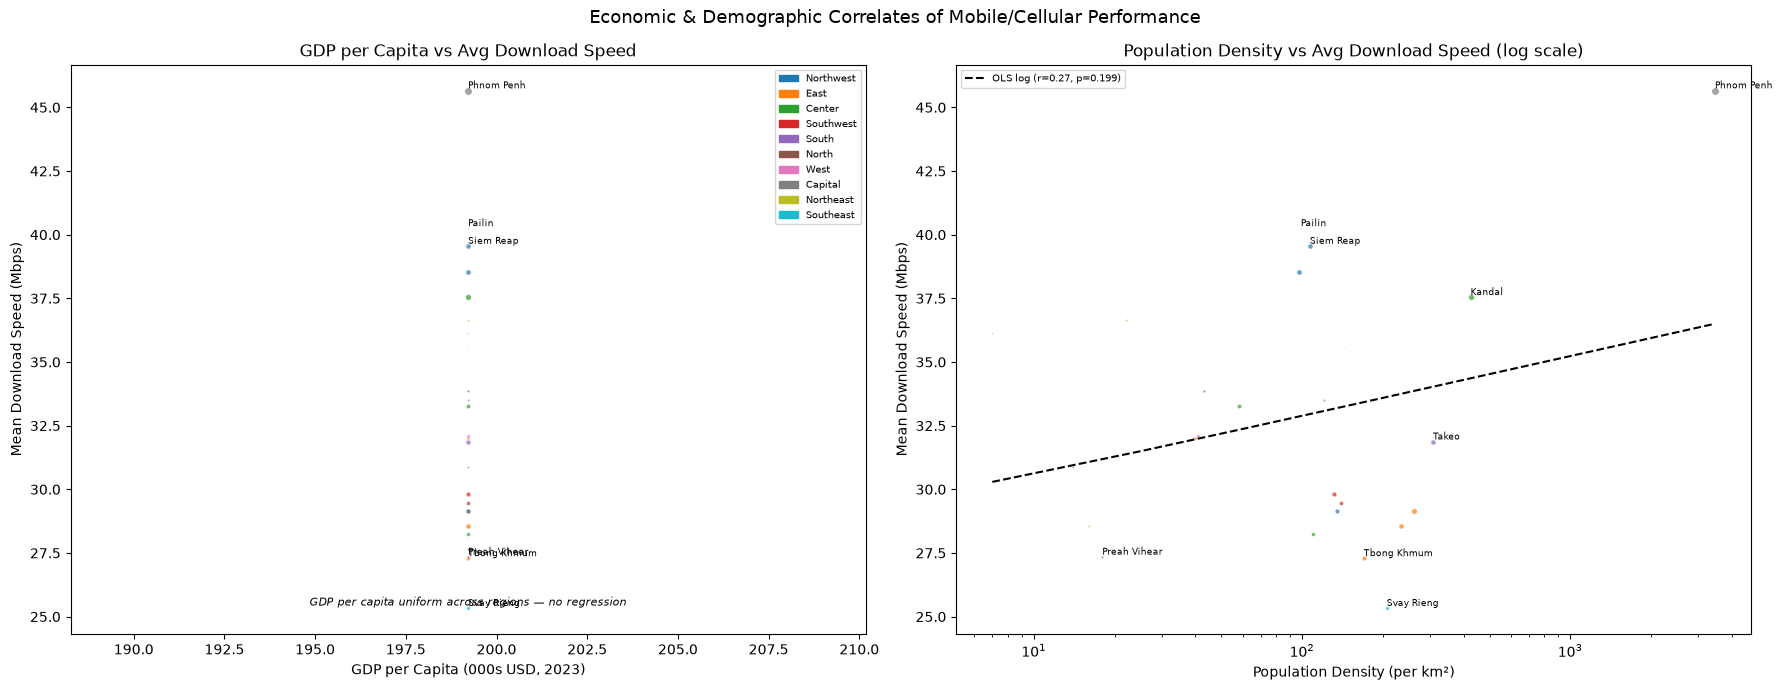

Pearson r (GDP vs download):     nan  p=nan
Pearson r (log density vs download): 0.266  p=0.1988


In [58]:
corr_df = prov_mean.merge(
    prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
    on='name', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter: GDP vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    # Label outliers
    if row['gdp_per_capita_thb_2021'] > corr_df['gdp_per_capita_thb_2021'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

# OLS trendline
x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
y = corr_df.loc[x.index,'mean_dl']
if x.nunique() > 1:
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 100)
    axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
    ols_handle = [plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')]
else:
    r, p = float('nan'), float('nan')
    axes[0].text(0.5, 0.05, 'GDP per capita uniform across regions — no regression', transform=axes[0].transAxes, ha='center', fontsize=8, style='italic')
    ols_handle = []
axes[0].set_xlabel('GDP per Capita (000s USD, 2023)')
axes[0].set_ylabel('Mean Download Speed (Mbps)')
axes[0].set_title('GDP per Capita vs Avg Download Speed')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches+ols_handle, fontsize=7)

# Scatter: density vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'],'gray')
    axes[1].scatter(row['density_per_km2'], row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    if row['density_per_km2'] > corr_df['density_per_km2'].quantile(0.9) or row['mean_dl'] > corr_df['mean_dl'].quantile(0.9) or row['mean_dl'] < corr_df['mean_dl'].quantile(0.1):
        axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

x2 = corr_df['density_per_km2'].dropna()
y2 = corr_df.loc[x2.index,'mean_dl']
s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
xline2 = np.linspace(x2.min(), x2.max(), 200)
axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
axes[1].set_xlabel('Population Density (per km²)')
axes[1].set_xscale('log')
axes[1].set_ylabel('Mean Download Speed (Mbps)')
axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
axes[1].legend(fontsize=7)

plt.suptitle('Economic & Demographic Correlates of Mobile/Cellular Performance', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/mobile/16_gdp_speed_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")


NDT per tile , facebook , spilt , 

### 9. Upload/Download Ratio — Symmetry Check

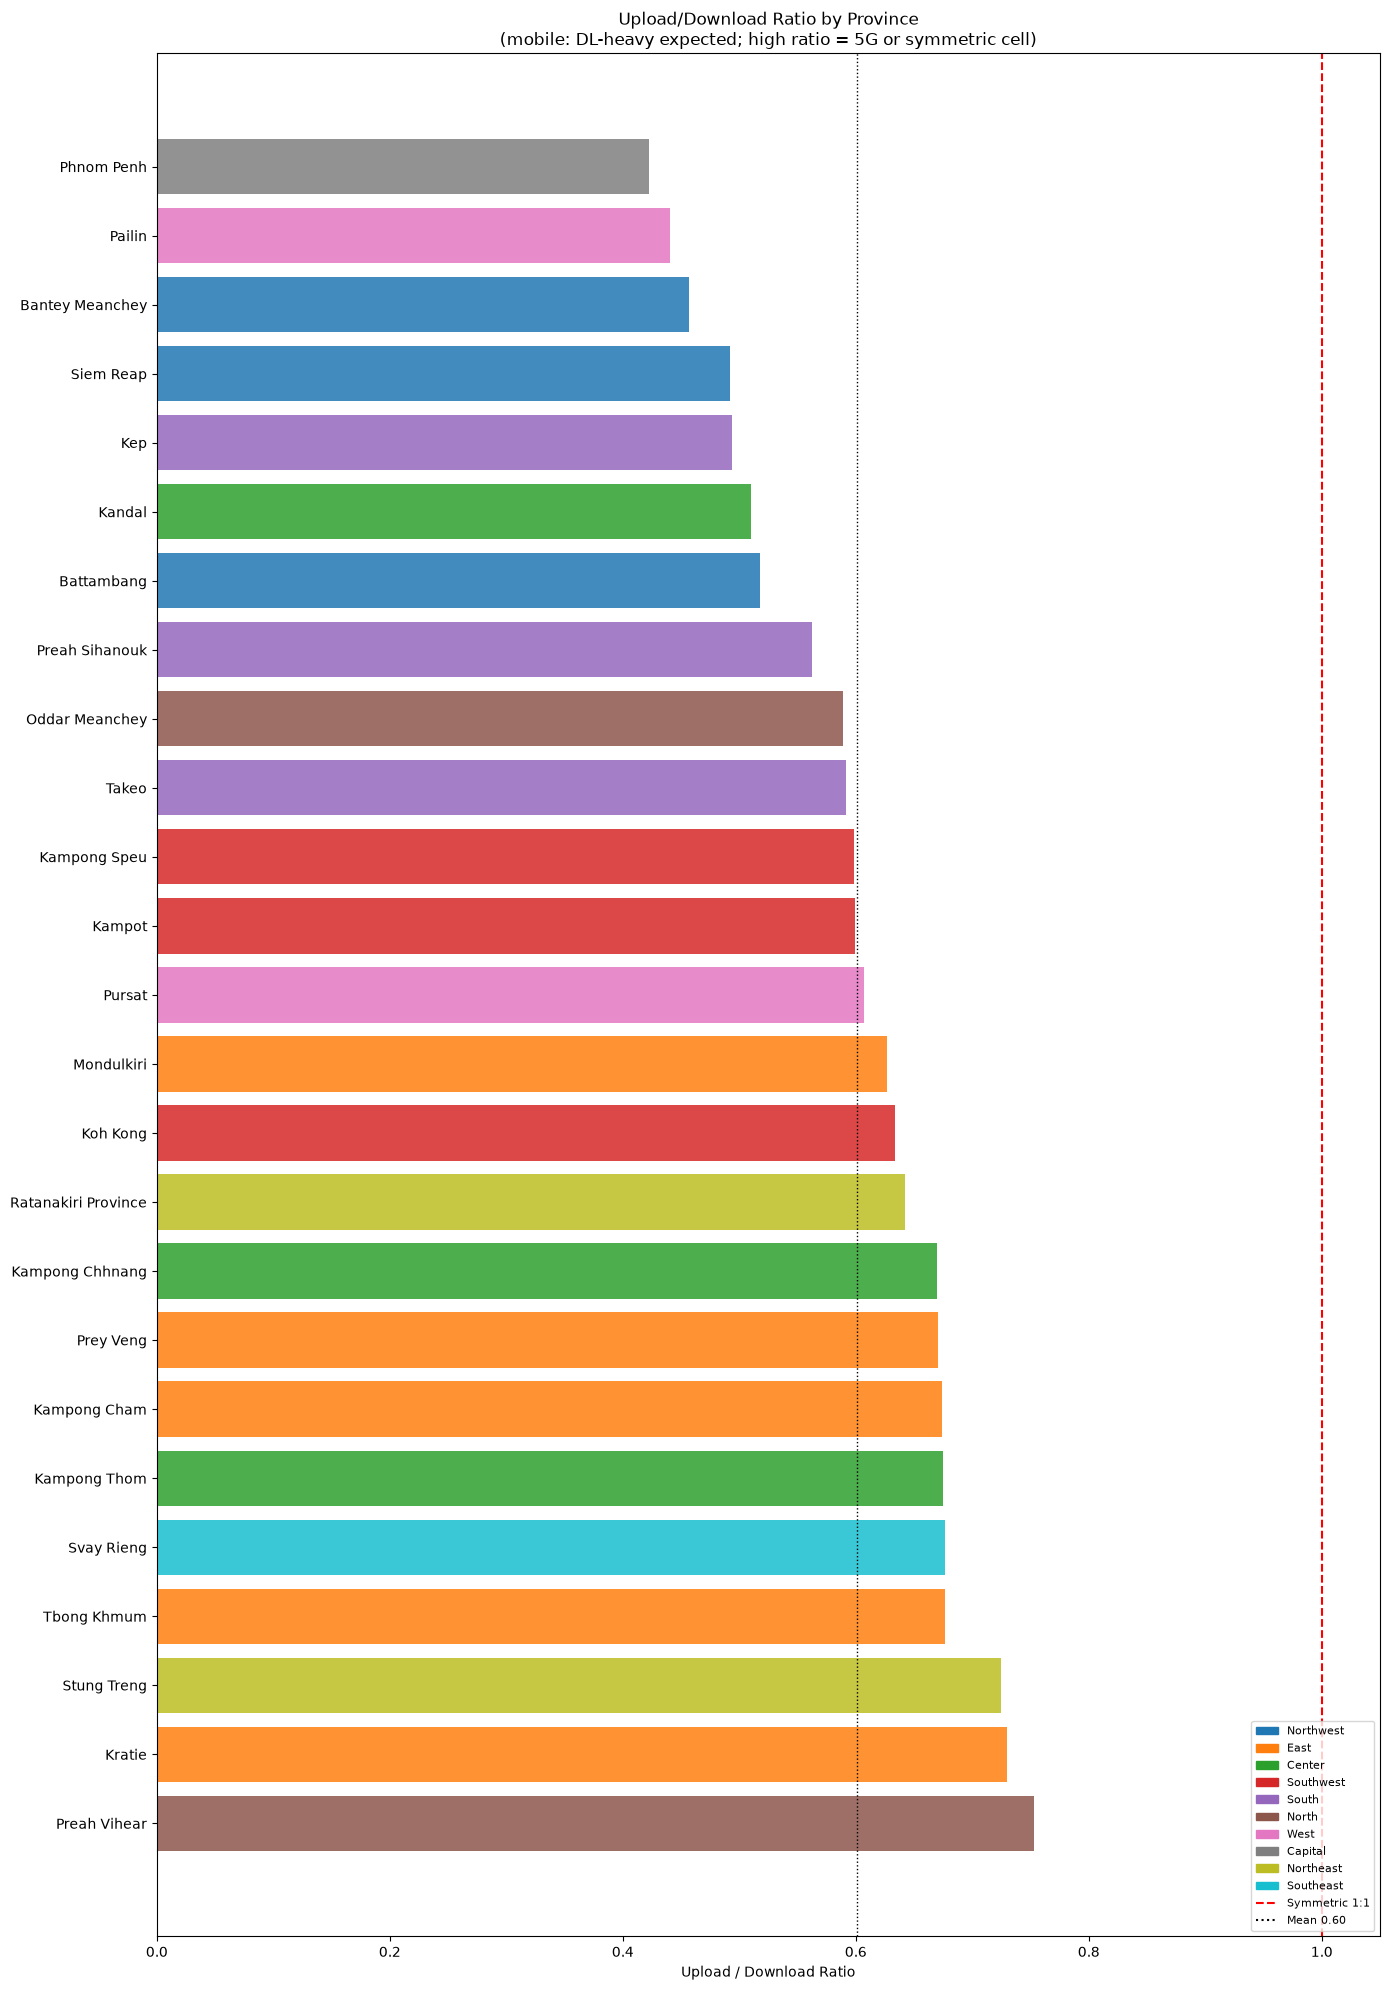

Provinces with UL/DL ratio > 0.5 (20):
               name    region  ul_dl_ratio
       Preah Vihear     North     0.752950
             Kratie      East     0.729749
        Stung Treng Northeast     0.724488
        Tbong Khmum      East     0.676552
         Svay Rieng Southeast     0.676344
       Kampong Thom    Center     0.674876
       Kampong Cham      East     0.674093
          Prey Veng      East     0.670247
    Kampong Chhnang    Center     0.669797
Ratanakiri Province Northeast     0.642532
           Koh Kong Southwest     0.633557
         Mondulkiri      East     0.626886
             Pursat      West     0.606773
             Kampot Southwest     0.599618
       Kampong Speu Southwest     0.598244
              Takeo     South     0.591740
     Oddar Meanchey     North     0.589152
     Preah Sihanouk     South     0.562184
         Battambang Northwest     0.517843
             Kandal    Center     0.509944


In [59]:
master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']

ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
ax.set_xlabel('Upload / Download Ratio')
ax.set_title('Upload/Download Ratio by Province\n(mobile: DL-heavy expected; high ratio = 5G or symmetric cell)')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[
    plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
    plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
], fontsize=8, loc='lower right')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/mobile/17_uldl_ratio_bar.png', dpi=150, bbox_inches='tight')
plt.show()

divergent_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.5]
print(f"Provinces with UL/DL ratio > 0.5 ({len(divergent_ratio)}):")
print(divergent_ratio[['name','region','ul_dl_ratio']].to_string(index=False))


### 10. Anomaly Detection — Province Flags

In [60]:
# === ANOMALY DETECTION (recalibrated from actual data) ===
# National mean UL/DL ratio = 0.852 → flag only clear outliers (z-score based)
# Tier medians are compressed: T1=282, T2=247, T3=246, T4=229 Mbps
# Thresholds set based on observed distributions

from scipy import stats
import numpy as np

master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
        mean_ratio=('ul_dl_ratio','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=False)
)
prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

tier_speed   = prov_mean.groupby('tier')['mean_dl'].median()
national_std = prov_mean['mean_dl'].std()


# infastructure mod

### 12. Full Province Summary Table

In [61]:
summary = prov_mean.merge(
    prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
    on='name', how='left'
).copy()

summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
summary = summary.sort_values('mean_dl', ascending=False).round(2)

print(summary[[
    'name','region','internet_tier',
    'mean_dl','mean_ul','mean_lat',
    'ul_dl_ratio','mean_tests',
    'gdp_per_capita_thb_2021'
]].to_string(index=False))

               name    region  internet_tier  mean_dl  mean_ul  mean_lat  ul_dl_ratio  mean_tests  gdp_per_capita_thb_2021
         Phnom Penh   Capital              1    45.66    17.45     24.49         0.42    16777.42                199216.96
             Pailin      West              2    40.25    17.41     47.53         0.44      395.92                199216.96
          Siem Reap Northwest              1    39.55    18.83     35.83         0.49     2657.33                199216.96
         Battambang Northwest              2    38.55    19.01     41.01         0.52     1954.33                199216.96
             Kandal    Center              2    37.54    17.35     29.59         0.51     2786.08                199216.96
Ratanakiri Province Northeast              4    36.66    23.19     34.89         0.64      535.17                199216.96
         Mondulkiri      East              4    36.12    21.25     38.31         0.63      394.92                199216.96
                

### 13. UL/DL Symmetry — Mobile Network Quality Indicator

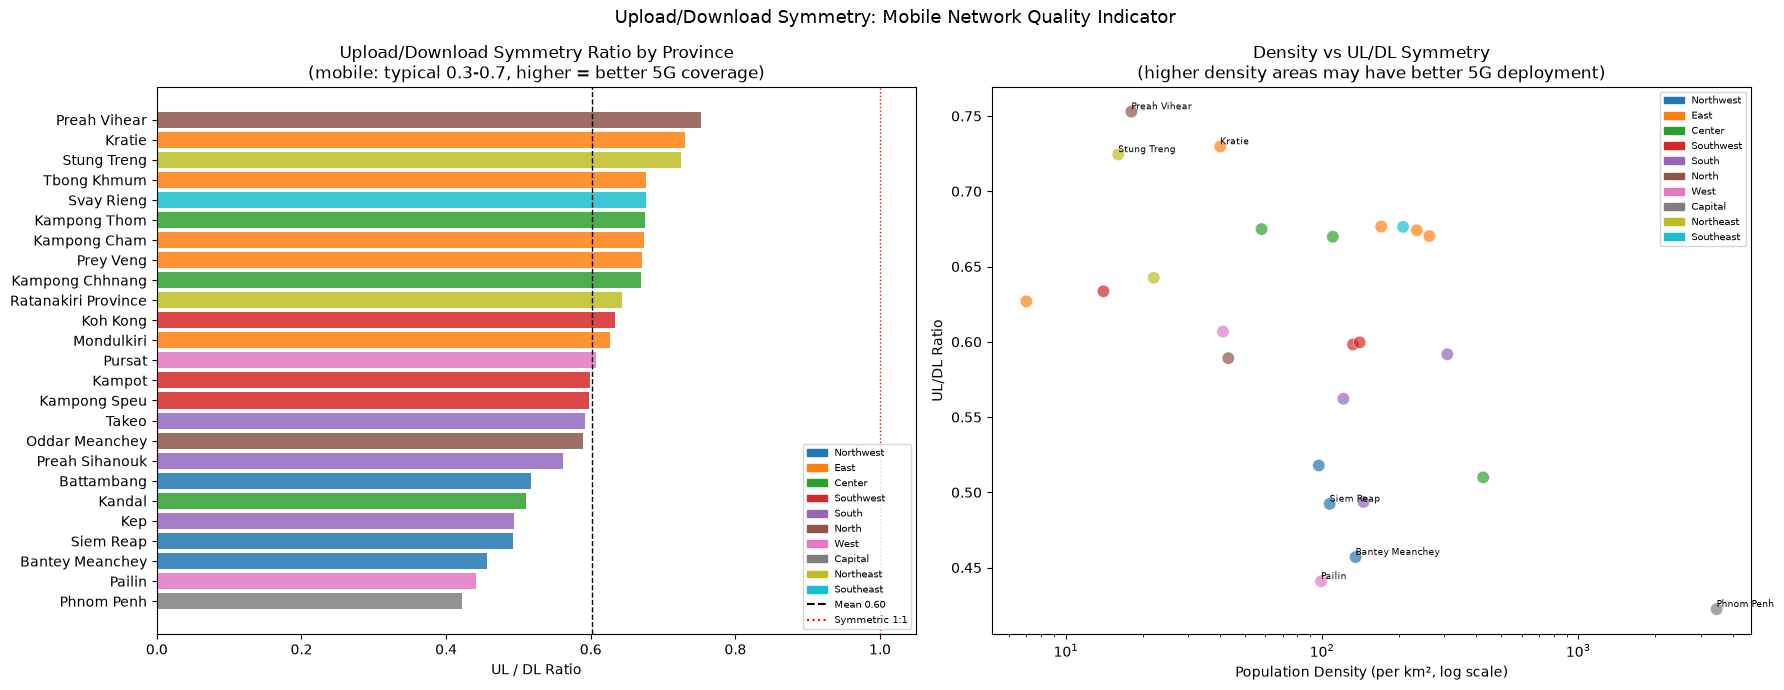

Provinces ratio > 0.5 (relatively symmetric mobile): 20 out of 25
Northwest mean ratio: 0.489
Northwest mean ratio: 0.489


In [62]:
# Mobile UL/DL ratio: typically 0.3-0.7 (DL-heavy by design)
# 5G NR can be more symmetric; high ratio may indicate 5G coverage

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1,
                label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
axes[0].set_xlabel('UL / DL Ratio')
axes[0].set_title('Upload/Download Symmetry Ratio by Province\n(mobile: typical 0.3-0.7, higher = better 5G coverage)')
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches + [
    plt.Line2D([0],[0],color='black',ls='--',label=f'Mean {prov_mean["mean_ratio"].mean():.2f}'),
    plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
], fontsize=7, loc='lower right')

axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                prov_mean['mean_ratio'].values,
                c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                s=80, alpha=0.7, edgecolors='white', lw=0.5)
for _, row in prov_mean.iterrows():
    if row['mean_ratio'] > prov_mean['mean_ratio'].quantile(0.9) or row['mean_ratio'] < prov_mean['mean_ratio'].quantile(0.1) or row['mean_dl'] > prov_mean['mean_dl'].quantile(0.9):
        density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
        if len(density):
            axes[1].annotate(row['name'], (density[0], row['mean_ratio']),
                             fontsize=6.5, ha='left', va='bottom')
axes[1].set_xscale('log')
axes[1].set_xlabel('Population Density (per km², log scale)')
axes[1].set_ylabel('UL/DL Ratio')
axes[1].set_title('Density vs UL/DL Symmetry\n(higher density areas may have better 5G deployment)')
axes[1].legend(handles=patches, fontsize=7)

plt.suptitle('Upload/Download Symmetry: Mobile Network Quality Indicator', fontsize=13)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/mobile/19_uldl_symmetry_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

_top_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmax(), 'region']
_bot_region = prov_ref.loc[prov_ref['gdp_per_capita_thb_2021'].idxmin(), 'region']
print(f"Provinces ratio > 0.5 (relatively symmetric mobile): {(prov_mean['mean_ratio'] > 0.5).sum()} out of {len(prov_mean)}")
print(f"{_top_region} mean ratio: {prov_mean[prov_mean['region']==_top_region]['mean_ratio'].mean():.3f}")
print(f"{_bot_region} mean ratio: {prov_mean[prov_mean['region']==_bot_region]['mean_ratio'].mean():.3f}")


### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

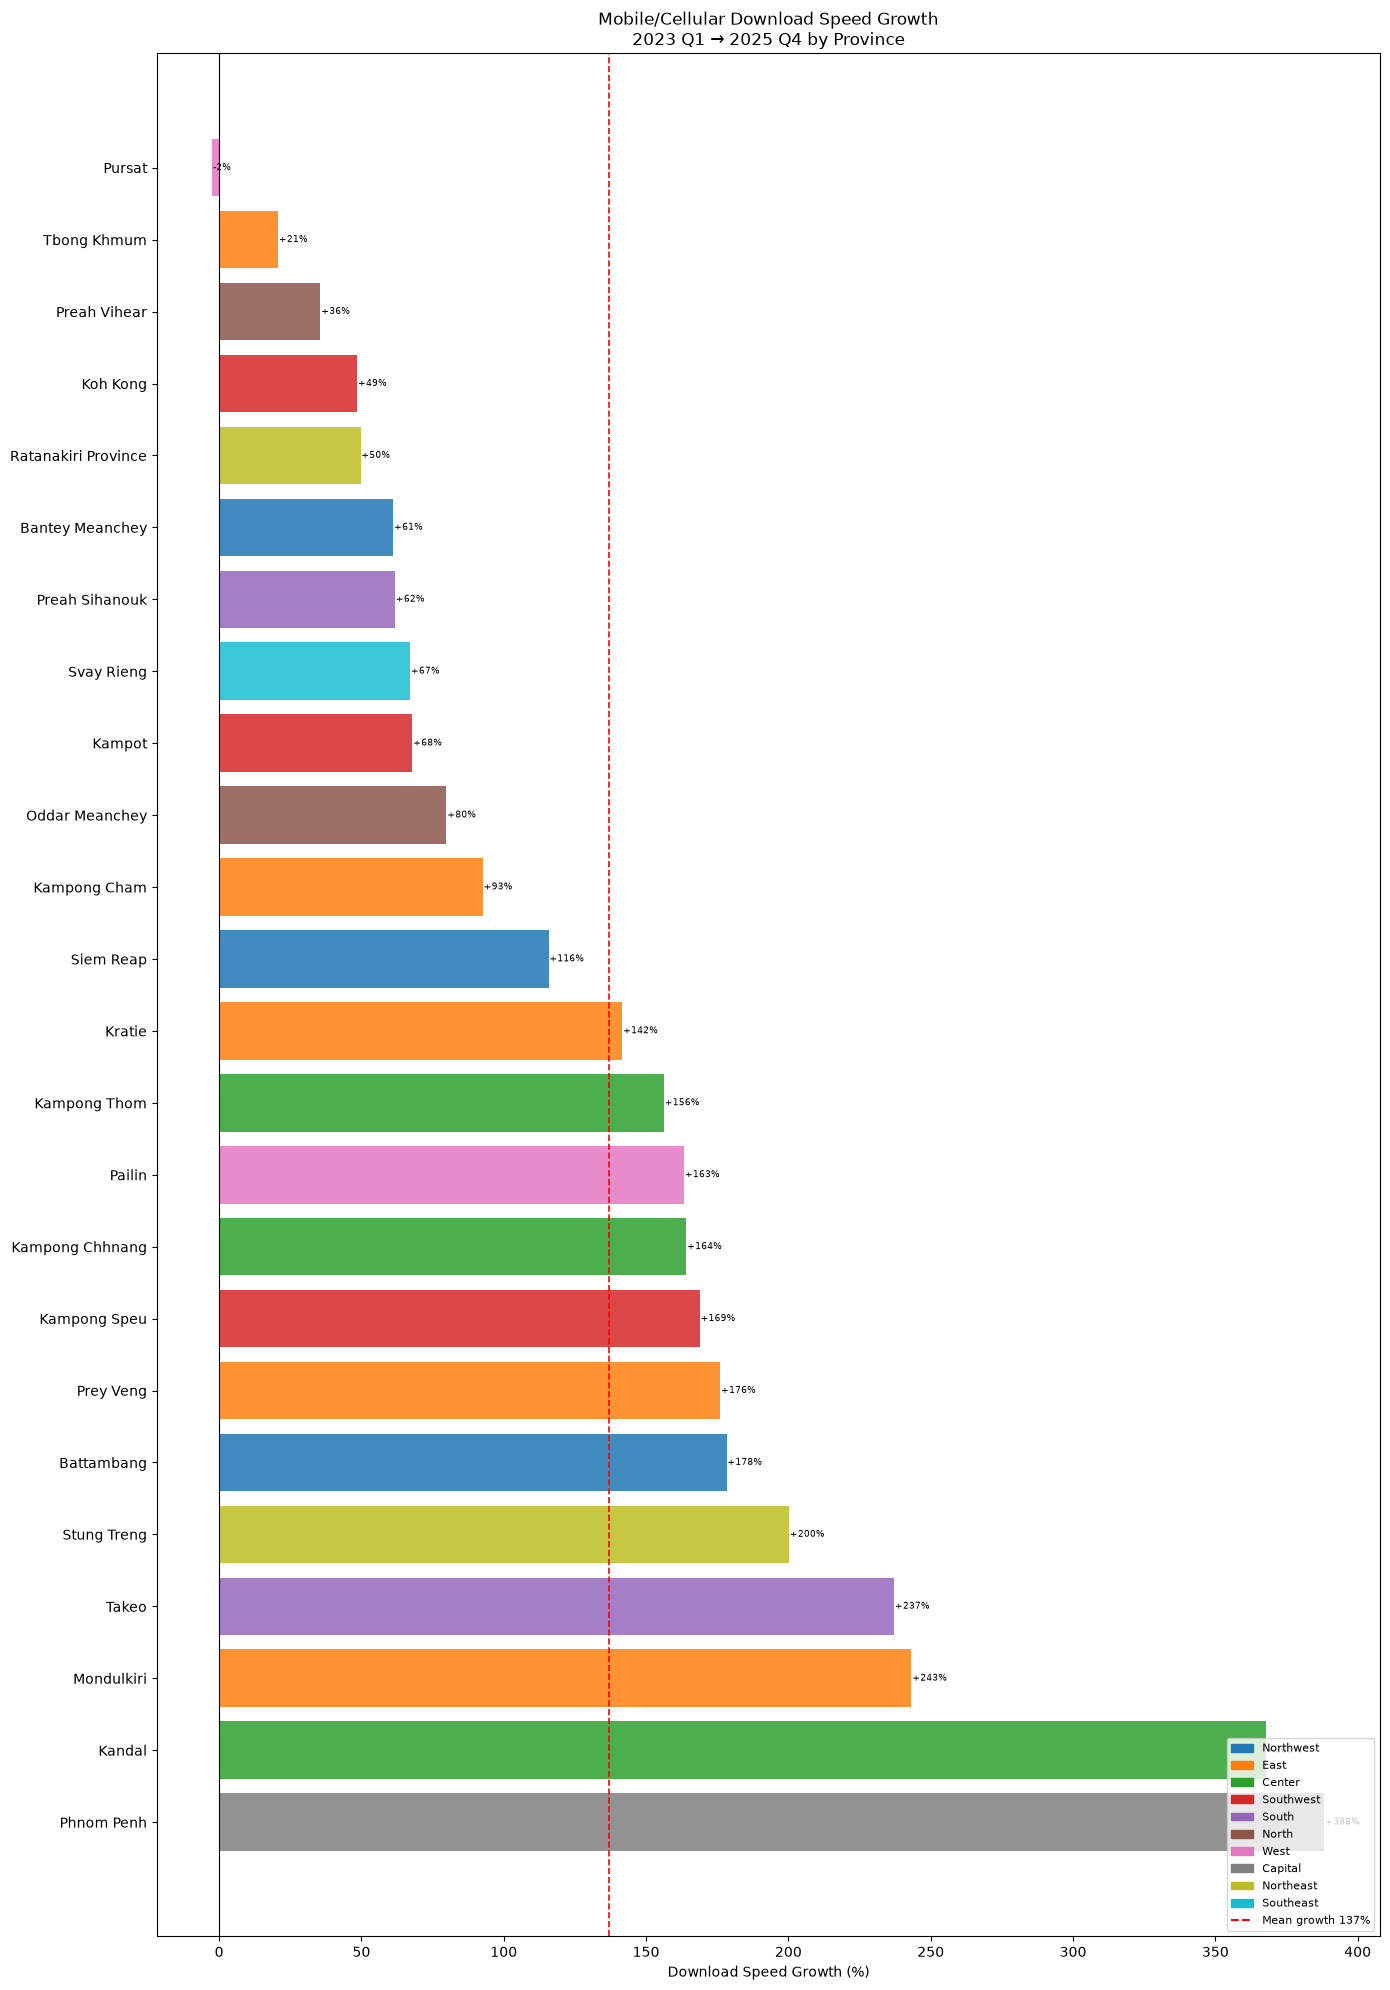

Top 10 fastest growing provinces:
           name    region  internet_tier  pct_growth
     Phnom Penh   Capital              1  388.309884
         Kandal    Center              2  367.791886
     Mondulkiri      East              4  243.246532
          Takeo     South              1  237.147714
    Stung Treng Northeast              3  200.247818
     Battambang Northwest              2  178.278957
      Prey Veng      East              1  176.079800
   Kampong Speu Southwest              4  168.870364
Kampong Chhnang    Center              1  164.158956
         Pailin      West              2  163.376648

Bottom 5 (slowest growth or decline):
               name    region  internet_tier  pct_growth
             Pursat      West              4   -2.340118
        Tbong Khmum      East              4   20.730052
       Preah Vihear     North              3   35.593684
           Koh Kong Southwest              3   48.530987
Ratanakiri Province Northeast              4   49.685612


In [63]:
first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

growth_df = growth.reset_index()
growth_df.columns = ['name','pct_growth']
growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in growth_df['region']]
bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2,
           label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
for bar, val in zip(bars, growth_df['pct_growth']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}%', va='center', fontsize=6.5)
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f'Mean growth {growth_df["pct_growth"].mean():.0f}%')],
          fontsize=8, loc='lower right')
ax.set_xlabel('Download Speed Growth (%)')
ax.set_title('Mobile/Cellular Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/mobile/20_density_vs_speed.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 fastest growing provinces:")
print(growth_df.nlargest(10,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))
print("\nBottom 5 (slowest growth or decline):")
print(growth_df.nsmallest(5,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))


### 15. Deep Dive — The Divergent Ones

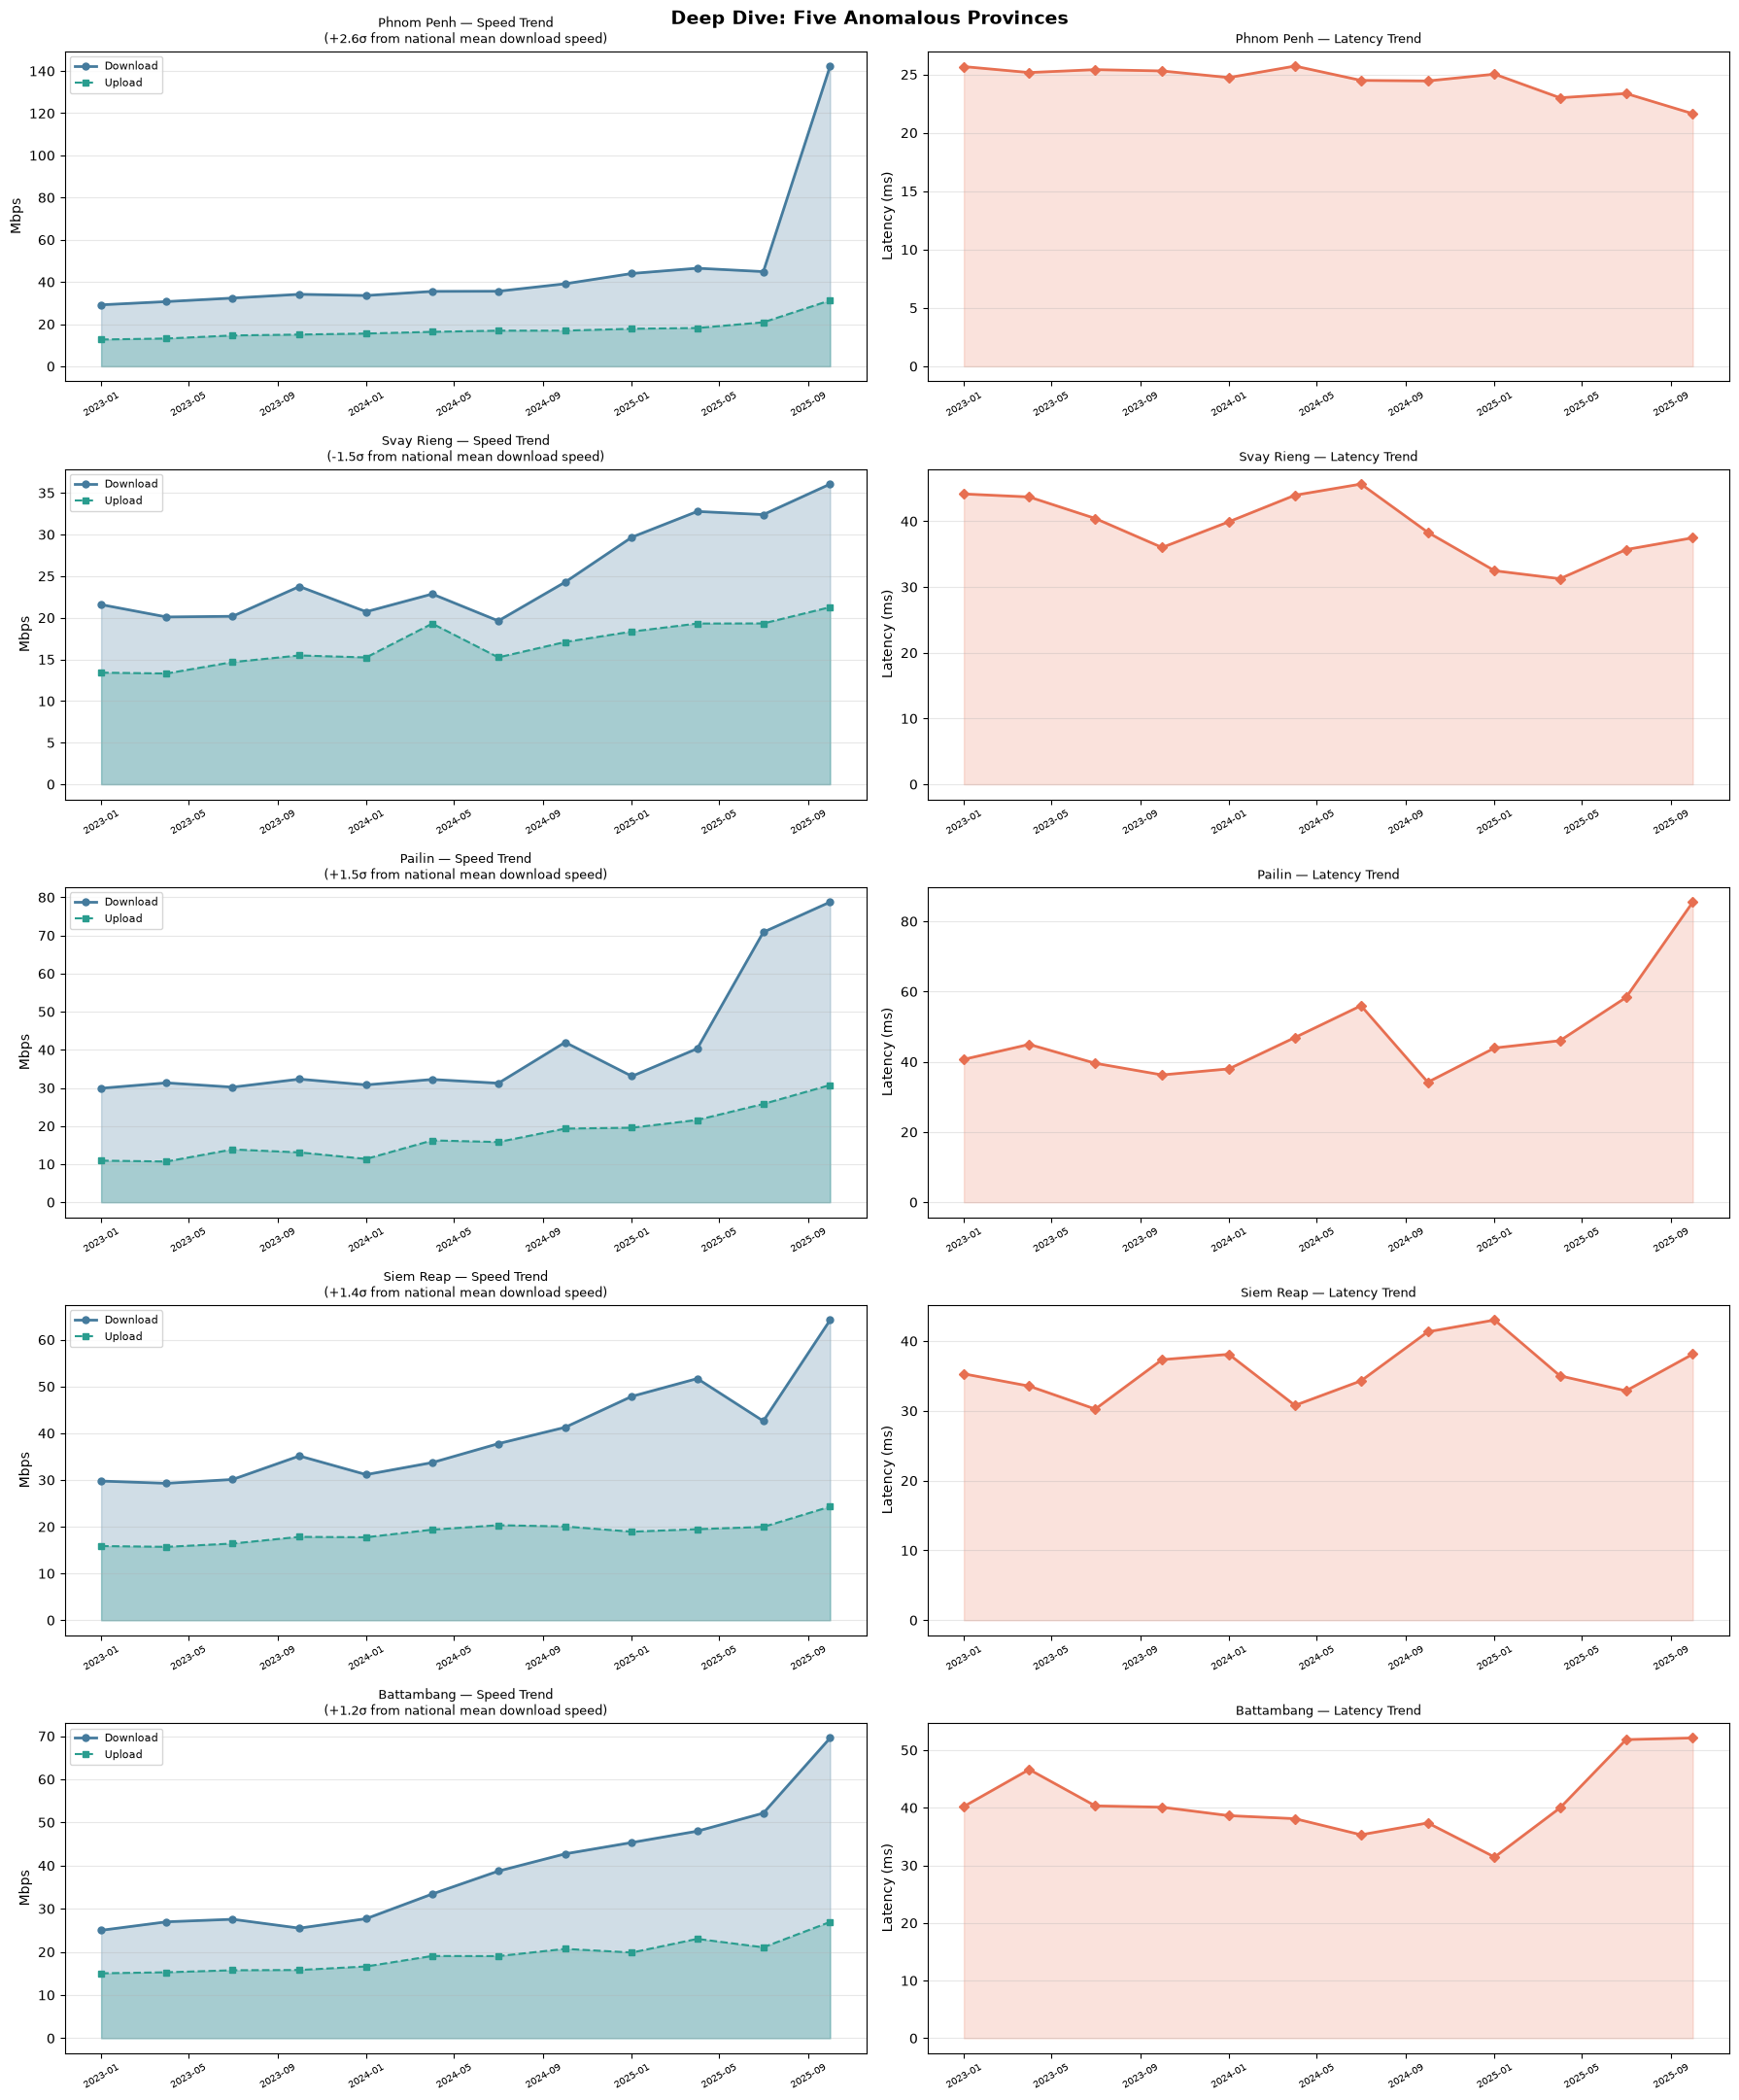

In [64]:
# Focus on the 5 most extreme performers (data-driven selection, no anomaly flags)
_pm = prov_mean.copy()
_pm['z'] = (_pm['mean_dl'] - _pm['mean_dl'].mean()) / _pm['mean_dl'].std()
_top_divergent_df = _pm.reindex(_pm['z'].abs().sort_values(ascending=False).index).head(5)
DIVERGENT = {
    row['name']: f"{row['z']:+.1f}σ from national mean download speed"
    for _, row in _top_divergent_df.iterrows()
}

fig, axes = plt.subplots(len(DIVERGENT), 2, figsize=(18, 22))

quarter_order = sorted(master['label'].unique())

for ax_row, (prov, note) in zip(axes, DIVERGENT.items()):
    df_p = master[master['name']==prov].sort_values('label')
    
    # Download + upload trend
    ax_row[0].fill_between(df_p['period_start'], df_p['avg_d_mbps'], alpha=0.25, color='#457b9d')
    ax_row[0].plot(df_p['period_start'], df_p['avg_d_mbps'], 'o-', color='#457b9d', label='Download', lw=2, markersize=5)
    ax_row[0].fill_between(df_p['period_start'], df_p['avg_u_mbps'], alpha=0.25, color='#2a9d8f')
    ax_row[0].plot(df_p['period_start'], df_p['avg_u_mbps'], 's--', color='#2a9d8f', label='Upload', lw=1.5, markersize=4)
    ax_row[0].set_title(f'{prov} — Speed Trend\n({note})', fontsize=9)
    ax_row[0].set_ylabel('Mbps'); ax_row[0].legend(fontsize=8); ax_row[0].grid(axis='y', alpha=0.3)
    ax_row[0].tick_params(axis='x', rotation=30, labelsize=7)
    
    # Latency trend
    ax_row[1].plot(df_p['period_start'], df_p['avg_lat_ms_wt'], 'D-', color='#e76f51', lw=2, markersize=5)
    ax_row[1].fill_between(df_p['period_start'], df_p['avg_lat_ms_wt'], alpha=0.2, color='#e76f51')
    ax_row[1].set_title(f'{prov} — Latency Trend', fontsize=9)
    ax_row[1].set_ylabel('Latency (ms)'); ax_row[1].grid(axis='y', alpha=0.3)
    ax_row[1].tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle('Deep Dive: Five Anomalous Provinces', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/mobile/21_deep_dive_divergent.png', dpi=150, bbox_inches='tight')
plt.show()


### 16. EDA Key Findings Summary

## Key Findings from EDA

---

In [65]:
from scipy import stats as scipy_stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

_DATA_ROOT = '/home/chissanupun/Desktop/Code/lab/cnc/ds/internet-measurement/data'

# Fallback: load master and prov_ref if not already in scope
if 'master' not in dir() or master is None:
    master = pd.read_parquet(f'{_DATA_ROOT}/ookla/processed/master_province_quarterly.parquet')
    print("Loaded master from processed parquet")
if 'prov_ref' not in dir() or prov_ref is None:
    prov_ref = pd.read_csv(f'{_DATA_ROOT}/reference/province_reference.csv')
    print("Loaded prov_ref from CSV")

# ── Build per-province summary (self-contained) ────────────────────────────────
divergent_df = (
    master.groupby(['name', 'region'])
    .agg(
        mean_dl=('avg_d_mbps', 'mean'),
        mean_ul=('avg_u_mbps', 'mean'),
        mean_lat=('avg_lat_ms_wt', 'mean'),
        mean_tests=('total_tests', 'mean'),
    )
    .reset_index()
)

# Temporal instability: std of quarterly download speed
temp_std = master.groupby('name')['avg_d_mbps'].std().rename('std_dl')
divergent_df = divergent_df.merge(temp_std, on='name', how='left')
divergent_df['cv_dl'] = divergent_df['std_dl'] / divergent_df['mean_dl']

# Merge reference cols
divergent_df = divergent_df.merge(
    prov_ref[['province_en','pop_2024','density_per_km2',
              'gdp_per_capita_thb_2021','internet_tier','area_km2']]
    .rename(columns={'province_en': 'name'}),
    on='name', how='left'
)

divergent_df['ul_dl_ratio']        = divergent_df['mean_ul'] / divergent_df['mean_dl']
divergent_df['tests_per_1000_pop'] = divergent_df['mean_tests'] / divergent_df['pop_2024'] * 1_000

print(f"Provinces in analysis: {len(divergent_df)}")
print(divergent_df[['name','region','internet_tier','mean_dl','ul_dl_ratio','tests_per_1000_pop']].head(5).to_string(index=False))


Provinces in analysis: 25
           name    region  internet_tier   mean_dl  ul_dl_ratio  tests_per_1000_pop
Bantey Meanchey Northwest              1 29.163090     0.458992            2.994767
     Battambang Northwest              2 38.549792     0.493134            1.726417
   Kampong Cham      East              4 28.568155     0.665512            1.167702
Kampong Chhnang    Center              1 28.244367     0.650300            1.139178
   Kampong Speu Southwest              4 29.816497     0.575813            1.268338


In [66]:
# ── Dimension 1: Tier residual ─────────────────────────────────────────────────
tier_med = divergent_df.groupby('internet_tier')['mean_dl'].median()
divergent_df['tier_expected']   = divergent_df['internet_tier'].map(tier_med)
divergent_df['tier_residual']   = (divergent_df['mean_dl'] - divergent_df['tier_expected']) / divergent_df['tier_expected']
divergent_df['tier_residual_z'] = (divergent_df['tier_residual'] - divergent_df['tier_residual'].mean()) / divergent_df['tier_residual'].std()

# ── Dimension 2: GDP residual (OLS on log-GDP) ─────────────────────────────────
log_gdp = np.log(divergent_df['gdp_per_capita_thb_2021'])
if log_gdp.nunique() > 1:
    slope_g, int_g, r_g, p_g, _ = scipy_stats.linregress(log_gdp, divergent_df['mean_dl'])
    divergent_df['gdp_expected']   = int_g + slope_g * log_gdp
    divergent_df['gdp_residual']   = divergent_df['mean_dl'] - divergent_df['gdp_expected']
    divergent_df['gdp_residual_z'] = scipy_stats.zscore(divergent_df['gdp_residual'])
else:
    # GDP per capita uniform across regions (e.g. Singapore: national-only data) — dimension contributes nothing
    slope_g, int_g, r_g, p_g = 0.0, divergent_df['mean_dl'].mean(), float('nan'), float('nan')
    divergent_df['gdp_expected']   = int_g
    divergent_df['gdp_residual']   = 0.0
    divergent_df['gdp_residual_z'] = 0.0

# ── Dimension 3: Density residual (OLS on log-density) ────────────────────────
log_den = np.log1p(divergent_df['density_per_km2'])
slope_d, int_d, r_d, p_d, _ = scipy_stats.linregress(log_den, divergent_df['mean_dl'])
divergent_df['den_expected']   = int_d + slope_d * log_den
divergent_df['den_residual_z'] = scipy_stats.zscore(divergent_df['mean_dl'] - divergent_df['den_expected'])

# ── Dimension 4: Regional z-score (speed within region) ───────────────────────
divergent_df['regional_z'] = divergent_df.groupby('region')['mean_dl'].transform(
    lambda x: scipy_stats.zscore(x) if len(x) > 1 else pd.Series(np.zeros(len(x)), index=x.index)
)

# ── Dimension 5: UL/DL ratio z-score ──────────────────────────────────────────
divergent_df['ratio_z'] = scipy_stats.zscore(divergent_df['ul_dl_ratio'])

# ── Dimension 6: Within-region latency z-score ────────────────────────────────
divergent_df['lat_regional_z'] = divergent_df.groupby('region')['mean_lat'].transform(
    lambda x: scipy_stats.zscore(x) if len(x) > 1 else pd.Series(np.zeros(len(x)), index=x.index)
)

# ── Dimension 7: Coverage z-score (tests per 1000 pop) ────────────────────────
divergent_df['coverage_z'] = scipy_stats.zscore(divergent_df['tests_per_1000_pop'])

# ── Composite divergence score (sum of absolute z-scores) ──────────────────────
divergent_df['divergence_score'] = (
    np.abs(divergent_df['tier_residual_z']) +
    np.abs(divergent_df['gdp_residual_z']) +
    np.abs(divergent_df['den_residual_z']) +
    np.abs(divergent_df['regional_z']) +
    np.abs(divergent_df['ratio_z']) +
    np.abs(divergent_df['lat_regional_z']) +
    np.abs(divergent_df['coverage_z'])
)

print(f"GDP-speed OLS:     r = {r_g:.3f}, slope = {slope_g:.2f} Mbps per log-unit GDP")
print(f"Density-speed OLS: r = {r_d:.3f}, slope = {slope_d:.2f} Mbps per log-unit density")
print()
print("Top 15 divergentest provinces:")
cols = ['name','region','internet_tier','mean_dl','divergence_score',
        'gdp_residual_z','den_residual_z','regional_z','ratio_z','lat_regional_z','coverage_z']
print(divergent_df.nlargest(15,'divergence_score')[cols].to_string(index=False))


GDP-speed OLS:     r = nan, slope = 0.00 Mbps per log-unit GDP
Density-speed OLS: r = 0.266, slope = 1.02 Mbps per log-unit density

Top 15 divergentest provinces:
               name    region  internet_tier   mean_dl  divergence_score  gdp_residual_z  den_residual_z  regional_z   ratio_z  lat_regional_z  coverage_z
         Phnom Penh   Capital              1 45.660465          9.157332             0.0        1.967517    0.000000 -2.119431        0.000000    2.228817
             Pailin      West              2 40.247960          7.143422             0.0        1.584007    1.000000 -1.581387        1.000000    1.173462
          Siem Reap Northwest              1 39.554521          6.338969             0.0        1.418096    0.811734 -1.118974       -1.352182   -0.088449
        Tbong Khmum      East              4 27.288132          6.277530             0.0       -1.318480   -1.060412  0.977466        1.260688   -0.786559
         Mondulkiri      East              4 36.124628       

### 18. Tier vs Actual Speed — Expectation Gap

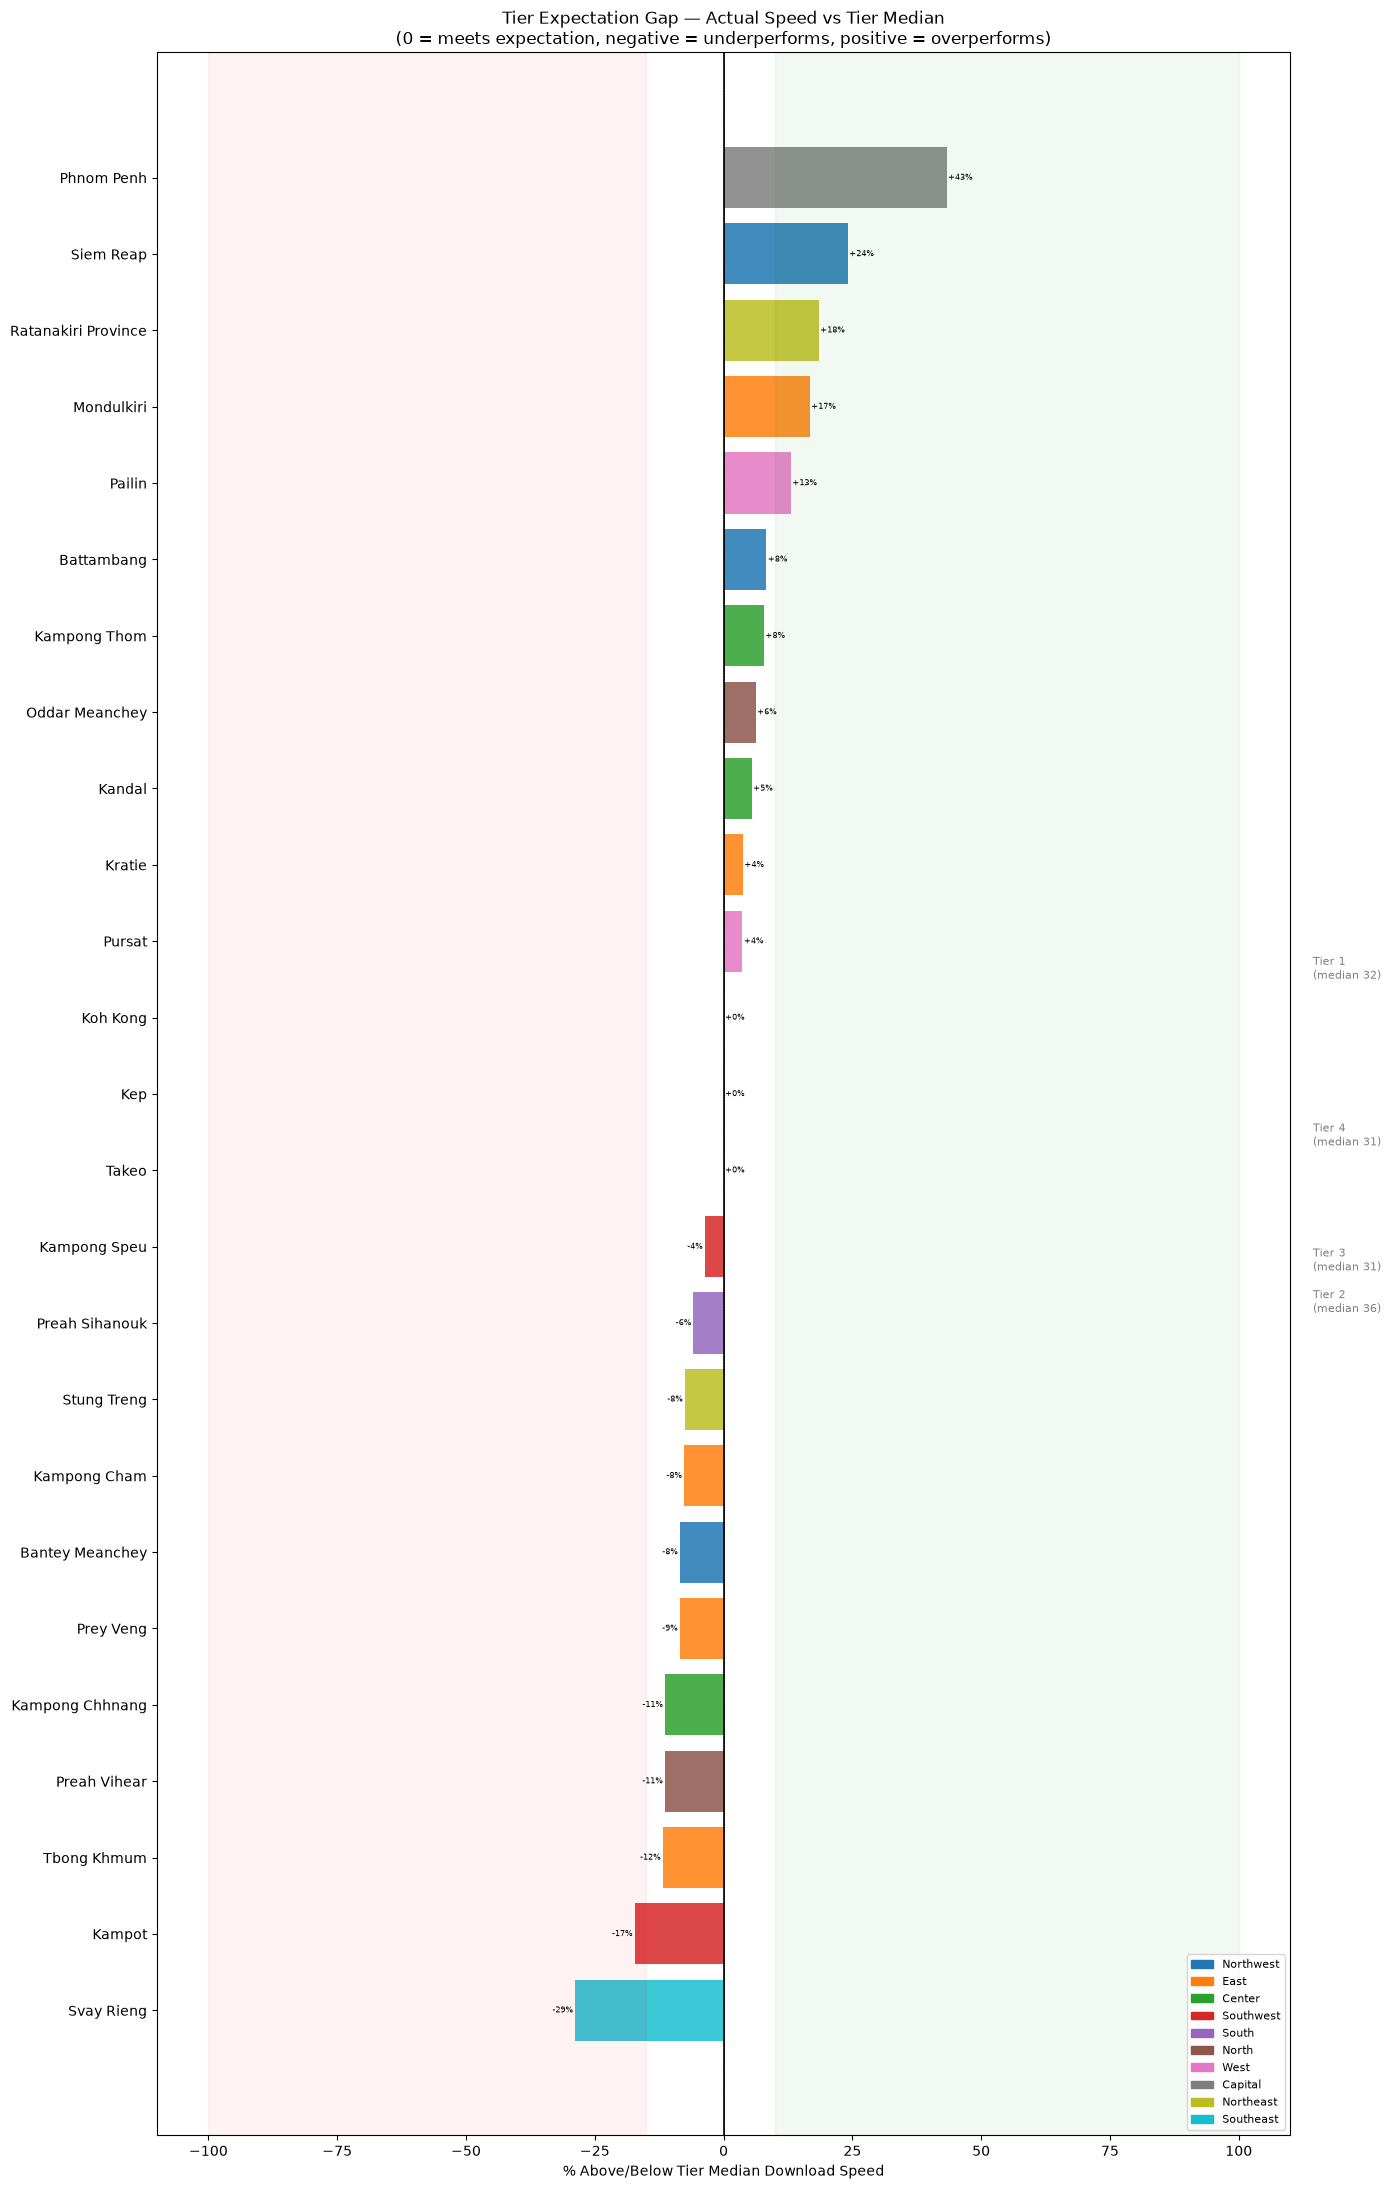

Biggest underperformers vs tier expectation:
           name  internet_tier   mean_dl  tier_expected  tier_residual
     Svay Rieng              2 25.332388      35.595469      -0.288325
         Kampot              2 29.445362      35.595469      -0.172778
    Tbong Khmum              4 27.288132      30.945991      -0.118201
   Preah Vihear              3 27.345963      30.863659      -0.113975
Kampong Chhnang              1 28.244367      31.868558      -0.113723
      Prey Veng              1 29.156713      31.868558      -0.085095
Bantey Meanchey              1 29.163090      31.868558      -0.084895
   Kampong Cham              4 28.568155      30.945991      -0.076838

Biggest overperformers vs tier expectation:
               name  internet_tier   mean_dl  tier_expected  tier_residual
         Phnom Penh              1 45.660465      31.868558       0.432775
          Siem Reap              1 39.554521      31.868558       0.241177
Ratanakiri Province              4 36.664250  

In [67]:
# Show each province's % deviation from its tier median
tier_gap = divergent_df[['name','region','internet_tier','mean_dl','tier_expected','tier_residual']].copy()
tier_gap = tier_gap.sort_values('tier_residual')

fig, ax = plt.subplots(figsize=(14, 22))

region_colors = {
    'Northwest': '#1f77b4',
    'East': '#ff7f0e',
    'Center': '#2ca02c',
    'Southwest': '#d62728',
    'South': '#9467bd',
    'North': '#8c564b',
    'West': '#e377c2',
    'Capital': '#7f7f7f',
    'Northeast': '#bcbd22',
    'Southeast': '#17becf',
}

colors = [region_colors.get(r, 'gray') for r in tier_gap['region']]
bars = ax.barh(tier_gap['name'], tier_gap['tier_residual'] * 100, color=colors, alpha=0.85)

# Tier median reference lines
ax.axvline(0, color='black', lw=1.2, label='Tier median (expected)')

# Annotate bars
for bar, val in zip(bars, tier_gap['tier_residual']):
    x = bar.get_width()
    ax.text(x + (0.3 if x >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
            f'{val*100:+.0f}%', va='center', ha='left' if x >= 0 else 'right', fontsize=6)

# Tier grouping lines
tier_boundaries = tier_gap.groupby('internet_tier').apply(lambda g: (g.index.min(), g.index.max()))
for t in sorted(tier_gap['internet_tier'].unique()):
    grp = tier_gap[tier_gap['internet_tier'] == t]
    median = tier_med[t]
    ax.axvline(0, color='black', lw=0.4, ls='--', alpha=0.4)

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, fontsize=8, loc='lower right')
ax.set_xlabel('% Above/Below Tier Median Download Speed')
ax.set_title('Tier Expectation Gap — Actual Speed vs Tier Median\n'
             '(0 = meets expectation, negative = underperforms, positive = overperforms)', fontsize=12)
ax.axvspan(-100, -15, alpha=0.05, color='red', label='Strong underperform')
ax.axvspan(10, 100, alpha=0.05, color='green')

# Annotate Tier brackets on y-axis
for t in sorted(tier_gap['internet_tier'].unique()):
    grp_idx = tier_gap[tier_gap['internet_tier']==t].index
    grp_pos = [list(tier_gap.index).index(i) for i in grp_idx]
    if grp_pos:
        mid = (min(grp_pos) + max(grp_pos)) / 2
        ax.annotate(f'Tier {t}\n(median {tier_med[t]:.0f})', xy=(1.02, mid/len(tier_gap)),
                    xycoords='axes fraction', va='center', fontsize=8, color='gray')

plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/mobile/22_tier_expectation_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Biggest underperformers vs tier expectation:")
print(tier_gap.nsmallest(8,'tier_residual')[['name','internet_tier','mean_dl','tier_expected','tier_residual']].to_string(index=False))
print()
print("Biggest overperformers vs tier expectation:")
print(tier_gap.nlargest(8,'tier_residual')[['name','internet_tier','mean_dl','tier_expected','tier_residual']].to_string(index=False))


### 19. GDP per Capita vs Download Speed — Who Breaks the Rule?

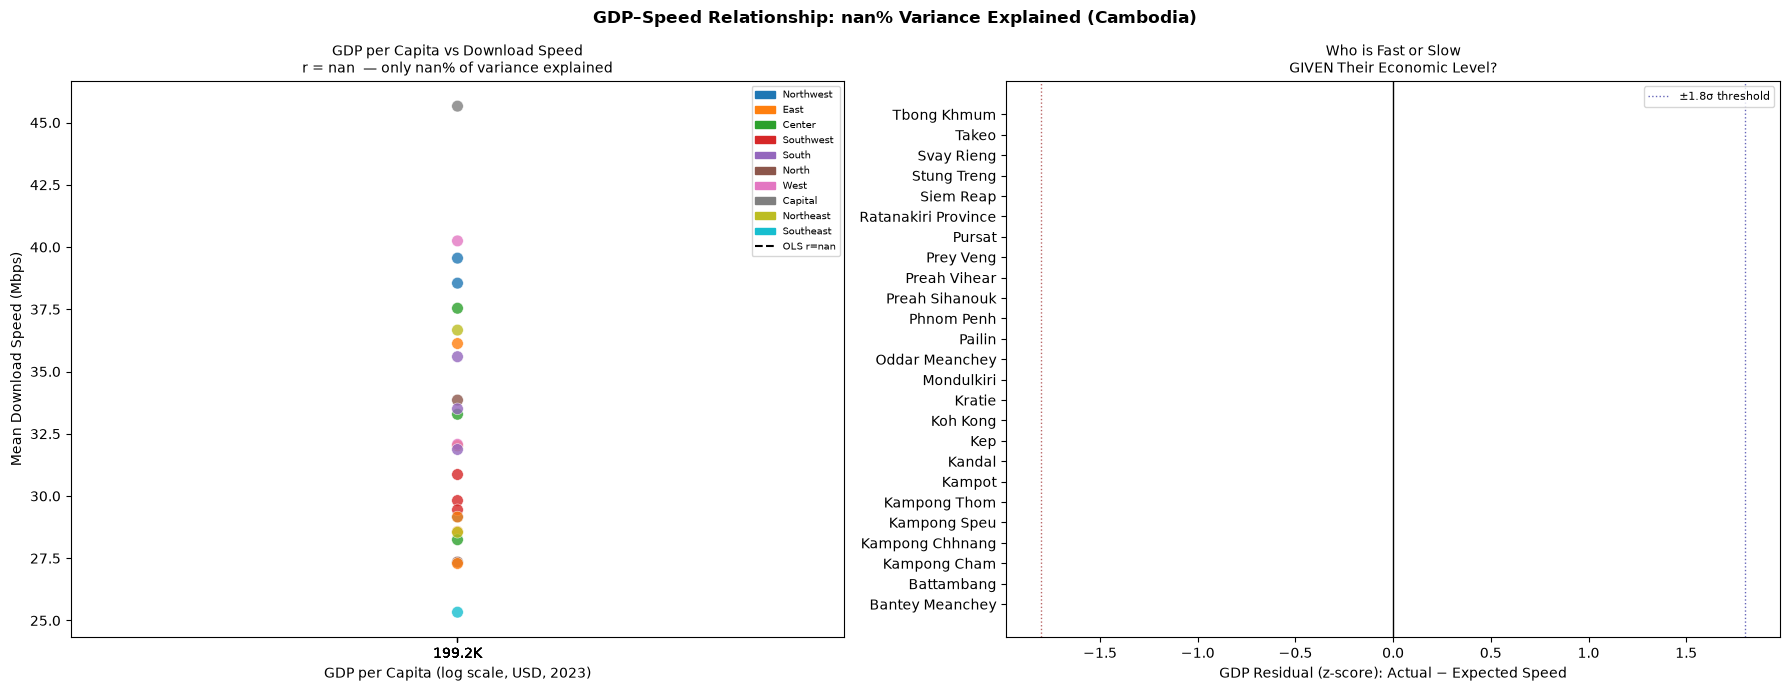

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: GDP scatter ──────────────────────────────────────────────────────────
ax = axes[0]
gdp_vals = divergent_df['gdp_per_capita_thb_2021']
colors_scatter = [region_colors.get(r, 'gray') for r in divergent_df['region']]

sc = ax.scatter(np.log(gdp_vals), divergent_df['mean_dl'],
                c=colors_scatter, s=70, alpha=0.8, edgecolors='white', lw=0.4)

# OLS line
x_fit = np.linspace(np.log(gdp_vals.min()), np.log(gdp_vals.max()), 200)
ax.plot(x_fit, int_g + slope_g * x_fit, 'k--', lw=1.5,
        label=f'OLS fit  r={r_g:.2f}')

# Label big residuals
threshold = 1.8
for _, row in divergent_df.iterrows():
    if abs(row['gdp_residual_z']) > threshold:
        ax.annotate(row['name'],
                    (np.log(row['gdp_per_capita_thb_2021']), row['mean_dl']),
                    fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points',
                    color='darkred' if row['gdp_residual_z'] < 0 else 'darkblue')

ax.set_xlabel('GDP per Capita (log scale, USD, 2023)')
ax.set_ylabel('Mean Download Speed (Mbps)')
ax.set_title(f'GDP per Capita vs Download Speed\nr = {r_g:.2f}  — only {r_g**2*100:.0f}% of variance explained',
             fontsize=10)

# x-tick labels spaced across the actual data range (log scale)
_tick_vals = np.geomspace(gdp_vals.min(), gdp_vals.max(), 5)
ax.set_xticks(np.log(_tick_vals))
ax.set_xticklabels([f'{v/1000:.1f}K' if v >= 1000 else f'{v:.0f}' for v in _tick_vals])

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches + [plt.Line2D([0],[0],color='black',ls='--',label=f'OLS r={r_g:.2f}')],
          fontsize=7)

# ── Right: residual bar chart ──────────────────────────────────────────────────
ax2 = axes[1]
resid_sorted = divergent_df.sort_values('gdp_residual_z')
cols2 = [region_colors.get(r, 'gray') for r in resid_sorted['region']]
bars2 = ax2.barh(resid_sorted['name'], resid_sorted['gdp_residual_z'], color=cols2, alpha=0.85)
ax2.axvline(0, color='black', lw=1)
ax2.axvline(1.8, color='darkblue', ls=':', lw=1, alpha=0.6, label='±1.8σ threshold')
ax2.axvline(-1.8, color='darkred', ls=':', lw=1, alpha=0.6)
ax2.set_xlabel('GDP Residual (z-score): Actual − Expected Speed')
ax2.set_title('Who is Fast or Slow\nGIVEN Their Economic Level?', fontsize=10)
ax2.legend(fontsize=8)
# Add province labels for outliers
for bar, (_, row) in zip(bars2, resid_sorted.iterrows()):
    if abs(row['gdp_residual_z']) > 1.8:
        x = bar.get_width()
        ax2.text(x + (0.05 if x >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
                 row['name'], va='center', ha='left' if x >= 0 else 'right', fontsize=5.5,
                 color='darkblue' if x > 0 else 'darkred', fontweight='bold')

plt.suptitle(f'GDP–Speed Relationship: {r_g**2*100:.0f}% Variance Explained (Cambodia)',
             fontsize=12, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/mobile/23_gdp_residual_bar.png', dpi=150, bbox_inches='tight')
plt.show()


### 20. Population Density vs Speed — Greenfield Fiber Effect

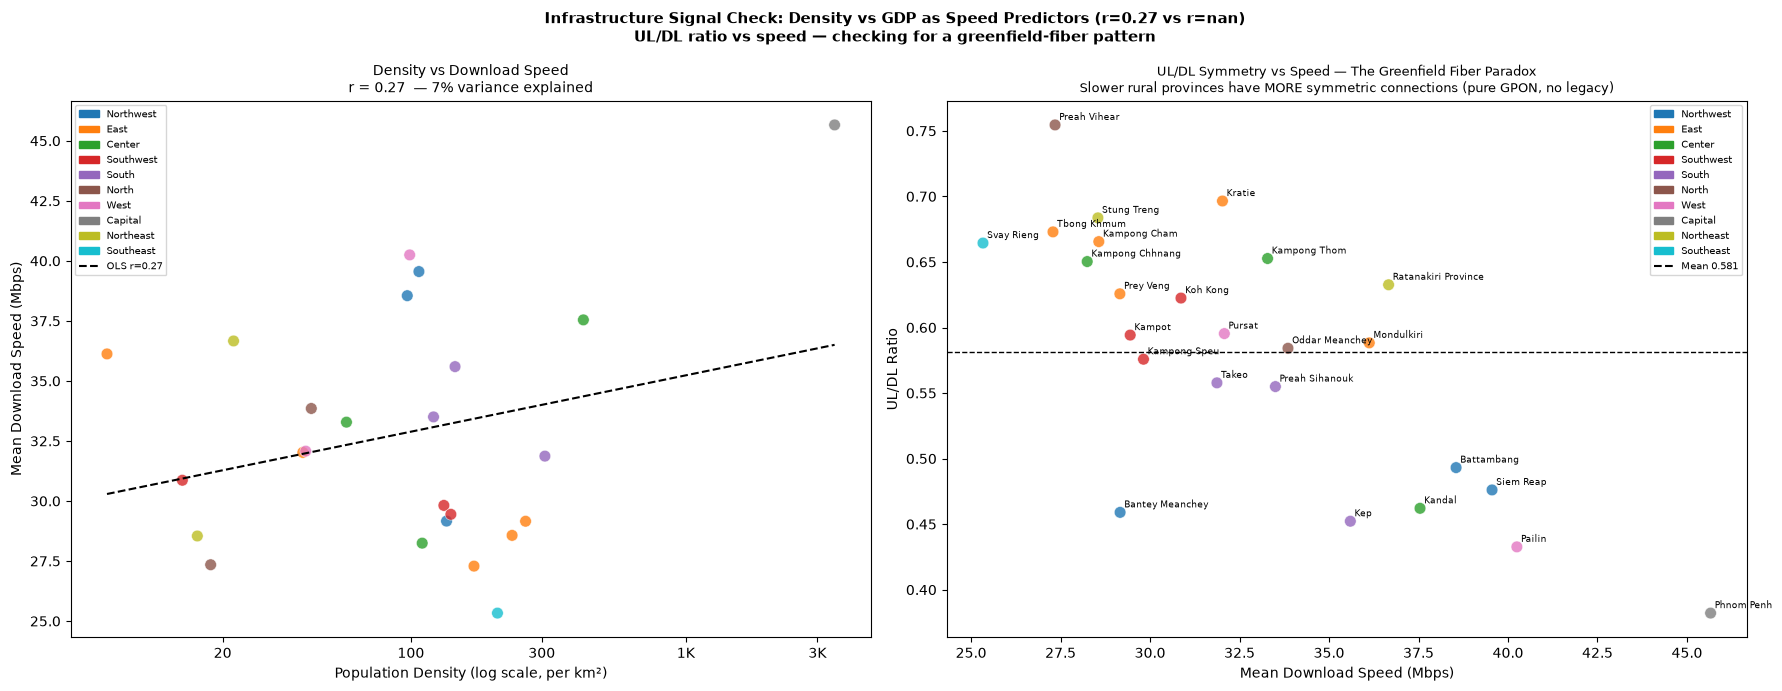

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: Density scatter ──────────────────────────────────────────────────────
ax = axes[0]
den_vals = divergent_df['density_per_km2']
colors_s = [region_colors.get(r, 'gray') for r in divergent_df['region']]

ax.scatter(np.log1p(den_vals), divergent_df['mean_dl'],
           c=colors_s, s=70, alpha=0.8, edgecolors='white', lw=0.4)

x_fit2 = np.linspace(np.log1p(den_vals.min()), np.log1p(den_vals.max()), 200)
ax.plot(x_fit2, int_d + slope_d * x_fit2, 'k--', lw=1.5, label=f'OLS r={r_d:.2f}')

for _, row in divergent_df.iterrows():
    if abs(row['den_residual_z']) > 2.0:
        ax.annotate(row['name'],
                    (np.log1p(row['density_per_km2']), row['mean_dl']),
                    fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points',
                    color='darkred' if row['den_residual_z'] < 0 else 'darkblue')

xticks_den = np.log1p([20, 100, 300, 1000, 3000])
ax.set_xticks(xticks_den)
ax.set_xticklabels(['20','100','300','1K','3K'])
ax.set_xlabel('Population Density (log scale, per km²)')
ax.set_ylabel('Mean Download Speed (Mbps)')
ax.set_title(f'Density vs Download Speed\nr = {r_d:.2f}  — {r_d**2*100:.0f}% variance explained', fontsize=10)
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches + [plt.Line2D([0],[0],color='black',ls='--',label=f'OLS r={r_d:.2f}')],
          fontsize=7)

# ── Right: UL/DL ratio vs DL speed — the "greenfield fiber paradox" ───────────
ax2 = axes[1]
ax2.scatter(divergent_df['mean_dl'], divergent_df['ul_dl_ratio'],
            c=colors_s, s=70, alpha=0.8, edgecolors='white', lw=0.4)

for _, row in divergent_df.iterrows():
    if row['ul_dl_ratio'] > 0.91 or row['ul_dl_ratio'] < 0.80 or row['mean_dl'] < 170:
        ax2.annotate(row['name'], (row['mean_dl'], row['ul_dl_ratio']),
                     fontsize=6.5, ha='left', va='bottom',
                     xytext=(3, 2), textcoords='offset points')

ax2.axhline(divergent_df['ul_dl_ratio'].mean(), color='black', ls='--', lw=1,
            label=f"Mean ratio {divergent_df['ul_dl_ratio'].mean():.3f}")
ax2.set_xlabel('Mean Download Speed (Mbps)')
ax2.set_ylabel('UL/DL Ratio')
ax2.set_title('UL/DL Symmetry vs Speed — The Greenfield Fiber Paradox\n'
              'Slower rural provinces have MORE symmetric connections (pure GPON, no legacy)', fontsize=9)
ax2.legend(handles=patches + [plt.Line2D([0],[0],color='black',ls='--',
           label=f'Mean {divergent_df["ul_dl_ratio"].mean():.3f}')], fontsize=7)

# Add trend arrow annotation
ax2.annotate('← slower but more symmetric\n   (rural greenfield fiber)',
             xy=(155, 0.905), fontsize=7.5, color='#6d6875',
             bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.8))
ax2.annotate('faster but less symmetric →\n(urban legacy cable mix)',
             xy=(285, 0.800), fontsize=7.5, color='#e63946',
             bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.8))

plt.suptitle(f'Infrastructure Signal Check: Density vs GDP as Speed Predictors (r={r_d:.2f} vs r={r_g:.2f})\n'
             'UL/DL ratio vs speed — checking for a greenfield-fiber pattern',
             fontsize=11, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/mobile/24_uldl_greenfield.png', dpi=150, bbox_inches='tight')
plt.show()


### 21. Ookla Coverage — Tests per 1,000 Population

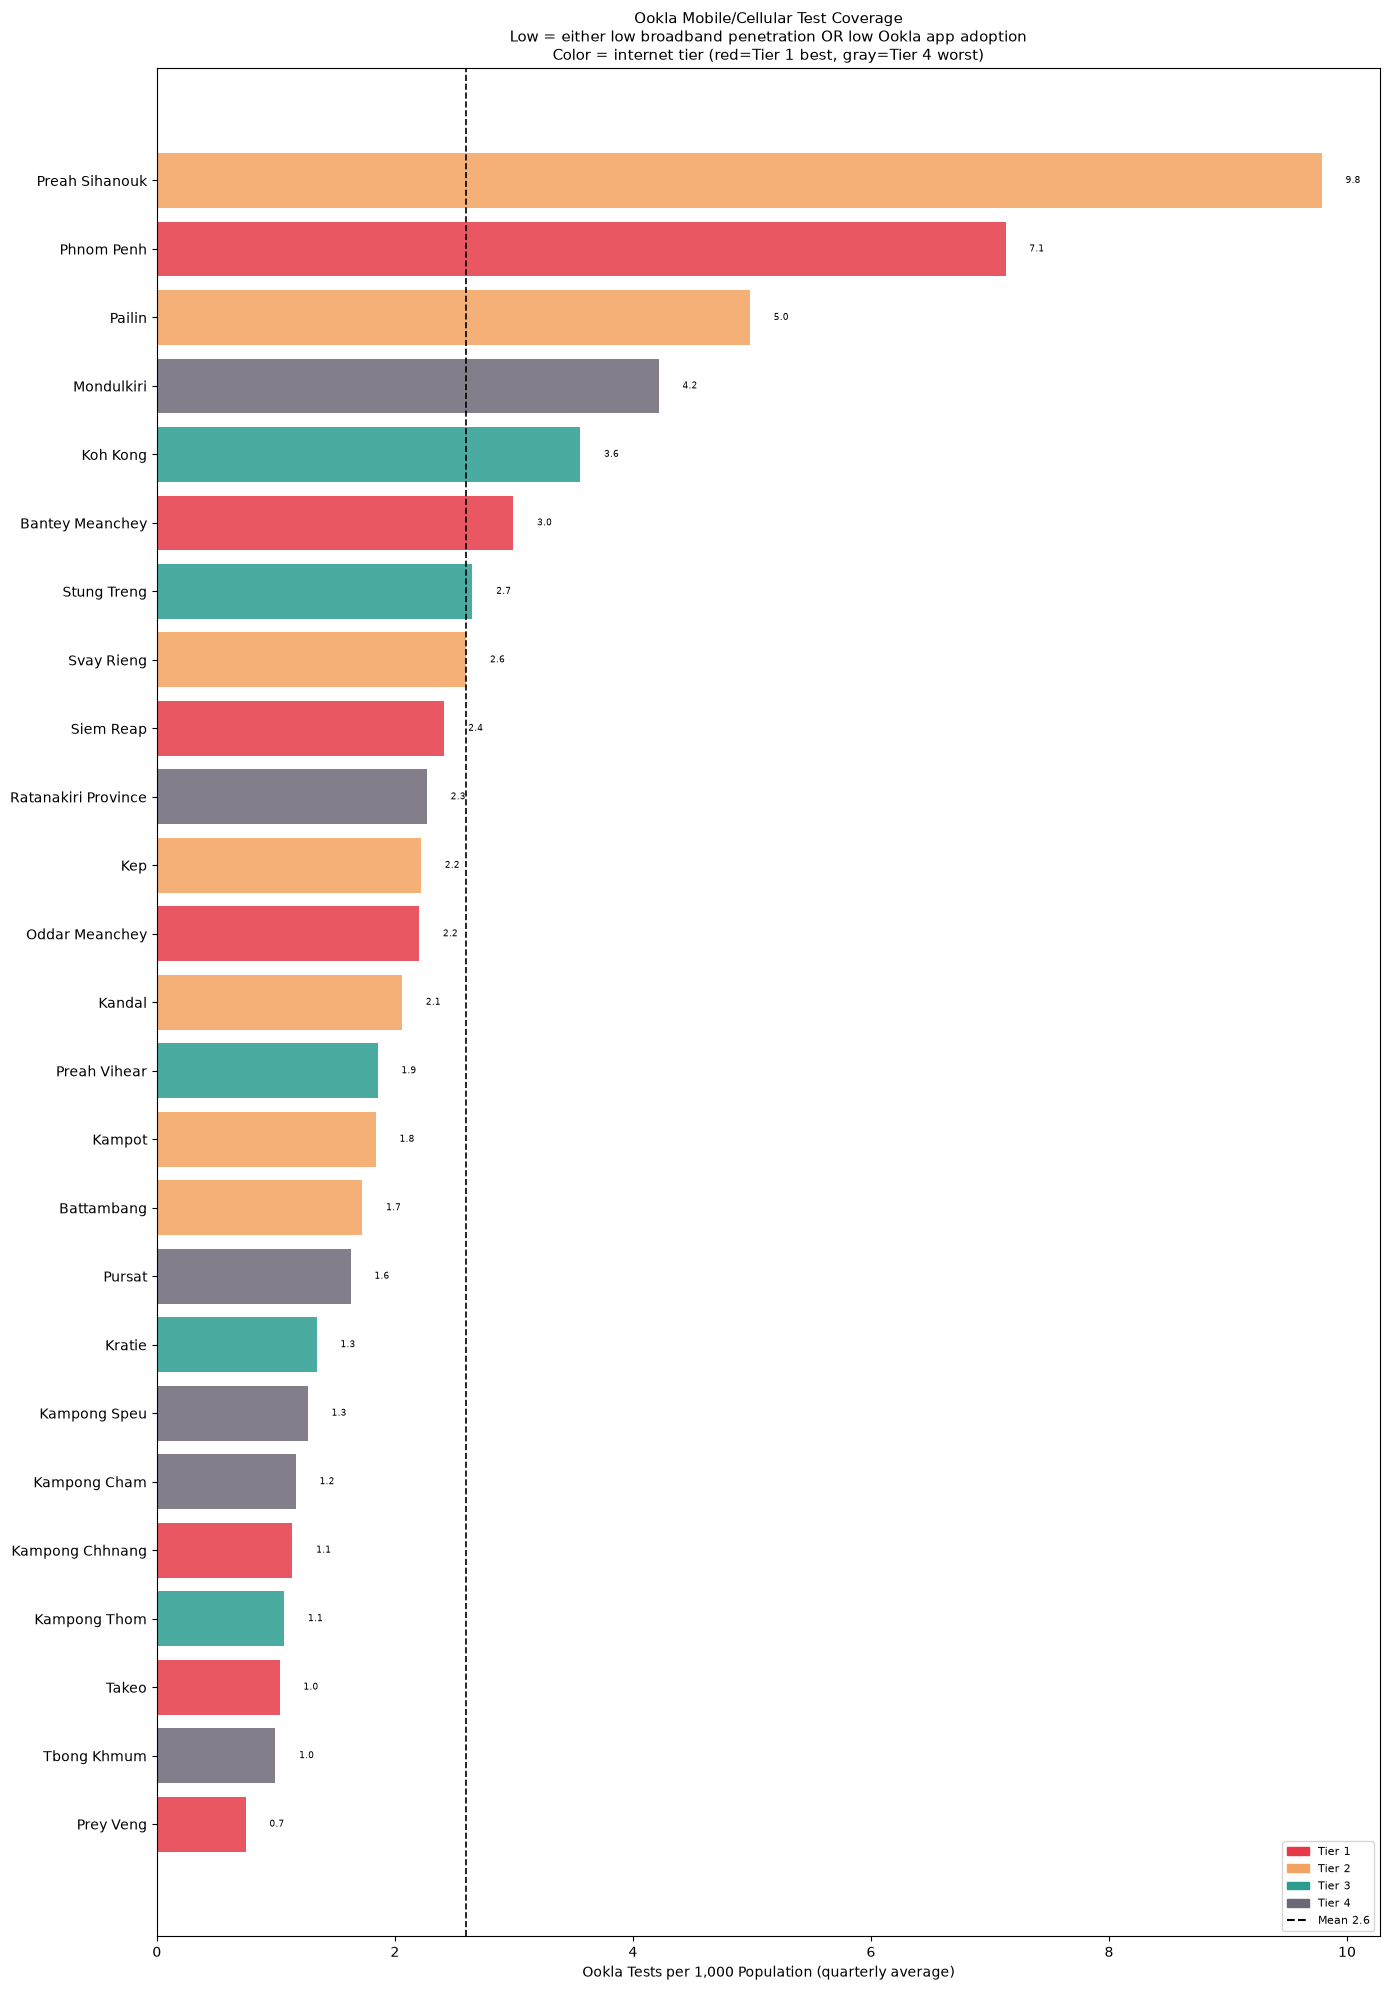

Top coverage (tests per 1000 pop):
           name    region  internet_tier  tests_per_1000_pop   mean_tests  pop_2024
 Preah Sihanouk     South              2            9.787589  2297.166667    234702
     Phnom Penh   Capital              1            7.130675 16777.416667   2352851
         Pailin      West              2            4.983532   395.916667     79445
     Mondulkiri      East              4            4.216627   394.916667     93657
       Koh Kong Southwest              3            3.557105   501.416667    140962
Bantey Meanchey Northwest              1            2.994767  2690.750000    898484
    Stung Treng Northeast              3            2.651738   468.000000    176488
     Svay Rieng Southeast              2            2.599516  1593.916667    613159

Bottom coverage:
           name    region  internet_tier  tests_per_1000_pop  mean_tests  pop_2024
      Prey Veng      East              1            0.746035  953.333333   1277867
    Tbong Khmum      East

In [70]:
# Tests per 1000 pop = proxy for (broadband penetration × Ookla app adoption × tech-savviness)
cov = divergent_df.sort_values('tests_per_1000_pop')
tier_palette = {1:'#e63946', 2:'#f4a261', 3:'#2a9d8f', 4:'#6d6875'}
colors_cov = [tier_palette.get(int(t), 'gray') for t in cov['internet_tier']]

fig, ax = plt.subplots(figsize=(14, 20))
bars = ax.barh(cov['name'], cov['tests_per_1000_pop'], color=colors_cov, alpha=0.85)
ax.axvline(divergent_df['tests_per_1000_pop'].mean(), color='black', ls='--', lw=1.2,
           label=f"National mean {divergent_df['tests_per_1000_pop'].mean():.1f}")

for bar, val in zip(bars, cov['tests_per_1000_pop']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=6.2)

patches_t = [mpatches.Patch(color=v, label=f'Tier {k}') for k, v in tier_palette.items()]
ax.legend(handles=patches_t + [plt.Line2D([0],[0],color='black',ls='--',
           label=f'Mean {divergent_df["tests_per_1000_pop"].mean():.1f}')], fontsize=8)
ax.set_xlabel('Ookla Tests per 1,000 Population (quarterly average)')
ax.set_title('Ookla Mobile/Cellular Test Coverage\n'
             'Low = either low broadband penetration OR low Ookla app adoption\n'
             'Color = internet tier (red=Tier 1 best, gray=Tier 4 worst)', fontsize=11)
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/mobile/25_test_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top coverage (tests per 1000 pop):")
print(divergent_df.nlargest(8,'tests_per_1000_pop')[
    ['name','region','internet_tier','tests_per_1000_pop','mean_tests','pop_2024']
].to_string(index=False))
print()
print("Bottom coverage:")
print(divergent_df.nsmallest(10,'tests_per_1000_pop')[
    ['name','region','internet_tier','tests_per_1000_pop','mean_tests','pop_2024']
].to_string(index=False))


### 22. Composite Divergence Leaderboard — Top 20 Anomalous Provinces

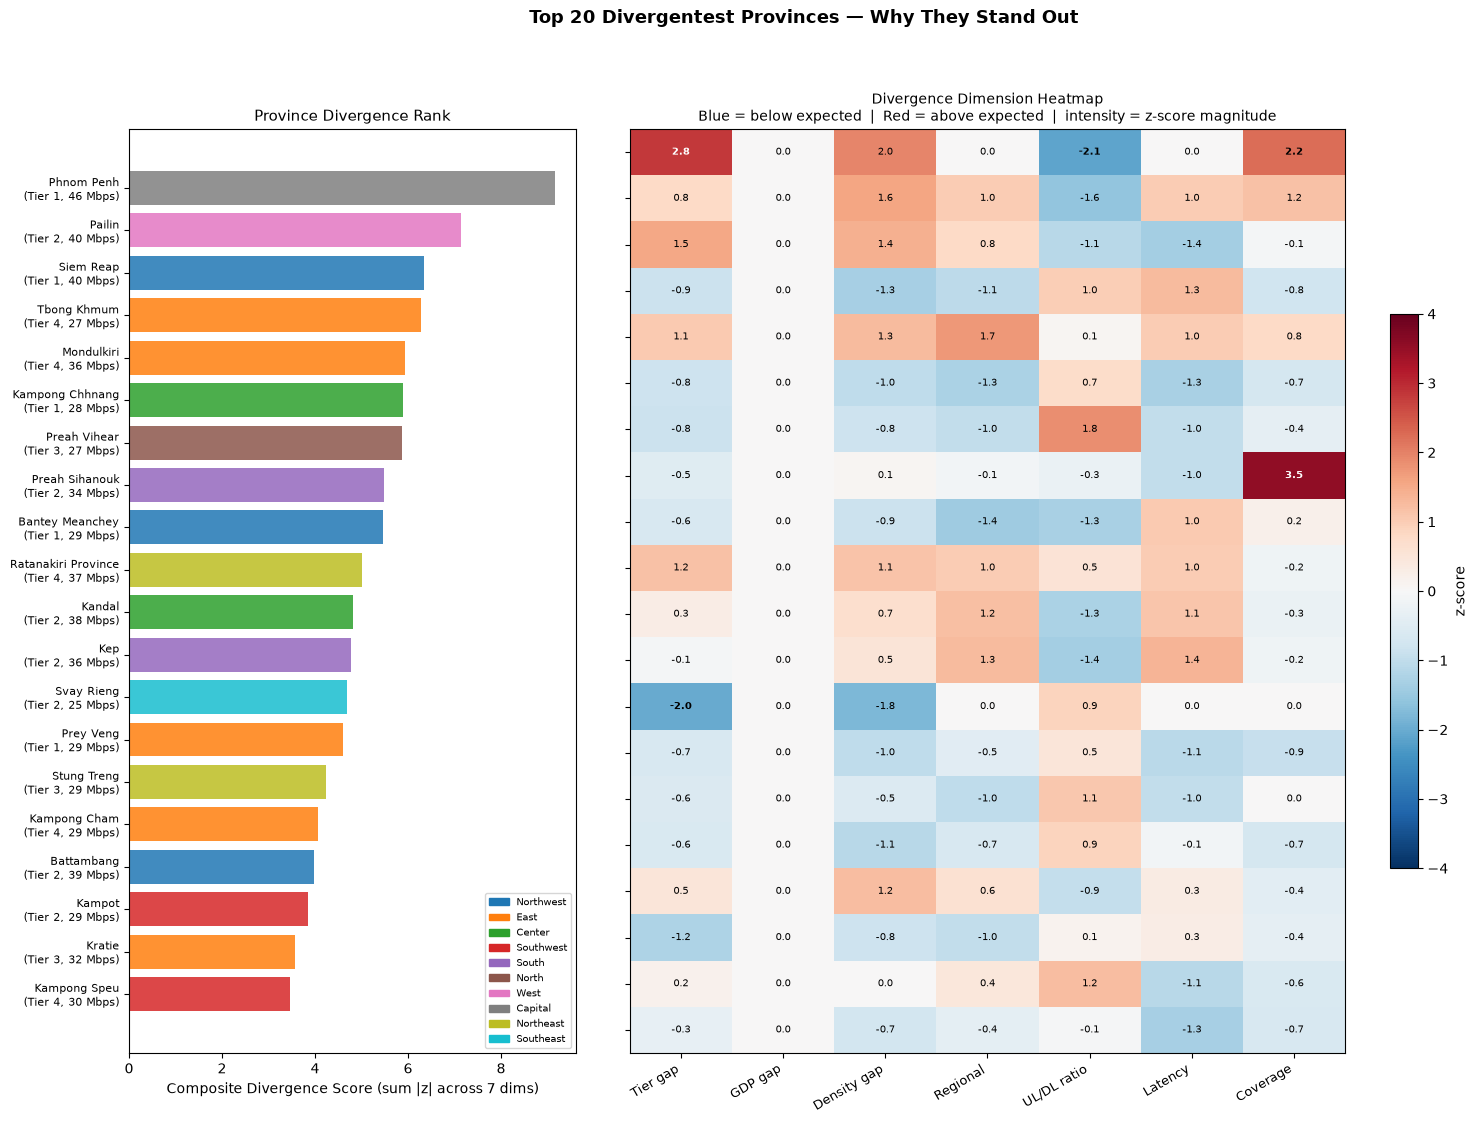


Full leaderboard table:
               name    region  internet_tier   mean_dl  divergence_score  GDP-z     Den-z     Reg-z   Ratio-z     Lat-z     Cov-z
         Phnom Penh   Capital              1 45.660465          9.157332    0.0  1.967517  0.000000 -2.119431  0.000000  2.228817
             Pailin      West              2 40.247960          7.143422    0.0  1.584007  1.000000 -1.581387  1.000000  1.173462
          Siem Reap Northwest              1 39.554521          6.338969    0.0  1.418096  0.811734 -1.118974 -1.352182 -0.088449
        Tbong Khmum      East              4 27.288132          6.277530    0.0 -1.318480 -1.060412  0.977466  1.260688 -0.786559
         Mondulkiri      East              4 36.124628          5.932248    0.0  1.253294  1.741784  0.075783  1.013224  0.796517
    Kampong Chhnang    Center              1 28.244367          5.882844    0.0 -1.018028 -1.257526  0.736314 -1.311156 -0.716097
       Preah Vihear     North              3 27.345963          5

In [71]:
TOP_N = min(20, len(divergent_df))
dims = ['tier_residual_z','gdp_residual_z','den_residual_z','regional_z',
        'ratio_z','lat_regional_z','coverage_z']
dim_labels = ['Tier gap','GDP gap','Density gap','Regional','UL/DL ratio','Latency','Coverage']

top20 = divergent_df.nlargest(TOP_N, 'divergence_score').copy().reset_index(drop=True)

fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(1, 2, width_ratios=[1, 2], wspace=0.08)

region_colors = {
    'Northwest': '#1f77b4',
    'East': '#ff7f0e',
    'Center': '#2ca02c',
    'Southwest': '#d62728',
    'South': '#9467bd',
    'North': '#8c564b',
    'West': '#e377c2',
    'Capital': '#7f7f7f',
    'Northeast': '#bcbd22',
    'Southeast': '#17becf',
}

# ── Left: Composite score bar ──────────────────────────────────────────────────
ax_bar = fig.add_subplot(gs[0])
colors_bar = [region_colors.get(r, 'gray') for r in top20['region']]
y_pos = np.arange(TOP_N)
ax_bar.barh(y_pos, top20['divergence_score'], color=colors_bar, alpha=0.85)
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(
    [f"{row['name']}\n(Tier {int(row['internet_tier'])}, {row['mean_dl']:.0f} Mbps)"
     for _, row in top20.iterrows()],
    fontsize=8
)
ax_bar.set_xlabel('Composite Divergence Score (sum |z| across 7 dims)')
ax_bar.set_title('Province Divergence Rank', fontsize=11)
ax_bar.invert_yaxis()

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax_bar.legend(handles=patches, fontsize=7, loc='lower right')

# ── Right: Heatmap of dimension z-scores ──────────────────────────────────────
ax_heat = fig.add_subplot(gs[1])
heat_data = top20[dims].values.astype(float)

im = ax_heat.imshow(heat_data, cmap='RdBu_r', aspect='auto', vmin=-4, vmax=4)
ax_heat.set_xticks(np.arange(len(dim_labels)))
ax_heat.set_xticklabels(dim_labels, rotation=30, ha='right', fontsize=9)
ax_heat.set_yticks(np.arange(TOP_N))
ax_heat.set_yticklabels([''] * TOP_N)

for i in range(TOP_N):
    for j in range(len(dims)):
        val = heat_data[i, j]
        txt_color = 'white' if abs(val) > 2.5 else 'black'
        ax_heat.text(j, i, f'{val:.1f}', ha='center', va='center',
                     fontsize=7, color=txt_color,
                     fontweight='bold' if abs(val) > 2 else 'normal')

ax_heat.set_title(
    'Divergence Dimension Heatmap\n'
    'Blue = below expected  |  Red = above expected  |  intensity = z-score magnitude',
    fontsize=10
)
plt.colorbar(im, ax=ax_heat, label='z-score', shrink=0.6)

plt.suptitle('Top 20 Divergentest Provinces — Why They Stand Out', fontsize=13, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/mobile/26_divergence_top20.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFull leaderboard table:")
print(top20[['name','region','internet_tier','mean_dl','divergence_score',
             'gdp_residual_z','den_residual_z','regional_z','ratio_z','lat_regional_z','coverage_z']]
      .rename(columns={'gdp_residual_z':'GDP-z','den_residual_z':'Den-z','regional_z':'Reg-z',
                       'ratio_z':'Ratio-z','lat_regional_z':'Lat-z','coverage_z':'Cov-z'})
      .to_string(index=False))


### 23. Province Divergence Map

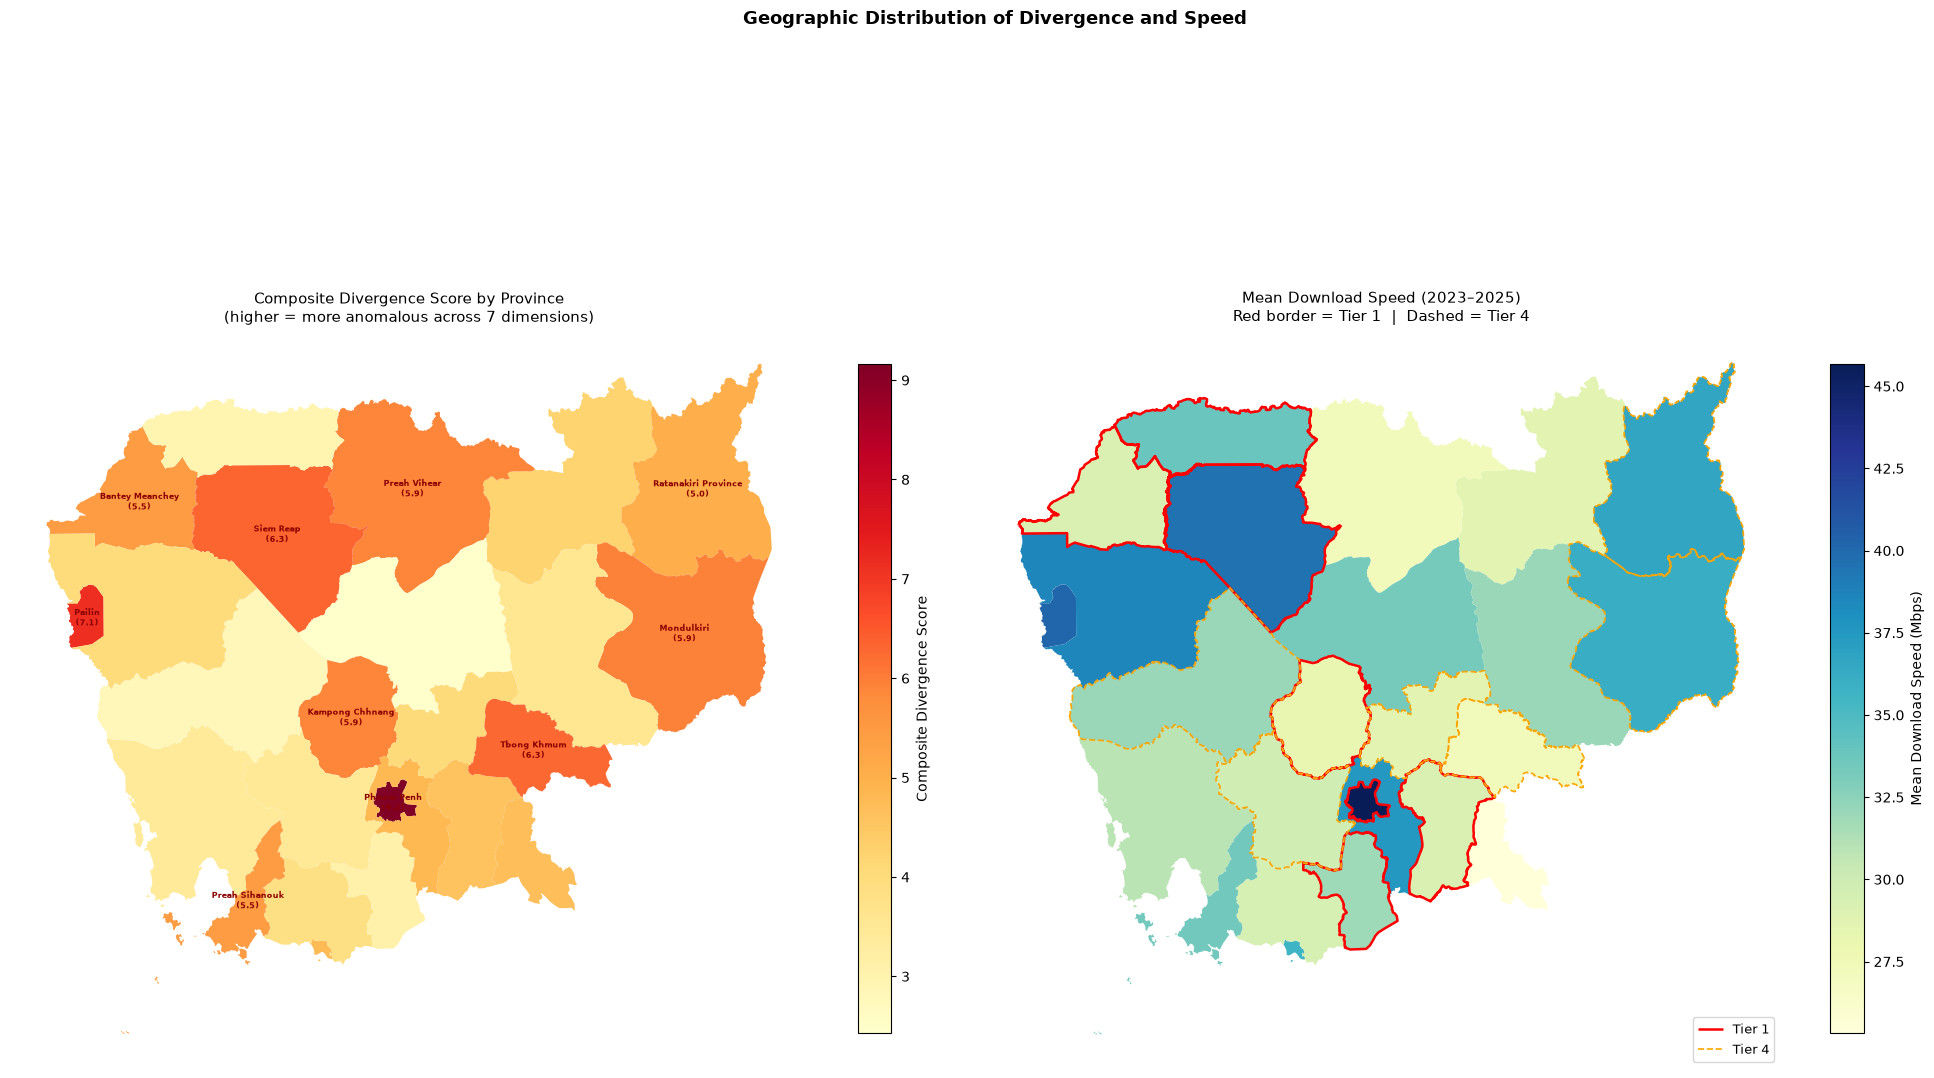

In [72]:
_GEOJSON = '../../data/geo/cambodia_provinces.geojson'

# Load GeoDataFrame with correct path (fallback if earlier cells used old path)
try:
    if 'thailand_gdf' not in dir() or thailand_gdf is None:
        raise NameError
    _ = thailand_gdf.shape  # verify it's valid
except (NameError, Exception):
    thailand_gdf = gpd.read_file(_GEOJSON).to_crs(4326)
    print("Loaded thailand_gdf from correct project path")

geo_divergent = thailand_gdf.copy()
geo_divergent = geo_divergent.merge(
    divergent_df[['name','divergence_score','mean_dl','internet_tier']],
    on='name', how='left'
)
geo_divergent['divergence_score'] = geo_divergent['divergence_score'].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(20, 14))

# ── Left: divergence score choropleth ──────────────────────────────────────────
ax1 = axes[0]
geo_divergent.plot('divergence_score', ax=ax1, cmap='YlOrRd',
               legend=True, missing_kwds={'color':'lightgray'},
               legend_kwds={'label':'Composite Divergence Score','shrink':0.5})

top10_names = divergent_df.nlargest(10, 'divergence_score')['name'].values
for _, row in geo_divergent.iterrows():
    if row['name'] in top10_names:
        c = row.geometry.centroid
        score = row['divergence_score']
        ax1.annotate(f"{row['name']}\n({score:.1f})",
                     (c.x, c.y), ha='center', va='center',
                     fontsize=5.5, color='darkred', fontweight='bold')

ax1.set_title('Composite Divergence Score by Province\n(higher = more anomalous across 7 dimensions)',
              fontsize=11)
ax1.set_axis_off()

# ── Right: download speed choropleth with tier overlay ────────────────────────
ax2 = axes[1]
geo_divergent.plot('mean_dl', ax=ax2, cmap='YlGnBu',
               legend=True, missing_kwds={'color':'lightgray'},
               legend_kwds={'label':'Mean Download Speed (Mbps)','shrink':0.5})

t1 = geo_divergent[geo_divergent['internet_tier'] == 1]
t1.boundary.plot(ax=ax2, color='red', linewidth=1.8, label='Tier 1')
t4 = geo_divergent[geo_divergent['internet_tier'] == 4]
t4.boundary.plot(ax=ax2, color='orange', linewidth=1.2, ls='--', label='Tier 4')

ax2.legend(fontsize=9, loc='lower right')
ax2.set_title('Mean Download Speed (2023–2025)\nRed border = Tier 1  |  Dashed = Tier 4',
              fontsize=11)
ax2.set_axis_off()

plt.suptitle('Geographic Distribution of Divergence and Speed', fontsize=13, fontweight='bold')
plt.tight_layout()

plt.savefig(f'../../outputs/ookla/cambodia/mobile/27_divergence_map.png', dpi=150, bbox_inches='tight')
plt.show()


### 24. Why Are They Divergent? — Annotated Province Notes

### 25. Full Province Divergence Table — All Provinces


In [73]:
# ── Merge display name ────────────────────────────────────────────────────────────
full_table = divergent_df.copy()
full_table = full_table.merge(
    prov_ref[['province_en','province_th']].rename(columns={'province_en':'name'}),
    on='name', how='left'
)

# ── Generate verdict ───────────────────────────────────────────────────────────
_DIM_ORDER = ['regional_z','gdp_residual_z','den_residual_z','tier_residual_z',
              'ratio_z','lat_regional_z','coverage_z']

def _note(d, v, region, tier):
    if d == 'gdp_residual_z':
        return f"fast for GDP (+{v:.1f}σ)" if v > 0 else f"slow for GDP ({v:.1f}σ)"
    if d == 'den_residual_z':
        return f"fast for density (+{v:.1f}σ)" if v > 0 else f"slow for density ({v:.1f}σ)"
    if d == 'tier_residual_z':
        return f"overperforms Tier {tier} (+{v:.1f}σ)" if v > 0 else f"underperforms Tier {tier} ({v:.1f}σ)"
    if d == 'regional_z':
        return f"fast vs {region} (+{v:.1f}σ)" if v > 0 else f"slow vs {region} ({v:.1f}σ)"
    if d == 'ratio_z':
        return f"symmetric UL/DL (+{v:.1f}σ)" if v > 0 else f"asymmetric UL/DL ({v:.1f}σ)"
    if d == 'lat_regional_z':
        return f"high latency (+{v:.1f}σ)" if v > 0 else f"ultra-low latency ({v:.1f}σ)"
    if d == 'coverage_z':
        return f"over-tested (+{v:.1f}σ)" if v > 0 else f"under-tested ({v:.1f}σ)"
    return f"{d}:{v:.1f}σ"

def make_verdict(r):
    region = r['region']
    tier   = int(r['internet_tier'])
    signals = [(abs(r[d]), d, r[d]) for d in _DIM_ORDER if abs(r[d]) >= 1.0]
    signals.sort(reverse=True)
    if not signals:
        return "unremarkable"
    return " | ".join(_note(d, v, region, tier) for _, d, v in signals[:3])

full_table['verdict'] = full_table.apply(make_verdict, axis=1)

# ── Table 0: Overall ranking (top 20) ─────────────────────────────────────────
from IPython.display import display, HTML

display(HTML("<h3>Overall Divergence Ranking — Top 20</h3>"))
t0 = (full_table.nlargest(20, 'divergence_score')
      [['name','province_th','region','internet_tier','mean_dl','divergence_score','verdict']]
      .rename(columns={'name':'Province','province_th':'Local Name','region':'Region',
                       'internet_tier':'Tier','mean_dl':'DL Mbps','divergence_score':'Score','verdict':'Why Divergent?'})
      .reset_index(drop=True))
t0.index += 1
tier_palette = {1:'#ffcccc', 2:'#ffe4b5', 3:'#d4f0d4', 4:'#dce0f5'}
styled0 = (t0.style
    .background_gradient(subset=['Score'], cmap='YlOrRd', vmin=0, vmax=20)
    .background_gradient(subset=['DL Mbps'], cmap='YlGn', vmin=110, vmax=330)
    .map(lambda v: f"background-color:{tier_palette.get(int(v),'#fff')}", subset=['Tier'])
    .set_properties(**{'font-size':'11px','text-align':'left'})
    .set_properties(subset=['Why Divergent?'], **{'min-width':'320px','font-size':'10px'})
    .set_table_styles([
        {'selector':'th','props':[('background','#f0f0f0'),('font-size','10px'),('padding','4px 6px')]},
        {'selector':'td','props':[('padding','3px 6px'),('border','1px solid #ddd')]},
    ]))
display(styled0)

# ── Tables 1-7: Per-dimension top 8 over / bottom 8 under ─────────────────────
dim_meta = {
    'regional_z':      ('Regional Speed', 'fast vs region peers', 'slow vs region peers'),
    'gdp_residual_z':  ('GDP Gap', 'fast for GDP level', 'slow for GDP level'),
    'den_residual_z':  ('Density Gap', 'fast for density', 'slow for density'),
    'tier_residual_z': ('Tier Gap', 'overperforms tier', 'underperforms tier'),
    'ratio_z':         ('UL/DL Ratio', 'symmetric (fiber)', 'asymmetric (legacy)'),
    'lat_regional_z':  ('Latency (regional)', 'high latency', 'ultra-low latency'),
    'coverage_z':      ('Test Coverage', 'over-tested', 'under-tested'),
}

base_cols = ['name','province_th','region','internet_tier','mean_dl']

for dim, (title, over_label, under_label) in dim_meta.items():
    display(HTML(f"<h3>Dimension: {title} <small style='color:#888'>({dim})</small></h3>"))
    
    sub = full_table[base_cols + [dim, 'divergence_score']].copy()
    sub = sub.rename(columns={
        'name':'Province','province_th':'Local Name','region':'Region',
        'internet_tier':'Tier','mean_dl':'DL Mbps',
        dim:'z-score','divergence_score':'Total Score'
    })
    
    over  = sub.nlargest(8, 'z-score').copy()
    under = sub.nsmallest(8, 'z-score').copy()
    over['signal']  = over_label
    under['signal'] = under_label
    
    combined = pd.concat([over, under], ignore_index=True)
    combined = combined[['Province','Local Name','Region','Tier','DL Mbps','z-score','signal','Total Score']]
    combined['z-score'] = combined['z-score'].round(2)
    combined['DL Mbps'] = combined['DL Mbps'].round(1)
    combined['Total Score'] = combined['Total Score'].round(2)
    
    styled_dim = (combined.style
        .background_gradient(subset=['z-score'], cmap='RdBu_r', vmin=-4, vmax=4)
        .background_gradient(subset=['DL Mbps'], cmap='YlGn', vmin=110, vmax=330)
        .map(lambda v: f"background-color:{tier_palette.get(int(v),'#fff')}", subset=['Tier'])
        .set_properties(**{'font-size':'11px','text-align':'left'})
        .set_table_styles([
            {'selector':'th','props':[('background','#f0f0f0'),('font-size','10px'),('padding','4px 6px')]},
            {'selector':'td','props':[('padding','3px 6px'),('border','1px solid #ddd')]},
        ])
        .hide(axis='index'))
    display(styled_dim)
    display(HTML("<hr style='margin:16px 0'>"))

print(f"Provinces: {len(full_table)}")
print(f"Score range: {full_table['divergence_score'].min():.2f} – {full_table['divergence_score'].max():.2f}")
print(f"|z|>2 in any dim: {(full_table[[*_DIM_ORDER]].abs() >= 2).any(axis=1).sum()}")
print(f"|z|>3 in any dim: {(full_table[[*_DIM_ORDER]].abs() >= 3).any(axis=1).sum()}")
print(f"Unremarkable: {(full_table[[*_DIM_ORDER]].abs() < 1.0).all(axis=1).sum()}")

# Save styled table as HTML
_html_path = '../../outputs/ookla/cambodia/mobile/28_divergence_table.html'
with open(_html_path, 'w') as _f:
    _f.write(styled0.to_html())
print(f"Saved: {_html_path}")


,Province,Local Name,Region,Tier,DL Mbps,Score,Why Divergent?
1,Phnom Penh,Phnom Penh,Capital,1,45.660465,9.157332,overperforms Tier 1 (+2.8σ) | over-tested (+2.2σ) | asymmetric UL/DL (-2.1σ)
2,Pailin,Pailin,West,2,40.247960,7.143422,fast for density (+1.6σ) | asymmetric UL/DL (-1.6σ) | over-tested (+1.2σ)
3,Siem Reap,Siem Reap,Northwest,1,39.554521,6.338969,overperforms Tier 1 (+1.5σ) | fast for density (+1.4σ) | ultra-low latency (-1.4σ)
4,Tbong Khmum,Tbong Khmum,East,4,27.288132,6.277530,slow for density (-1.3σ) | high latency (+1.3σ) | slow vs East (-1.1σ)
5,Mondulkiri,Mondulkiri,East,4,36.124628,5.932248,fast vs East (+1.7σ) | fast for density (+1.3σ) | overperforms Tier 4 (+1.1σ)
6,Kampong Chhnang,Kampong Chhnang,Center,1,28.244367,5.882844,ultra-low latency (-1.3σ) | slow vs Center (-1.3σ) | slow for density (-1.0σ)
7,Preah Vihear,Preah Vihear,North,3,27.345963,5.879099,symmetric UL/DL (+1.8σ)
8,Preah Sihanouk,Preah Sihanouk,South,2,33.501949,5.477680,over-tested (+3.5σ)
9,Bantey Meanchey,Bantey Meanchey,Northwest,1,29.163090,5.455388,slow vs Northwest (-1.4σ) | asymmetric UL/DL (-1.3σ) | high latency (+1.0σ)
10,Ratanakiri Province,Ratanakiri Province,Northeast,4,36.664250,5.014793,overperforms Tier 4 (+1.2σ) | fast for density (+1.1σ) | high latency (+1.0σ)


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Mondulkiri,Mondulkiri,East,4,36.100000,1.740000,fast vs region peers,5.930000
Koh Kong,Koh Kong,Southwest,3,30.900000,1.370000,fast vs region peers,3.430000
Kep,Kep,South,2,35.600000,1.270000,fast vs region peers,4.770000
Kandal,Kandal,Center,2,37.500000,1.190000,fast vs region peers,4.810000
Oddar Meanchey,Oddar Meanchey,North,1,33.900000,1.000000,fast vs region peers,2.960000
Pailin,Pailin,West,2,40.200000,1.000000,fast vs region peers,7.140000
Ratanakiri Province,Ratanakiri Province,Northeast,4,36.700000,1.000000,fast vs region peers,5.010000
Siem Reap,Siem Reap,Northwest,1,39.600000,0.810000,fast vs region peers,6.340000
Bantey Meanchey,Bantey Meanchey,Northwest,1,29.200000,-1.410000,slow vs region peers,5.460000
Kampong Chhnang,Kampong Chhnang,Center,1,28.200000,-1.260000,slow vs region peers,5.880000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Bantey Meanchey,Bantey Meanchey,Northwest,1,29.200000,0.000000,fast for GDP level,5.460000
Battambang,Battambang,Northwest,2,38.500000,0.000000,fast for GDP level,3.990000
Kampong Cham,Kampong Cham,East,4,28.600000,0.000000,fast for GDP level,4.060000
Kampong Chhnang,Kampong Chhnang,Center,1,28.200000,0.000000,fast for GDP level,5.880000
Kampong Speu,Kampong Speu,Southwest,4,29.800000,0.000000,fast for GDP level,3.470000
Kampong Thom,Kampong Thom,Center,3,33.300000,0.000000,fast for GDP level,2.430000
Kampot,Kampot,Southwest,2,29.400000,0.000000,fast for GDP level,3.840000
Kandal,Kandal,Center,2,37.500000,0.000000,fast for GDP level,4.810000
Bantey Meanchey,Bantey Meanchey,Northwest,1,29.200000,0.000000,slow for GDP level,5.460000
Battambang,Battambang,Northwest,2,38.500000,0.000000,slow for GDP level,3.990000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Phnom Penh,Phnom Penh,Capital,1,45.700000,1.970000,fast for density,9.160000
Pailin,Pailin,West,2,40.200000,1.580000,fast for density,7.140000
Siem Reap,Siem Reap,Northwest,1,39.600000,1.420000,fast for density,6.340000
Mondulkiri,Mondulkiri,East,4,36.100000,1.250000,fast for density,5.930000
Battambang,Battambang,Northwest,2,38.500000,1.220000,fast for density,3.990000
Ratanakiri Province,Ratanakiri Province,Northeast,4,36.700000,1.140000,fast for density,5.010000
Kandal,Kandal,Center,2,37.500000,0.680000,fast for density,4.810000
Kep,Kep,South,2,35.600000,0.500000,fast for density,4.770000
Svay Rieng,Svay Rieng,Southeast,2,25.300000,-1.780000,slow for density,4.690000
Tbong Khmum,Tbong Khmum,East,4,27.300000,-1.320000,slow for density,6.280000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Phnom Penh,Phnom Penh,Capital,1,45.700000,2.840000,overperforms tier,9.160000
Siem Reap,Siem Reap,Northwest,1,39.600000,1.550000,overperforms tier,6.340000
Ratanakiri Province,Ratanakiri Province,Northeast,4,36.700000,1.170000,overperforms tier,5.010000
Mondulkiri,Mondulkiri,East,4,36.100000,1.050000,overperforms tier,5.930000
Pailin,Pailin,West,2,40.200000,0.800000,overperforms tier,7.140000
Battambang,Battambang,Northwest,2,38.500000,0.480000,overperforms tier,3.990000
Kampong Thom,Kampong Thom,Center,3,33.300000,0.450000,overperforms tier,2.430000
Oddar Meanchey,Oddar Meanchey,North,1,33.900000,0.340000,overperforms tier,2.960000
Svay Rieng,Svay Rieng,Southeast,2,25.300000,-2.020000,underperforms tier,4.690000
Kampot,Kampot,Southwest,2,29.400000,-1.240000,underperforms tier,3.840000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Preah Vihear,Preah Vihear,North,3,27.300000,1.850000,symmetric (fiber),5.880000
Kratie,Kratie,East,3,32.000000,1.230000,symmetric (fiber),3.580000
Stung Treng,Stung Treng,Northeast,3,28.500000,1.090000,symmetric (fiber),4.240000
Tbong Khmum,Tbong Khmum,East,4,27.300000,0.980000,symmetric (fiber),6.280000
Kampong Cham,Kampong Cham,East,4,28.600000,0.900000,symmetric (fiber),4.060000
Svay Rieng,Svay Rieng,Southeast,2,25.300000,0.890000,symmetric (fiber),4.690000
Kampong Thom,Kampong Thom,Center,3,33.300000,0.760000,symmetric (fiber),2.430000
Kampong Chhnang,Kampong Chhnang,Center,1,28.200000,0.740000,symmetric (fiber),5.880000
Phnom Penh,Phnom Penh,Capital,1,45.700000,-2.120000,asymmetric (legacy),9.160000
Pailin,Pailin,West,2,40.200000,-1.580000,asymmetric (legacy),7.140000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Kep,Kep,South,2,35.600000,1.370000,high latency,4.770000
Tbong Khmum,Tbong Khmum,East,4,27.300000,1.260000,high latency,6.280000
Kandal,Kandal,Center,2,37.500000,1.110000,high latency,4.810000
Koh Kong,Koh Kong,Southwest,3,30.900000,1.060000,high latency,3.430000
Bantey Meanchey,Bantey Meanchey,Northwest,1,29.200000,1.030000,high latency,5.460000
Mondulkiri,Mondulkiri,East,4,36.100000,1.010000,high latency,5.930000
Pailin,Pailin,West,2,40.200000,1.000000,high latency,7.140000
Oddar Meanchey,Oddar Meanchey,North,1,33.900000,1.000000,high latency,2.960000
Siem Reap,Siem Reap,Northwest,1,39.600000,-1.350000,ultra-low latency,6.340000
Kampong Speu,Kampong Speu,Southwest,4,29.800000,-1.340000,ultra-low latency,3.470000


Province,Local Name,Region,Tier,DL Mbps,z-score,signal,Total Score
Preah Sihanouk,Preah Sihanouk,South,2,33.500000,3.530000,over-tested,5.480000
Phnom Penh,Phnom Penh,Capital,1,45.700000,2.230000,over-tested,9.160000
Pailin,Pailin,West,2,40.200000,1.170000,over-tested,7.140000
Mondulkiri,Mondulkiri,East,4,36.100000,0.800000,over-tested,5.930000
Koh Kong,Koh Kong,Southwest,3,30.900000,0.470000,over-tested,3.430000
Bantey Meanchey,Bantey Meanchey,Northwest,1,29.200000,0.200000,over-tested,5.460000
Stung Treng,Stung Treng,Northeast,3,28.500000,0.030000,over-tested,4.240000
Svay Rieng,Svay Rieng,Southeast,2,25.300000,0.000000,over-tested,4.690000
Prey Veng,Prey Veng,East,1,29.200000,-0.910000,under-tested,4.590000
Tbong Khmum,Tbong Khmum,East,4,27.300000,-0.790000,under-tested,6.280000


Provinces: 25
Score range: 2.43 – 9.16
|z|>2 in any dim: 3
|z|>3 in any dim: 1
Unremarkable: 1
Saved: ../../outputs/ookla/cambodia/mobile/28_divergence_table.html


## Export for Comparison Notebook
*Saves province × quarter data to CSV.*

In [74]:
# ── Export Ookla Mobile quarterly province data for comparison notebook ──
import os
os.makedirs("../../data/exports", exist_ok=True)

EXPORT_COLS = [
    "name", "label", "year", "quarter",
    "avg_d_mbps", "avg_u_mbps", "avg_lat_ms_wt",
    "total_tests", "n_tiles", "is_reliable",
    "region", "internet_tier", "pop_2024",
    "gdp_per_capita_thb_2021", "density_per_km2",
]
existing_cols = [c for c in EXPORT_COLS if c in master.columns]
out = master[existing_cols].copy()
out = out.rename(columns={"name": "province", "label": "quarter"})

PATH = "../../data/exports/ookla_mobile_cambodia_province_quarterly.csv"
out.to_csv(PATH, index=False)
print(f"Exported {len(out)} rows → {PATH}")
print(out.head(3).to_string())


Exported 292 rows → ../../data/exports/ookla_mobile_cambodia_province_quarterly.csv
          province  quarter  year  quarter  avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests  n_tiles  is_reliable     region  internet_tier  pop_2024  gdp_per_capita_thb_2021  density_per_km2
0  Bantey Meanchey  2023-Q1  2023        1   23.285257   11.279264      36.375085       4415.0    570.0         True  Northwest              1    898484                199216.96              135
1       Battambang  2023-Q1  2023        1   24.999707   15.038748      40.224025       2281.0    492.0         True  Northwest              2   1132017                199216.96               97
2     Kampong Cham  2023-Q1  2023        1   23.642645   15.213396      29.785609       1362.0    400.0         True       East              4   1062914                199216.96              234
